<a href="https://colab.research.google.com/github/HaqTetsuya/ChatbotPerpusBipa/blob/main/Salinan_dari_IndobertPerpusChatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title download dependancy
!pip install transformers torch pandas scikit-learn matplotlib seaborn tqdm deep-translator fuzzywuzzy Levenshtein


In [ ]:

!gdown --id 1NqYxL5_f2bKAeR2zLzzMiKXA2XrSYuOd -O train.csv

# Download the second file, renaming it to avoid conflicts
!gdown --id 1kWIREnyfCNTmD3sNNL7uihfkxp_SxYEu -O train.csv

# Verify the files were downloaded
!ls

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1kWIREnyfCNTmD3sNNL7uihfkxp_SxYEu
To: /content/train.csv
100% 452k/452k [00:00<00:00, 106MB/s]


In [6]:
# @title import dependency, load drive, and github {"form-width":"20%"}
!git clone https://github.com/HaqTetsuya/ChatbotPerpusBipa.git

import json
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from google.colab import drive, files
from plotly.subplots import make_subplots
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
#from tqdm import tqdm
from tqdm.auto import tqdm  # If you need both tqdm and tqdm.auto
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler

import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pickle

drive.mount('/content/drive')
FName = "fucking e 7 again i dont know part2" #@param {type:"string"}

# Update MODEL_SAVE_PATH with user input
MODEL_SAVE_PATH = f"/content/drive/MyDrive/{FName}"

fatal: destination path 'ChatbotPerpusBipa' already exists and is not an empty directory.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# @title Kelas Dataset untuk IndoBERT
class IntentDataset(Dataset):
    """Dataset untuk klasifikasi intent dengan IndoBERT"""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        # Convert dict of tensors to flat tensors
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(label)

        return item

In [ ]:
# @title load data

def load_csv_data(csv_path, label_encoder=None, show_distribution=False):
    """Memuat data intent dari file CSV. Bisa untuk train/test tanpa split."""
    print(f"\nMemuat data dari: {csv_path}")

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"File tidak ditemukan: {csv_path}")

    df = pd.read_csv(csv_path)

    if 'text' not in df.columns or 'intent' not in df.columns:
        raise ValueError("Kolom 'text' dan 'intent' harus ada di CSV")

    if label_encoder is None:
        label_encoder = LabelEncoder()
        df['intent_encoded'] = label_encoder.fit_transform(df['intent'])
        intent_classes = label_encoder.classes_
        print(f"Label encoder baru dibuat dari data {csv_path}")
    else:
        df['intent_encoded'] = label_encoder.transform(df['intent'])
        intent_classes = label_encoder.classes_
        print(f"Menggunakan label encoder yang sudah ada")

    if show_distribution:
        intent_counts = df['intent'].value_counts()
        print("\nDistribusi intent:")
        for intent, count in intent_counts.items():
            print(f"  {intent}: {count}")

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.barplot(x=intent_counts.index, y=intent_counts.values, palette="viridis")
        plt.xlabel("Intent")
        plt.ylabel("Jumlah Sampel")
        plt.title("Distribusi Intent")
        plt.xticks(rotation=45)

        plt.subplot(1, 2, 2)
        plt.pie(intent_counts, labels=intent_counts.index, autopct='%1.1f%%', colors=sns.color_palette("viridis", len(intent_counts)))
        plt.title("Proporsi Intent")
        plt.tight_layout()
        plt.show()

    texts = df['text'].values
    labels = df['intent_encoded'].values

    return texts, labels, intent_classes, label_encoder


In [ ]:
# @title Setup IndoBERT Model
model_name_test = "indobenchmark/indobert-base-p2" # @param ["indobenchmark/indobert-base-p2","indobenchmark/indobert-lite-base-p1","indolem/indobert-base-uncased"]

def setup_indobert_for_intent(num_labels):
    """Load IndoBERT model for intent classification"""
    print(f"Loading IndoBERT model: {model_name_test}")

    tokenizer = AutoTokenizer.from_pretrained(model_name_test)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name_test,
        num_labels=num_labels
    )
    print("Model successfully loaded")

    return model, tokenizer


In [ ]:
# @title OOD
def enhanced_calibrate_ood(model, tokenizer, val_dataloader, save_path, temperature=1.0, percentile=85, margin=0.1):
    """
    Calibrate and save OOD thresholds with adjustable tolerance
    """
    print("Calibrating threshold for OOD detection...")
    thresholds = calibrate_ood_detection(model, tokenizer, val_dataloader,
                                        temperature=temperature,
                                        percentile=percentile,
                                        margin=margin)

    print(f"Energy threshold: {thresholds['energy_threshold']:.4f}")
    print(f"MSP threshold: {thresholds['msp_threshold']:.4f}")

    # Save thresholds
    save_ood_thresholds(thresholds, save_path)

    return thresholds

def calibrate_ood_detection(model, tokenizer, dataloader, temperature=1.0, percentile=70, margin=0.1):
    """
    Calibrate thresholds for OOD detection using in-distribution data
    with Energy-based and MSP (Maximum Softmax Probability) methods
    """
    device = next(model.parameters()).device
    model.eval()

    # For Energy method and MSP method
    energy_scores = []
    msp_scores = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Calibrating OOD detection"):
            inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            outputs = model(**inputs)
            logits = outputs.logits

            # Energy score (higher values for OOD)
            energy = -temperature * torch.logsumexp(logits / temperature, dim=1)
            energy_scores.extend(energy.cpu().numpy())

            # MSP score (lower values for OOD)
            softmax_probs = F.softmax(logits, dim=1)
            max_probs, _ = torch.max(softmax_probs, dim=1)
            msp_scores.extend(max_probs.cpu().numpy())

    # Calculate threshold for Energy with margin (make more tolerant)
    base_energy_threshold = np.percentile(energy_scores, percentile)
    # Apply margin to make more tolerant (increase threshold)
    energy_threshold = base_energy_threshold * (1 + margin)

    # Calculate threshold for MSP with margin
    base_msp_threshold = np.percentile(msp_scores, 100 - percentile)
    # Apply margin to make more tolerant (decrease threshold)
    msp_threshold = base_msp_threshold * (1 - margin)

    return {
        "energy_threshold": float(energy_threshold),
        "msp_threshold": float(msp_threshold)
    }

def predict_with_ood_detection(model, tokenizer, text, thresholds, temperature=1.0, tolerance_factor=1.0):
    """
    Predict with adjustable OOD detection tolerance
    """
    device = next(model.parameters()).device
    model.eval()

    # Apply the tolerance factor to thresholds
    energy_threshold = thresholds["energy_threshold"] * tolerance_factor
    msp_threshold = thresholds["msp_threshold"] / tolerance_factor if thresholds["msp_threshold"] else None

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

        # Energy score
        energy = -temperature * torch.logsumexp(logits / temperature, dim=1)
        energy_score = energy.item()

        # MSP score
        softmax_probs = F.softmax(logits, dim=1)
        max_probs, predicted_class = torch.max(softmax_probs, dim=1)
        msp_score = max_probs.item()

        # OOD detection
        is_ood_energy = energy_score > energy_threshold
        is_ood_msp = msp_score < msp_threshold if msp_threshold else False

        # Combined OOD detection (can adjust this logic for tolerance)
        is_ood = is_ood_energy  # You can use different combinations

        return {
            "prediction": predicted_class.item(),
            "confidence": msp_score,
            "energy_score": energy_score,
            "is_ood": is_ood,
            "is_ood_energy": is_ood_energy,
            "is_ood_msp": is_ood_msp
        }

def save_ood_thresholds(thresholds, save_path):
    """
    Save OOD thresholds to JSON file
    """
    threshold_file = os.path.join(save_path, "ood_thresholds.json")
    with open(threshold_file, 'w') as f:
        json.dump(thresholds, f, indent=4)
    print(f"OOD thresholds saved at {threshold_file}")
    return threshold_file

def load_ood_thresholds(model_path):
    """
    Load OOD thresholds from JSON file
    """
    try:
        with open(os.path.join(model_path, "ood_thresholds.json"), 'r') as f:
            thresholds = json.load(f)
            return thresholds
    except FileNotFoundError:
        try:
            with open(os.path.join(model_path, "ood_threshold.json"), 'r') as f:
                threshold_data = json.load(f)
                return {
                    "energy_threshold": threshold_data["energy_threshold"],
                    "msp_threshold": None
                }
        except FileNotFoundError:
            print("Warning: OOD threshold files not found. Using default thresholds.")
            return {
                "energy_threshold": 0.0,
                "msp_threshold": 0.5
            }

In [ ]:
# @title Focal LOSS


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


In [ ]:
#@title Training function

def train_intent_classifier(model, tokenizer, train_texts, train_labels, val_texts, val_labels,
                           batch_size=16, epochs=10, learning_rate=2e-5, weight_decay=0.01,
                           save_path=MODEL_SAVE_PATH, use_class_weights=True, patience=3, class_names=None):
    """
    Melatih model IndoBERT untuk klasifikasi intent dengan perbaikan:
    - Enhanced visualization (interactive and static)
    - Per-class metric tracking
    - Confusion matrix generation
    - Batch-level metric tracking
    - Learning rate visualization
    """

    # Persiapkan dataset
    print("Menyiapkan dataset...")
    train_dataset = IntentDataset(train_texts, train_labels, tokenizer)
    val_dataset = IntentDataset(val_texts, val_labels, tokenizer)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

    # Compute class weights if needed
    class_weights = None
    if use_class_weights:
        unique_classes = np.unique(train_labels)
        weights = compute_class_weight(
            class_weight='balanced',
            classes=unique_classes,
            y=train_labels
        )
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        class_weights = torch.FloatTensor(weights).to(device)
        print(f"Menggunakan class weights: {weights}")

    # Optimizer dengan weight decay untuk regularisasi
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # Scheduler dengan warmup
    num_training_steps = len(train_dataloader) * epochs
    num_warmup_steps = int(0.1 * num_training_steps)  # 10% warmup
    scheduler = get_scheduler("cosine", optimizer=optimizer,
                             num_warmup_steps=num_warmup_steps,
                             num_training_steps=num_training_steps)

    # Cek untuk GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Menggunakan device: {device}")
    model.to(device)
    print(f"Mulai pelatihan model...")
    print(f"Total epoch: {epochs}, batch size: {batch_size}, learning rate: {learning_rate}, weight decay: {weight_decay}")

    # Create loss function with class weights if needed
    # Create Focal Loss with class weights
    #if class_weights is not None:
    #    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
    #else:
    #    loss_fn = torch.nn.CrossEntropyLoss()
    loss_fn = FocalLoss(alpha=class_weights, gamma=2.0)
    print("Menggunakan Focal Loss dengan gamma=2.0")

    # Initialize training history
    history = initialize_training_history()
    best_val_loss = float('inf')
    counter = 0  # Counter for early stopping

    for epoch in range(epochs):
        # Training phase
        train_loss = run_training_epoch(model, device, train_dataloader, optimizer,
                                        scheduler, loss_fn, epoch, epochs, history)
        history['train_loss'].append(train_loss)

        # Validation phase
        val_metrics = run_validation_epoch(model, device, val_dataloader, loss_fn, epoch, epochs)
        update_history_with_validation_metrics(history, val_metrics)

        # Update per-class metrics if class names are provided
        if class_names is not None:
            update_per_class_metrics(history, val_metrics['all_labels'], val_metrics['all_preds'])

            # Generate confusion matrix for this epoch
            plot_confusion_matrix(val_metrics['all_labels'], val_metrics['all_preds'], class_names, epoch, save_path)

        # Print detailed metrics
        print_epoch_metrics(epoch, epochs, train_loss, val_metrics)

        # Early stopping and model saving logic
        counter = handle_early_stopping(model, tokenizer, val_metrics['avg_val_loss'],
                                      best_val_loss, counter, patience,
                                      save_path, val_metrics['all_labels'],
                                      val_metrics['all_preds'])

        if counter >= patience:
            print(f"Early stopping triggered setelah {epoch+1} epochs")
            break

        # Update best validation loss if improved
        if val_metrics['avg_val_loss'] < best_val_loss:
            best_val_loss = val_metrics['avg_val_loss']

    print(f"Pelatihan selesai! Model terbaik disimpan di {save_path}")

    # Generate enhanced visualizations
    enhanced_plot_training_results(history, save_path, class_names=class_names)

    # Simpan history ke file JSON
    save_enhanced_history(history, save_path)

    return model, history

def initialize_training_history():
    """Initialize the training history dictionary with all required keys"""
    return {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_f1': [],
        'val_precision': [],
        'val_recall': [],
        'batch_metrics': {
            'iteration': [],
            'loss': [],
            'epoch': [],
            'progress': [],
            'learning_rates': []
        },
        'class_f1': [],  # Per-class F1 scores
        'class_precision': [],  # Per-class precision
        'class_recall': []  # Per-class recall
    }

def run_training_epoch(model, device, train_dataloader, optimizer, scheduler, loss_fn, epoch, epochs, history):
    """Run a single training epoch and return average loss"""
    model.train()
    train_loss = 0
    print(f"\nEpoch {epoch+1}/{epochs} - Training dimulai...")
    progress_bar = tqdm(enumerate(train_dataloader), total=len(train_dataloader),
                      desc=f"Epoch {epoch+1}/{epochs} [Training]", leave=False)

    for batch_idx, batch in progress_bar:
        try:
            # Pindahkan batch ke device
            inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].to(device)

            # Forward pass with custom loss function
            optimizer.zero_grad()
            outputs = model(**inputs)
            loss = loss_fn(outputs.logits, labels)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            # Track batch-level metrics
            update_batch_metrics(history, batch_idx, loss.item(), epoch, len(train_dataloader), optimizer)

            train_loss += loss.item()
            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

        except RuntimeError as e:
            if "out of memory" in str(e):
                print("Peringatan: Kehabisan memori! Membersihkan cache...")
                torch.cuda.empty_cache()
                continue
            else:
                raise e

    return train_loss / len(train_dataloader)

def update_batch_metrics(history, batch_idx, loss_item, epoch, iterations_per_epoch, optimizer):
    """Update history with batch-level metrics"""
    global_iteration = epoch * iterations_per_epoch + batch_idx
    progress = (epoch + (batch_idx / iterations_per_epoch)) * 100

    history['batch_metrics']['iteration'].append(global_iteration)
    history['batch_metrics']['loss'].append(loss_item)
    history['batch_metrics']['epoch'].append(epoch)
    history['batch_metrics']['progress'].append(progress)
    history['batch_metrics']['learning_rates'].append(optimizer.param_groups[0]['lr'])

def run_validation_epoch(model, device, val_dataloader, loss_fn, epoch, epochs):
    """Run a single validation epoch and return metrics"""
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    print(f"Epoch {epoch+1}/{epochs} - Validasi dimulai...")
    progress_bar = tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Validation]", leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].to(device)

            outputs = model(**inputs)
            loss = loss_fn(outputs.logits, labels)
            val_loss += loss.item()

            # Calculate accuracy
            predictions = torch.argmax(outputs.logits, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Collect predictions and labels for metrics
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    # Calculate metrics
    avg_val_loss = val_loss / len(val_dataloader)
    accuracy = correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)

    return {
        'avg_val_loss': avg_val_loss,
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'all_preds': all_preds,
        'all_labels': all_labels
    }

def update_history_with_validation_metrics(history, val_metrics):
    """Update history with validation metrics"""
    history['val_loss'].append(val_metrics['avg_val_loss'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])

def update_per_class_metrics(history, all_labels, all_preds):
    """Update per-class metrics in history"""
    class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
    class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
    class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)

    history['class_f1'].append(class_f1.tolist())
    history['class_precision'].append(class_precision.tolist())
    history['class_recall'].append(class_recall.tolist())

def print_epoch_metrics(epoch, epochs, avg_train_loss, val_metrics):
    """Print detailed metrics for an epoch"""
    print(f"Epoch {epoch+1}/{epochs}:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss: {val_metrics['avg_val_loss']:.4f}, Val Accuracy: {val_metrics['accuracy']*100:.2f}%")
    print(f"  Val F1: {val_metrics['f1']:.4f}, Val Precision: {val_metrics['precision']:.4f}, Val Recall: {val_metrics['recall']:.4f}")
    if 'all_labels' in val_metrics and 'all_preds' in val_metrics:
        print(f"\nClass-wise precision/recall/F1 setelah epoch {epoch+1}:")
        print(classification_report(val_metrics['all_labels'], val_metrics['all_preds'], digits=4))
def handle_early_stopping(model, tokenizer, avg_val_loss, best_val_loss, counter, patience, save_path, all_labels, all_preds):
    """Handle early stopping logic and model saving"""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0  # Reset early stopping counter

        if not os.path.exists(save_path):
            os.makedirs(save_path)

        print(f"Menyimpan model terbaik ke {save_path}")
        model.save_pretrained(save_path)
        tokenizer.save_pretrained(save_path)

        # Save classification report for best model
        report = classification_report(all_labels, all_preds, output_dict=True)
        with open(os.path.join(save_path, "classification_report.json"), 'w') as f:
            json.dump(report, f, indent=4)
    else:
        counter += 1
        print(f"Validation loss tidak membaik. Early stopping counter: {counter}/{patience}")

    return counter

In [ ]:
# @title Evaluation
def evaluate_model_enhanced(model, tokenizer, val_texts, val_labels, intent_classes, save_path):
    """Enhanced model evaluation with better visualizations"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    # Prepare dataset and dataloader
    val_dataset = IntentDataset(val_texts, val_labels, tokenizer)
    val_dataloader = DataLoader(val_dataset, batch_size=16)

    all_preds = []
    all_labels = []

    # Evaluation loop
    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc="Evaluasi Model"):
            inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            labels = batch['labels'].to(device)

            outputs = model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Generate classification report
    report = classification_report(all_labels, all_preds,
                                 target_names=intent_classes,
                                 output_dict=True)

    # Create dataframe for visualization
    report_df = pd.DataFrame(report).transpose()
    report_df = report_df.round(3)

    # Filter for class metrics only (exclude summary rows)
    class_df = report_df.loc[intent_classes]
    metrics = ['precision', 'recall', 'f1-score']

    # Save classification metrics as CSV
    report_df.to_csv(os.path.join(save_path, "classification_report.csv"))

    # Create visualizations
    create_static_visualizations(cm, class_df, metrics, intent_classes, save_path)
    create_interactive_visualizations(cm, class_df, metrics, intent_classes, save_path)

    # Print report summary
    print("\nModel Evaluation Report:")
    print(f"Overall Accuracy: {report['accuracy']:.4f}")
    print(f"Macro F1-score: {report['macro avg']['f1-score']:.4f}")
    print(f"Weighted F1-score: {report['weighted avg']['f1-score']:.4f}")

    return report, cm

def create_static_visualizations(cm, class_df, metrics, intent_classes, save_path):
    """Create and save static matplotlib visualizations"""
    # Confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=intent_classes, yticklabels=intent_classes)
    plt.title('Confusion Matrix - Final Model')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "final_confusion_matrix.png"))
    plt.close()

    # Classification report heatmap
    plt.figure(figsize=(12, len(intent_classes)*0.5 + 3))
    sns.heatmap(class_df[metrics], annot=True, cmap='YlGnBu', fmt='.3f',
               yticklabels=intent_classes, cbar=True)
    plt.title('Performance Metrics by Intent Class')
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "class_performance_metrics.png"))
    plt.close()

def create_interactive_visualizations(cm, class_df, metrics, intent_classes, save_path):
    """Create and save interactive plotly visualizations"""
    # Interactive confusion matrix
    fig_cm = px.imshow(cm,
                   labels=dict(x="Predicted Label", y="True Label", color="Count"),
                   x=intent_classes, y=intent_classes,
                   text_auto=True,
                   color_continuous_scale='Blues')

    fig_cm.update_layout(
        title='Confusion Matrix (Interactive)',
        width=900,
        height=800
    )
    fig_cm.write_html(os.path.join(save_path, "interactive_confusion_matrix.html"))

    # Interactive performance metrics
    fig_perf = px.imshow(class_df[metrics],
                   labels=dict(x="Metric", y="Intent Class", color="Score"),
                   x=metrics, y=intent_classes,
                   text_auto=True,
                   color_continuous_scale='YlGnBu')

    fig_perf.update_layout(
        title='Performance Metrics by Intent Class (Interactive)',
        width=800,
        height=max(400, len(intent_classes)*30)
    )
    fig_perf.write_html(os.path.join(save_path, "interactive_class_performance.html"))

In [ ]:
# @title plot diagram
def enhanced_plot_training_results(history, save_path, class_names=None):
    """
    Enhanced function to plot training results with more detailed visualizations

    Args:
        history: Dictionary containing training history metrics
        save_path: Path to save visualization files
        class_names: Optional list of class names for confusion matrix
    """
    # Create the static plots (same as before for compatibility)
    static_plot_training_results(history, save_path)

    # Create interactive plotly visualizations
    interactive_plot_training_results(history, save_path)

    # If we have class metrics in our history, plot those too
    if 'class_f1' in history and class_names is not None:
        plot_class_metrics(history, save_path, class_names)

    # If we tracked learning rates, plot those
    if 'batch_metrics' in history and 'learning_rates' in history['batch_metrics']:
        plot_learning_rate(history, save_path)

def static_plot_training_results(history, save_path):
    """Plot and save training metrics using matplotlib (static)"""
    plt.figure(figsize=(15, 10))

    # Plot 1: Loss
    plt.subplot(2, 2, 1)
    plt.plot(history['train_loss'], label='Training Loss', marker='o')
    plt.plot(history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Loss selama Training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(2, 2, 2)
    plt.plot(history['val_accuracy'], label='Validation Accuracy', marker='o', color='green')
    plt.title('Akurasi selama Training')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot 3: F1 Score
    plt.subplot(2, 2, 3)
    plt.plot(history['val_f1'], label='Validation F1', marker='o', color='purple')
    plt.title('F1 Score selama Training')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)

    # Plot 4: Precision & Recall
    plt.subplot(2, 2, 4)
    plt.plot(history['val_precision'], label='Validation Precision', marker='o', color='orange')
    plt.plot(history['val_recall'], label='Validation Recall', marker='o', color='brown')
    plt.title('Precision & Recall selama Training')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    # Save the plot
    plt.savefig(os.path.join(save_path, "training_metrics.png"))
    plt.close()

def interactive_plot_training_results(history, save_path):
    """Create interactive plotly visualizations of training metrics"""
    # Create epochs list for x-axis
    epochs = list(range(1, len(history['train_loss']) + 1))

    # Create a DataFrame for easier plotting
    df = pd.DataFrame({
        'Epoch': epochs,
        'Training Loss': history['train_loss'],
        'Validation Loss': history['val_loss'],
        'Validation Accuracy': history['val_accuracy'],
        'Validation F1': history['val_f1'],
        'Validation Precision': history['val_precision'],
        'Validation Recall': history['val_recall']
    })

    # Create subplot figure
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Loss', 'Accuracy', 'F1 Score', 'Precision & Recall'),
        vertical_spacing=0.15,
        horizontal_spacing=0.1
    )

    # Add traces for each metric
    # Loss plot
    fig.add_trace(
        go.Scatter(x=epochs, y=history['train_loss'], mode='lines+markers', name='Training Loss'),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=epochs, y=history['val_loss'], mode='lines+markers', name='Validation Loss'),
        row=1, col=1
    )

    # Accuracy plot
    fig.add_trace(
        go.Scatter(x=epochs, y=history['val_accuracy'], mode='lines+markers', name='Validation Accuracy', line=dict(color='green')),
        row=1, col=2
    )

    # F1 Score plot
    fig.add_trace(
        go.Scatter(x=epochs, y=history['val_f1'], mode='lines+markers', name='Validation F1', line=dict(color='purple')),
        row=2, col=1
    )

    # Precision & Recall plot
    fig.add_trace(
        go.Scatter(x=epochs, y=history['val_precision'], mode='lines+markers', name='Validation Precision', line=dict(color='orange')),
        row=2, col=2
    )
    fig.add_trace(
        go.Scatter(x=epochs, y=history['val_recall'], mode='lines+markers', name='Validation Recall', line=dict(color='brown')),
        row=2, col=2
    )

    # Update layout
    fig.update_layout(
        height=800,
        width=1200,
        title_text="Training Metrics (Interactive)",
        hovermode="x unified"
    )

    # Save interactive plot as HTML
    fig.write_html(os.path.join(save_path, "interactive_training_metrics.html"))

    # Create a combined metrics plot for better trend comparison
    fig_combined = px.line(
        df,
        x='Epoch',
        y=['Training Loss', 'Validation Loss', 'Validation Accuracy', 'Validation F1', 'Validation Precision', 'Validation Recall'],
        title='All Training Metrics',
        labels={'value': 'Metric Value', 'variable': 'Metric'}
    )

    fig_combined.update_layout(height=600, width=1000, hovermode="x unified")
    fig_combined.write_html(os.path.join(save_path, "combined_metrics.html"))

def plot_confusion_matrix(all_labels, all_preds, class_names, epoch, save_path):
    """Plot and save confusion matrix for the epoch"""
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f'Confusion Matrix - Epoch {epoch+1}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    # Save the confusion matrix
    cm_dir = os.path.join(save_path, "confusion_matrices")
    os.makedirs(cm_dir, exist_ok=True)
    plt.savefig(os.path.join(cm_dir, f"cm_epoch_{epoch+1}.png"))
    plt.close()

def plot_class_metrics(history, save_path, class_names):
    """Plot per-class performance metrics"""
    # Create directory for class metrics
    os.makedirs(os.path.join(save_path, "class_metrics"), exist_ok=True)

    # Plot F1 per class if available
    if 'class_f1' in history:
        plt.figure(figsize=(12, 8))

        # Convert dictionary structure to usable format
        epochs = len(history['class_f1'])
        x_epochs = list(range(1, epochs + 1))

        for i, class_name in enumerate(class_names):
            class_f1 = [history['class_f1'][epoch][i] for epoch in range(epochs)]
            plt.plot(x_epochs, class_f1, marker='o', label=f'{class_name}')

        plt.title('F1 Score per Class')
        plt.xlabel('Epoch')
        plt.ylabel('F1 Score')
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(os.path.join(save_path, "class_metrics", "f1_per_class.png"))
        plt.close()

        # Interactive version with plotly
        fig = go.Figure()
        for i, class_name in enumerate(class_names):
            class_f1 = [history['class_f1'][epoch][i] for epoch in range(epochs)]
            fig.add_trace(go.Scatter(
                x=x_epochs,
                y=class_f1,
                mode='lines+markers',
                name=class_name
            ))

        fig.update_layout(
            title='F1 Score per Class (Interactive)',
            xaxis_title='Epoch',
            yaxis_title='F1 Score',
            height=600,
            width=1000,
            hovermode="x unified"
        )
        fig.write_html(os.path.join(save_path, "class_metrics", "f1_per_class.html"))

def plot_learning_rate(history, save_path):
    """Plot learning rate changes over training"""
    # Extract learning rates from batch metrics
    iterations = history['batch_metrics']['iteration']
    learning_rates = history['batch_metrics']['learning_rates']
    epochs = history['batch_metrics']['epoch']

    # Create the plot
    plt.figure(figsize=(12, 6))
    plt.plot(iterations, learning_rates)
    plt.title('Learning Rate Schedule')
    plt.xlabel('Iteration')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "learning_rate_schedule.png"))
    plt.close()

    # Interactive version
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=iterations,
        y=learning_rates,
        mode='lines',
        name='Learning Rate'
    ))

    fig.update_layout(
        title='Learning Rate Schedule (Interactive)',
        xaxis_title='Iteration',
        yaxis_title='Learning Rate',
        height=500,
        width=900
    )
    fig.write_html(os.path.join(save_path, "learning_rate_schedule.html"))

def save_enhanced_history(history, save_path):
    """Save enhanced training history with additional visualizations"""
    # Convert numpy arrays to lists for JSON serialization
    processed_history = {}

    for key, value in history.items():
        if isinstance(value, dict):
            processed_history[key] = {}
            for subkey, subvalue in value.items():
                processed_history[key][subkey] = convert_to_serializable(subvalue)
        else:
            processed_history[key] = convert_to_serializable(value)

    # Save the enhanced history
    with open(os.path.join(save_path, "enhanced_training_history.json"), 'w') as f:
        json.dump(processed_history, f, indent=4)

    print(f"Enhanced training history saved to {os.path.join(save_path, 'enhanced_training_history.json')}")

def convert_to_serializable(value):
    """Convert numpy arrays and other non-serializable types to JSON-compatible types"""
    if isinstance(value, np.ndarray):
        return value.tolist()
    elif isinstance(value, list):
        if value and isinstance(value[0], np.ndarray):
            return [item.tolist() if isinstance(item, np.ndarray) else item for item in value]
        else:
            return value
    else:
        return value

In [ ]:
# @title PredictionIntent
def predict_intent_with_enhanced_ood(text, model, tokenizer, intent_classes,
                                     energy_threshold, msp_threshold=None,
                                     temperature=1.0, method='combined',
                                     label_encoder=None, device=None,
                                     return_logits=False):
    """
    Memprediksi intent dari teks input dengan deteksi Out-of-Distribution yang ditingkatkan

    Args:
        text: Teks input untuk diprediksi
        model: Model yang sudah dilatih
        tokenizer: Tokenizer untuk model
        intent_classes: List nama intent
        energy_threshold: Threshold untuk energy-based OOD detection
        msp_threshold: Threshold untuk MSP-based OOD detection
        temperature: Parameter temperature untuk energy
        method: Metode deteksi OOD - 'energy', 'msp', atau 'combined'
        label_encoder: Label encoder untuk intent classes
        device: Device untuk inference
        return_logits: Jika True, mengembalikan logits asli

    Returns:
        dict: Hasil prediksi dengan detail OOD detection
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if isinstance(text, str):
        text = [text]  # Convert single text to list

    model.to(device)
    model.eval()

    # Tokenisasi input
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    # List untuk menyimpan hasil setiap input
    results = []

    # Prediksi
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

        # Hitung energy score: -T*log(sum(exp(logits/T)))
        energy = -temperature * torch.logsumexp(logits / temperature, dim=1)

        # Hitung confidence dengan softmax
        probabilities = torch.softmax(logits, dim=1)
        predictions = torch.argmax(probabilities, dim=1)
        max_probs = torch.max(probabilities, dim=1)[0]

        for i in range(len(text)):
            prediction = predictions[i].item()
            energy_score = energy[i].item()
            confidence = max_probs[i].item()

            # Deteksi OOD berdasarkan metode yang dipilih
            is_ood_energy = energy_score > energy_threshold if energy_threshold is not None else False
            is_ood_msp = confidence < msp_threshold if msp_threshold is not None else False

            if method == 'energy':
                is_ood = is_ood_energy
            elif method == 'msp':
                is_ood = is_ood_msp
            else:  # 'combined'
                is_ood = is_ood_energy and is_ood_msp

            # Tentukan intent berdasarkan hasil OOD detection
            if is_ood:
                predicted_intent = "unknown"
                topk_intents = [("unknown", 1.0)]  # Unknown intent dengan confidence 100%
            else:
                predicted_intent = intent_classes[prediction]

                # Dapatkan top 3 intent dengan confidence tertinggi
                top_k = min(3, len(intent_classes))
                topk_values, topk_indices = torch.topk(probabilities[i], top_k)
                topk_intents = [(intent_classes[idx.item()], val.item())
                                for idx, val in zip(topk_indices, topk_values)]

            # Buat hasil untuk input ini
            result = {
                "text": text[i],
                "intent": predicted_intent,
                "confidence": confidence,
                "energy_score": energy_score,
                "is_ood": is_ood,
                "is_ood_energy": is_ood_energy,
                "is_ood_msp": is_ood_msp if msp_threshold is not None else None,
                "top_intents": topk_intents
            }

            if return_logits:
                result["logits"] = logits[i].cpu().numpy()

            results.append(result)

    # Jika hanya satu input, kembalikan hasil langsung tanpa list
    if len(text) == 1:
        return results[0]
    return results

In [ ]:
# @title Run pipeline
def run_full_pipeline_enhanced(
    use_drive=True,
    percentile=95,
    ood_method='combined',
    split_dataset="no",
    val_split=0.2,
    batch_size=16,
    epochs=10,
    learning_rate=2e-5,
    weight_decay=0.01,
    patience=3,
    train_csv_path="train.csv",
    val_csv_path="val.csv"
):
    """Jalankan pipeline lengkap dengan enhanced OOD detection dan visualisasi yang ditingkatkan

    Parameters:
    -----------
    use_drive : bool
        Apakah menggunakan Google Drive untuk penyimpanan
    percentile : int
        Persentil untuk threshold OOD detection
    ood_method : str
        Metode OOD detection ('msp', 'energy', 'combined')
    split_dataset : str
        Mode pemisahan dataset ("yes" untuk split dari train.csv, "no" untuk file terpisah)
    val_split : float
        Proporsi data validasi jika split_dataset="yes"
    batch_size : int
        Ukuran batch untuk training dan evaluasi
    epochs : int
        Jumlah epoch training
    learning_rate : float
        Learning rate optimizer
    weight_decay : float
        Weight decay untuk regularisasi
    patience : int
        Early stopping patience
    """

    os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

    train_texts, train_labels, val_texts, val_labels, intent_classes, label_encoder = prepare_data(
        split_dataset, val_split, train_csv_path, val_csv_path)

    num_labels = len(intent_classes)

    model, tokenizer = setup_indobert_for_intent(num_labels)

    model, history = train_intent_classifier(
        model,
        tokenizer,
        train_texts,
        train_labels,
        val_texts,
        val_labels,
        class_names=intent_classes,
        batch_size=batch_size,
        epochs=epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        patience=patience
    )

    thresholds = calibrate_and_evaluate(model, tokenizer, val_texts, val_labels,
                                       intent_classes, percentile)

    save_model_artifacts(model, tokenizer, intent_classes, label_encoder, history)

    print_summary(num_labels, intent_classes, thresholds)

    run_prediction_demo_enhanced(model, tokenizer, intent_classes, label_encoder, method=ood_method)

    return model, tokenizer, intent_classes, label_encoder


def prepare_data(split_dataset, val_split, train_csv_path="train.csv", val_csv_path="val.csv"):
    """Prepare training and validation data based on split mode"""

    if split_dataset.lower() == "yes":
        all_texts, all_labels, intent_classes, label_encoder = load_csv_data(train_csv_path, show_distribution=True)

        from sklearn.model_selection import train_test_split
        train_texts, val_texts, train_labels, val_labels = train_test_split(
            all_texts, all_labels, test_size=val_split, random_state=42, stratify=all_labels
        )

        print(f"\n✅ Dataset telah dibagi: {len(train_texts)} data training dan {len(val_texts)} data validasi")
    else:
        train_texts, train_labels, intent_classes, label_encoder = load_csv_data(train_csv_path, show_distribution=True)
        val_texts, val_labels, _, _ = load_csv_data(val_csv_path, label_encoder=label_encoder, show_distribution=True)

    return train_texts, train_labels, val_texts, val_labels, intent_classes, label_encoder


def calibrate_and_evaluate(model, tokenizer, val_texts, val_labels, intent_classes, percentile):
    """Calibrate OOD detection and evaluate model"""
    # Prepare validation dataloader for OOD calibration
    val_dataset = IntentDataset(val_texts, val_labels, tokenizer)
    val_dataloader = DataLoader(val_dataset, batch_size=16)

    # Calibrate OOD detection
    thresholds = enhanced_calibrate_ood(model, tokenizer, val_dataloader, MODEL_SAVE_PATH, percentile=percentile)

    # Evaluate model and generate visualizations
    report, cm = evaluate_model_enhanced(model, tokenizer, val_texts, val_labels, intent_classes, MODEL_SAVE_PATH)

    return thresholds


def save_model_artifacts(model, tokenizer, intent_classes, label_encoder, history):
    """Save model artifacts and visualizations"""
    # Generate enhanced visualizations for the final model
    enhanced_plot_training_results(history, MODEL_SAVE_PATH, class_names=intent_classes)
    save_enhanced_history(history, MODEL_SAVE_PATH)

    # Save intent classes & label encoder
    with open(f"{MODEL_SAVE_PATH}/intent_classes.pkl", "wb") as f:
        pickle.dump(intent_classes, f)

    with open(f"{MODEL_SAVE_PATH}/label_encoder.pkl", "wb") as f:
        pickle.dump(label_encoder, f)

    print(f"\n✅ Model telah berhasil dilatih dan disimpan di {MODEL_SAVE_PATH}")

def print_summary(num_labels, intent_classes, thresholds):
    """Print summary information about the trained model"""
    print(f"Jumlah intent: {num_labels}")
    print(f"Intent yang didukung: {', '.join(intent_classes)}")
    print(f"OOD detection thresholds: Energy={thresholds['energy_threshold']:.4f}, MSP={thresholds['msp_threshold']:.4f}")
    print(f"Visualisasi training telah disimpan di {MODEL_SAVE_PATH}")
    print(f"- Interactive plots dapat dibuka pada file HTML di folder tersebut")
    print(f"- Static plots tersedia dalam format PNG")

In [ ]:
# @title Run Prediksi
def run_prediction_demo_enhanced(model=None, tokenizer=None, intent_classes=None, label_encoder=None, model_path=None, method='combined', test_texts=None):
    """Jalankan demo prediksi intent dengan model yang telah dilatih dan enhanced OOD detection

    Parameters:
    -----------
    model : Model object, optional
        Model yang sudah dilatih
    tokenizer : Tokenizer object, optional
        Tokenizer yang sesuai dengan model
    intent_classes : list, optional
        Daftar kelas intent
    label_encoder : LabelEncoder, optional
        Label encoder yang digunakan saat training
    model_path : str, optional
        Path ke model tersimpan (digunakan jika model=None)
    method : str, optional
        Metode OOD detection ('msp', 'energy', 'combined')
    test_texts : list, optional
        Daftar teks untuk diprediksi secara batch. Setelah batch, akan lanjut ke mode interaktif.
    """

    if model_path is None:
        model_path = MODEL_SAVE_PATH

    # Jika model tidak diberikan, muat dari path penyimpanan
    if model is None or tokenizer is None or intent_classes is None:
        if not os.path.exists(model_path):
            print(f"Error: Model tidak ditemukan di {model_path}")
            print("Jalankan run_full_pipeline() terlebih dahulu untuk melatih model")
            return

        # Muat model dan tokenizer
        print(f"Memuat model dari {model_path}...")
        model = AutoModelForSequenceClassification.from_pretrained(model_path)
        tokenizer = AutoTokenizer.from_pretrained(model_path)

        # Muat intent classes
        import pickle
        with open(f"{model_path}/intent_classes.pkl", "rb") as f:
            intent_classes = pickle.load(f)
            print(f"Intent yang didukung: {', '.join(intent_classes)}")

    # Load OOD thresholds
    thresholds = load_ood_thresholds(model_path)
    energy_threshold = thresholds["energy_threshold"]
    msp_threshold = thresholds.get("msp_threshold")

    if msp_threshold is not None:
        print(f"OOD thresholds loaded: Energy={energy_threshold:.4f}, MSP={msp_threshold:.4f}")
    else:
        print(f"OOD thresholds loaded: Energy={energy_threshold:.4f}, MSP=None")

    print(f"Menggunakan metode deteksi OOD: {method}")

    print("\nDemo Prediksi Intent dengan Enhanced OOD Detection:")
    print("====================================================")

    # Helper function untuk memprediksi dan menampilkan hasil
    def predict_and_display(text):
        result = predict_intent_with_enhanced_ood(
            text,
            model,
            tokenizer,
            intent_classes,
            energy_threshold,
            msp_threshold,
            method=method
        )

        if result["is_ood"]:
            print(f"⚠️ Intent terdeteksi: unknown")
            print(f"   Energy score: {result['energy_score']:.4f} (threshold: {energy_threshold:.4f})")
            if msp_threshold:
                print(f"   Confidence score: {result['confidence']:.4f} (threshold: {msp_threshold:.4f})")
        else:
            print(f"✓ Intent terdeteksi: {result['intent']} (confidence: {result['confidence']:.4f})")

        print("\nTop 3 intent:")
        for i, (intent_name, score) in enumerate(result["top_intents"]):
            print(f"  {i+1}. {intent_name}: {score:.4f}")

        print("\nDetail OOD detection:")
        print(f"  Energy-based: {'OOD' if result['is_ood_energy'] else 'In-Distribution'} ({result['energy_score']:.4f})")
        if msp_threshold:
            print(f"  MSP-based: {'OOD' if result['is_ood_msp'] else 'In-Distribution'} ({result['confidence']:.4f})")
        print(f"  Final decision: {'OOD' if result['is_ood'] else 'In-Distribution'}")

    # Jika test_texts diberikan, lakukan prediksi batch
    if test_texts is not None and isinstance(test_texts, list) and len(test_texts) > 0:
        print(f"\nMemprediksi {len(test_texts)} contoh teks:")
        print("----------------------------")

        for i, text in enumerate(test_texts):
            print(f"\nContoh #{i+1}: \"{text}\"")
            predict_and_display(text)

        print("\n----------------------------")
        print("Selesai memprediksi contoh teks. Beralih ke mode interaktif.")

    # Mode interaktif
    print("\nMode Interaktif - Masukkan teks untuk prediksi intent")
    print("Ketik 'exit' untuk keluar")
    print("----------------------------")

    # Prediksi input pengguna
    while True:
        user_input = input("\nMasukkan teks: ")
        if user_input.lower() == 'exit':
            break

        predict_and_display(user_input)

In [ ]:
# Cell 13: Jalankan pipeline (uncomment untuk menjalankan)

model, tokenizer, intent_classes, label_encoder = run_full_pipeline_enhanced(
    use_drive=True,
    percentile=0.80,              # Lebih konservatif, untuk threshold OOD (tidak terlalu ketat)
    ood_method='combined',         # Gabungan MSP + Energy
    split_dataset="yes",           # Aktifkan split otomatis
    val_split=0.15,                 # 20% untuk validasi → 100 train, 25 val
    batch_size=16,                  # Kecil, cocok untuk dataset mini dan overfitting prevention
    epochs=10,                     # Tidak perlu banyak (cepat selesai + cukup lihat tren)
    learning_rate=2e-5,            # Umum untuk fine-tuning BERT
    weight_decay=0.01,             # Cegah overfitting
    patience=3,                    # Early stopping kalau stagnan
    train_csv_path="train.csv",
    val_csv_path="val.csv"
)


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


=== Classification Report ===
              precision    recall  f1-score   support

 cara_pinjam       0.96      0.96      0.96       203
   cari_buku       0.97      0.97      0.97       203
     confirm       0.95      0.94      0.94       203
      denied       0.94      0.99      0.96       203
   fasilitas       0.97      0.96      0.97       203
     goodbye       0.91      0.96      0.93       203
    greeting       0.99      0.66      0.79       203
 jam_layanan       0.81      1.00      0.90       203
 keanggotaan       0.96      1.00      0.98       203
   peraturan       0.98      0.97      0.98       203

    accuracy                           0.94      2030
   macro avg       0.94      0.94      0.94      2030
weighted avg       0.94      0.94      0.94      2030



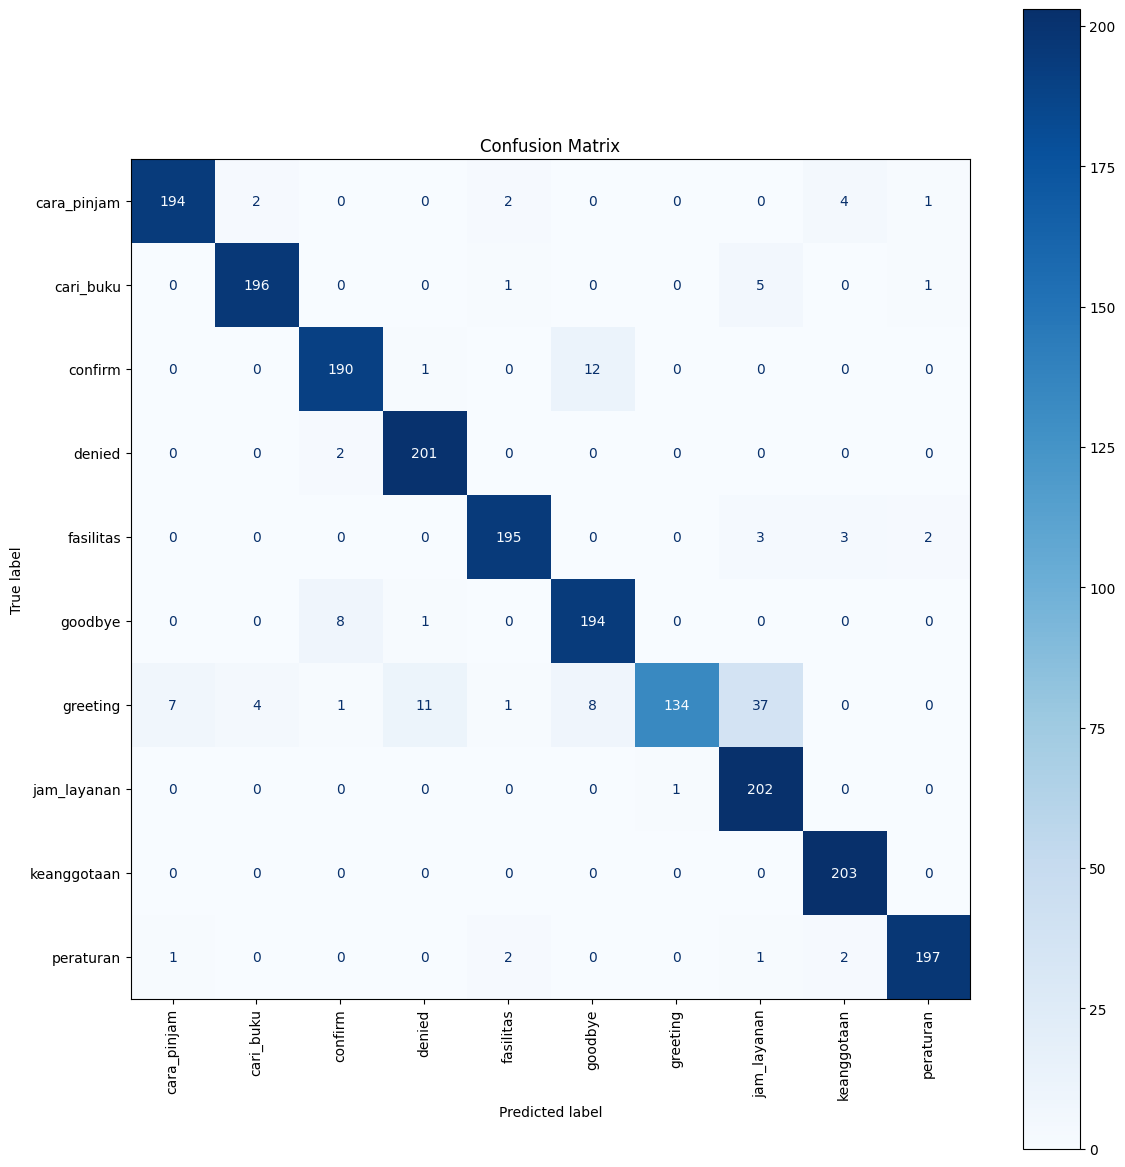

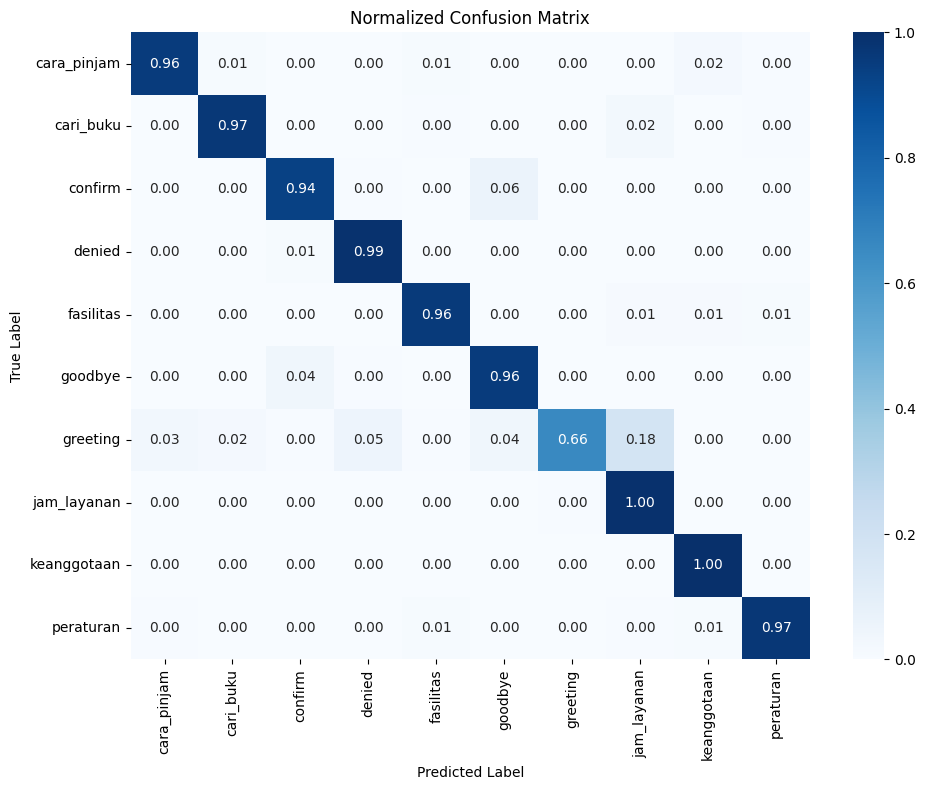

Saved 124 misclassified examples to /content/drive/MyDrive/E6/misclassified_examples.csv


In [ ]:
# @title Test Set
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pickle

# ==== Step 1: Load test data ====
test_df = pd.read_csv('test_balanced.csv')
test_texts = test_df['text'].tolist()
y_true = test_df['intent'].tolist()  # Assuming the true labels column is named 'intent'
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_PATH)

# Load model
model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)
# ==== Step 2: Load label encoder and intent_classes ====
with open(f"{MODEL_SAVE_PATH}/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)
with open(f"{MODEL_SAVE_PATH}/intent_classes.pkl", "rb") as f: # Load intent_classes
    intent_classes = pickle.load(f)

# Encode the ground truth labels into numerical format
y_true_encoded = label_encoder.transform(y_true)

# ==== Step 3: Define prediction function ====
def get_model_predictions(texts):
    model.eval()
    predictions = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():  # Important to avoid unnecessary gradient calculations
            outputs = model(**inputs)
            probs = outputs.logits.softmax(dim=1)
            pred = probs.argmax(dim=1).item()
            predictions.append(pred)
    return predictions

# ==== Step 4: Get predictions ====
y_pred = get_model_predictions(test_texts)
y_pred_labels = [intent_classes[i] for i in y_pred]

# ==== Step 5: Print Classification Report ====
print("=== Classification Report ===")
print(classification_report(y_true, y_pred_labels, target_names=intent_classes))

# ==== Step 6: Confusion Matrix (encoded labels for alignment) ====
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=intent_classes)

# ==== Step 7: Plot Confusion Matrix ====
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(xticks_rotation='vertical', ax=ax, cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, cmap="Blues", xticklabels=intent_classes, yticklabels=intent_classes, fmt=".2f")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Create a list to store misclassified examples
misclassified_examples = []

for i, (true, pred_idx, text) in enumerate(zip(y_true_encoded, y_pred, test_texts)):
    if true != pred_idx:
        misclassified_examples.append({
            'text': text,
            'true_label': intent_classes[true],
            'predicted_label': intent_classes[pred_idx]
        })

# Save misclassified examples to CSV
if misclassified_examples:
    misclassified_df = pd.DataFrame(misclassified_examples)
    misclassified_csv_path = f"{MODEL_SAVE_PATH}/misclassified_examples.csv"
    misclassified_df.to_csv(misclassified_csv_path, index=False)
    print(f"Saved {len(misclassified_examples)} misclassified examples to {misclassified_csv_path}")
else:
    print("No misclassified examples found.")



In [ ]:
# prompt: turn this /content/test.csv reduce some data so the data is balanced each class

# Load the test CSV file
test_df = pd.read_csv('/content/test.csv')

# Check initial distribution
print("Initial distribution of classes in /content/test.csv:")
print(test_df['intent'].value_counts())

# Group by intent and sample an equal number of examples from each class
# Find the minimum number of examples across all classes
min_samples = test_df['intent'].value_counts().min()
print(f"\nSampling {min_samples} examples from each class to balance the dataset.")

balanced_df = test_df.groupby('intent').apply(lambda x: x.sample(min_samples, random_state=42)).reset_index(drop=True)

# Shuffle the balanced dataframe
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check distribution after balancing
print("\nDistribution of classes after balancing:")
print(balanced_df['intent'].value_counts())

# Optionally save the balanced dataset
balanced_csv_path = '/content/test_balanced.csv'
balanced_df.to_csv(balanced_csv_path, index=False)
print(f"\nBalanced data saved to {balanced_csv_path}")

# You can now use balanced_df for your test set evaluation
# For example, replace the line `test_df = pd.read_csv('test.csv')`
# with `test_df = pd.read_csv('/content/test_balanced.csv')` in your evaluation cell.

# To use the balanced data in the 'Test Set' cell:
# Remove or comment out the original test_df loading line:
# # test_df = pd.read_csv('test.csv')
# Add the line to load the balanced data:
# test_df = pd.read_csv('/content/test_balanced.csv')



Initial distribution of classes in /content/test.csv:
intent
goodbye        242
confirm        233
greeting       228
fasilitas      224
peraturan      222
jam_layanan    221
cari_buku      220
cara_pinjam    220
keanggotaan    220
denied         203
Name: count, dtype: int64

Sampling 203 examples from each class to balance the dataset.

Distribution of classes after balancing:
intent
greeting       203
fasilitas      203
peraturan      203
jam_layanan    203
goodbye        203
cari_buku      203
keanggotaan    203
confirm        203
denied         203
cara_pinjam    203
Name: count, dtype: int64

Balanced data saved to /content/test_balanced.csv


<ipython-input-18-af76b8a334a1>:15: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
# @title Enhanced Model Testing Script with Comprehensive Analysis
import pandas as pd
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import json
import os
from datetime import datetime
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support, roc_curve, auc,
    precision_recall_curve, average_precision_score, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

class EnhancedModelTester:
    def __init__(self, model_save_path, test_csv_path):
        self.model_save_path = model_save_path
        self.test_csv_path = test_csv_path
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Create results directory
        self.results_dir = Path(model_save_path) / "test_results"
        self.results_dir.mkdir(exist_ok=True)

        # Create timestamp for this test run
        self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.run_dir = self.results_dir / f"test_run_{self.timestamp}"
        self.run_dir.mkdir(exist_ok=True)

        print(f"Results will be saved to: {self.run_dir}")

    def load_components(self):
        """Load model, tokenizer, and preprocessing components"""
        print("Loading model components...")

        # Load tokenizer and model
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_save_path)
        self.model = AutoModelForSequenceClassification.from_pretrained(self.model_save_path)
        self.model.to(self.device)
        self.model.eval()

        # Load label encoder and intent classes
        with open(f"{self.model_save_path}/label_encoder.pkl", "rb") as f:
            self.label_encoder = pickle.load(f)
        with open(f"{self.model_save_path}/intent_classes.pkl", "rb") as f:
            self.intent_classes = pickle.load(f)

        print(f"Model loaded on device: {self.device}")
        print(f"Number of classes: {len(self.intent_classes)}")

    def load_test_data(self):
        """Load and prepare test data"""
        print("Loading test data...")

        self.test_df = pd.read_csv(self.test_csv_path)
        self.test_texts = self.test_df['text'].tolist()
        self.y_true = self.test_df['intent'].tolist()
        self.y_true_encoded = self.label_encoder.transform(self.y_true)

        print(f"Test samples: {len(self.test_texts)}")
        print(f"Unique intents in test set: {len(set(self.y_true))}")

    def get_predictions_with_probabilities(self):
        """Get model predictions with confidence scores and probabilities"""
        print("Getting model predictions...")

        predictions = []
        probabilities = []
        confidence_scores = []

        # Process in batches for efficiency
        batch_size = 32

        for i in range(0, len(self.test_texts), batch_size):
            batch_texts = self.test_texts[i:i+batch_size]

            # Tokenize batch
            inputs = self.tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=512
            ).to(self.device)

            with torch.no_grad():
                outputs = self.model(**inputs)
                probs = torch.softmax(outputs.logits, dim=1)

                batch_preds = probs.argmax(dim=1).cpu().numpy()
                batch_probs = probs.cpu().numpy()
                batch_confidence = probs.max(dim=1)[0].cpu().numpy()

                predictions.extend(batch_preds)
                probabilities.extend(batch_probs)
                confidence_scores.extend(batch_confidence)

        self.y_pred = np.array(predictions)
        self.y_pred_labels = [self.intent_classes[i] for i in self.y_pred]
        self.probabilities = np.array(probabilities)
        self.confidence_scores = np.array(confidence_scores)

        print("Predictions completed.")

    def calculate_comprehensive_metrics(self):
        """Calculate comprehensive evaluation metrics"""
        print("Calculating comprehensive metrics...")

        # Basic metrics
        self.accuracy = accuracy_score(self.y_true_encoded, self.y_pred)
        precision, recall, f1, support = precision_recall_fscore_support(
            self.y_true_encoded, self.y_pred, average=None
        )

        # Macro and micro averages
        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
            self.y_true_encoded, self.y_pred, average='macro'
        )
        micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
            self.y_true_encoded, self.y_pred, average='micro'
        )
        weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
            self.y_true_encoded, self.y_pred, average='weighted'
        )

        # Matthews Correlation Coefficient
        self.mcc = matthews_corrcoef(self.y_true_encoded, self.y_pred)

        # Per-class metrics
        self.per_class_metrics = pd.DataFrame({
            'class': self.intent_classes,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'support': support
        })

        # Overall metrics summary
        self.overall_metrics = {
            'accuracy': self.accuracy,
            'macro_precision': macro_precision,
            'macro_recall': macro_recall,
            'macro_f1': macro_f1,
            'micro_precision': micro_precision,
            'micro_recall': micro_recall,
            'micro_f1': micro_f1,
            'weighted_precision': weighted_precision,
            'weighted_recall': weighted_recall,
            'weighted_f1': weighted_f1,
            'matthews_corr_coef': self.mcc,
            'total_samples': len(self.y_true),
            'num_classes': len(self.intent_classes)
        }

        print(f"Overall Accuracy: {self.accuracy:.4f}")
        print(f"Macro F1-Score: {macro_f1:.4f}")
        print(f"Matthews Correlation Coefficient: {self.mcc:.4f}")

    def analyze_confidence_distribution(self):
        """Analyze confidence score distribution"""
        self.confidence_analysis = {
            'mean_confidence': np.mean(self.confidence_scores),
            'std_confidence': np.std(self.confidence_scores),
            'min_confidence': np.min(self.confidence_scores),
            'max_confidence': np.max(self.confidence_scores),
            'median_confidence': np.median(self.confidence_scores),
            'q25_confidence': np.percentile(self.confidence_scores, 25),
            'q75_confidence': np.percentile(self.confidence_scores, 75)
        }

        # Confidence by correctness
        correct_mask = (self.y_true_encoded == self.y_pred)
        self.confidence_analysis.update({
            'mean_confidence_correct': np.mean(self.confidence_scores[correct_mask]),
            'mean_confidence_incorrect': np.mean(self.confidence_scores[~correct_mask]),
            'std_confidence_correct': np.std(self.confidence_scores[correct_mask]),
            'std_confidence_incorrect': np.std(self.confidence_scores[~correct_mask])
        })

    def find_misclassified_examples(self):
        """Find and analyze misclassified examples with detailed information"""
        misclassified_data = []

        for i, (true_idx, pred_idx, text, confidence) in enumerate(
            zip(self.y_true_encoded, self.y_pred, self.test_texts, self.confidence_scores)
        ):
            if true_idx != pred_idx:
                # Get top 3 predictions for this example
                top_3_indices = np.argsort(self.probabilities[i])[::-1][:3]
                top_3_probs = self.probabilities[i][top_3_indices]
                top_3_labels = [self.intent_classes[idx] for idx in top_3_indices]

                misclassified_data.append({
                    'sample_id': i,
                    'text': text,
                    'true_label': self.intent_classes[true_idx],
                    'predicted_label': self.intent_classes[pred_idx],
                    'confidence': confidence,
                    'true_probability': self.probabilities[i][true_idx],
                    'top_1_label': top_3_labels[0],
                    'top_1_prob': top_3_probs[0],
                    'top_2_label': top_3_labels[1] if len(top_3_labels) > 1 else '',
                    'top_2_prob': top_3_probs[1] if len(top_3_probs) > 1 else 0,
                    'top_3_label': top_3_labels[2] if len(top_3_labels) > 2 else '',
                    'top_3_prob': top_3_probs[2] if len(top_3_probs) > 2 else 0,
                    'text_length': len(text),
                    'word_count': len(text.split())
                })

        self.misclassified_df = pd.DataFrame(misclassified_data)

    def create_confusion_matrix_analysis(self):
        """Create detailed confusion matrix analysis"""
        self.cm = confusion_matrix(self.y_true_encoded, self.y_pred)
        self.cm_normalized = self.cm.astype('float') / self.cm.sum(axis=1)[:, np.newaxis]

        # Find most confused pairs
        confused_pairs = []
        for i in range(len(self.intent_classes)):
            for j in range(len(self.intent_classes)):
                if i != j and self.cm[i, j] > 0:
                    confused_pairs.append({
                        'true_class': self.intent_classes[i],
                        'predicted_class': self.intent_classes[j],
                        'count': self.cm[i, j],
                        'percentage': self.cm_normalized[i, j] * 100
                    })

        self.confused_pairs_df = pd.DataFrame(confused_pairs).sort_values(
            'count', ascending=False
        )

    def generate_visualizations(self):
        """Generate comprehensive visualizations"""
        print("Generating visualizations...")

        # Set style
        plt.style.use('default')
        sns.set_palette("husl")

        # 1. Confusion Matrix (Absolute)
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(self.cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.intent_classes, yticklabels=self.intent_classes, ax=ax)
        plt.title('Confusion Matrix (Absolute Counts)', fontsize=16, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(self.run_dir / 'confusion_matrix_absolute.png', dpi=300, bbox_inches='tight')
        plt.close()

        # 2. Confusion Matrix (Normalized)
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(self.cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                   xticklabels=self.intent_classes, yticklabels=self.intent_classes, ax=ax)
        plt.title('Confusion Matrix (Normalized)', fontsize=16, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(self.run_dir / 'confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
        plt.close()

        # 3. Per-class Performance
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Precision
        axes[0].barh(self.intent_classes, self.per_class_metrics['precision'])
        axes[0].set_title('Precision by Class', fontweight='bold')
        axes[0].set_xlabel('Precision')
        axes[0].set_xlim(0, 1)

        # Recall
        axes[1].barh(self.intent_classes, self.per_class_metrics['recall'])
        axes[1].set_title('Recall by Class', fontweight='bold')
        axes[1].set_xlabel('Recall')
        axes[1].set_xlim(0, 1)

        # F1-Score
        axes[2].barh(self.intent_classes, self.per_class_metrics['f1_score'])
        axes[2].set_title('F1-Score by Class', fontweight='bold')
        axes[2].set_xlabel('F1-Score')
        axes[2].set_xlim(0, 1)

        plt.tight_layout()
        plt.savefig(self.run_dir / 'per_class_metrics.png', dpi=300, bbox_inches='tight')
        plt.close()

        # 4. Confidence Distribution
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Overall confidence distribution
        axes[0, 0].hist(self.confidence_scores, bins=50, alpha=0.7, edgecolor='black')
        axes[0, 0].set_title('Overall Confidence Distribution')
        axes[0, 0].set_xlabel('Confidence Score')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].axvline(np.mean(self.confidence_scores), color='red',
                          linestyle='--', label=f'Mean: {np.mean(self.confidence_scores):.3f}')
        axes[0, 0].legend()

        # Confidence by correctness
        correct_mask = (self.y_true_encoded == self.y_pred)
        axes[0, 1].hist([self.confidence_scores[correct_mask], self.confidence_scores[~correct_mask]],
                       bins=30, alpha=0.7, label=['Correct', 'Incorrect'], color=['green', 'red'])
        axes[0, 1].set_title('Confidence Distribution by Correctness')
        axes[0, 1].set_xlabel('Confidence Score')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].legend()

        # Confidence vs Accuracy scatter
        confidence_bins = np.linspace(0, 1, 11)
        bin_accuracies = []
        bin_centers = []
        for i in range(len(confidence_bins)-1):
            mask = (self.confidence_scores >= confidence_bins[i]) & (self.confidence_scores < confidence_bins[i+1])
            if mask.sum() > 0:
                bin_acc = (self.y_true_encoded[mask] == self.y_pred[mask]).mean()
                bin_accuracies.append(bin_acc)
                bin_centers.append((confidence_bins[i] + confidence_bins[i+1]) / 2)

        axes[1, 0].plot(bin_centers, bin_accuracies, 'bo-', linewidth=2, markersize=8)
        axes[1, 0].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect Calibration')
        axes[1, 0].set_title('Calibration Plot')
        axes[1, 0].set_xlabel('Mean Predicted Confidence')
        axes[1, 0].set_ylabel('Accuracy')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Support by class
        axes[1, 1].barh(self.intent_classes, self.per_class_metrics['support'])
        axes[1, 1].set_title('Sample Count by Class')
        axes[1, 1].set_xlabel('Number of Samples')

        plt.tight_layout()
        plt.savefig(self.run_dir / 'confidence_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()

        print(f"Visualizations saved to: {self.run_dir}")

    def save_detailed_results(self):
        """Save all results to files"""
        print("Saving detailed results...")

        # 1. Overall metrics
        with open(self.run_dir / 'overall_metrics.json', 'w') as f:
            # Convert NumPy numeric types to standard floats before dumping
            serializable_overall_metrics = {
                k: v.item() if isinstance(v, (np.floating, np.integer, np.bool_)) else v
                for k, v in self.overall_metrics.items()
            }
            json.dump(serializable_overall_metrics, f, indent=4)

        # 2. Per-class metrics
        self.per_class_metrics.to_csv(self.run_dir / 'per_class_metrics.csv', index=False)

        # 3. Confidence analysis
        with open(self.run_dir / 'confidence_analysis.json', 'w') as f:
            # Convert NumPy numeric types to standard floats before dumping
            serializable_confidence_analysis = {
                k: v.item() if isinstance(v, (np.floating, np.integer, np.bool_)) else v
                for k, v in self.confidence_analysis.items()
            }
            json.dump(serializable_confidence_analysis, f, indent=4)

        # 4. Misclassified examples
        if not self.misclassified_df.empty:
            self.misclassified_df.to_csv(self.run_dir / 'misclassified_examples.csv', index=False)

            # Top 20 most confused examples (lowest confidence incorrect predictions)
            top_confused = self.misclassified_df.nsmallest(20, 'confidence')
            top_confused.to_csv(self.run_dir / 'top_confused_examples.csv', index=False)

        # 5. Confused pairs analysis
        self.confused_pairs_df.to_csv(self.run_dir / 'confused_pairs.csv', index=False)

        # 6. Classification report
        report = classification_report(self.y_true, self.y_pred_labels,
                                     target_names=self.intent_classes, output_dict=True)
        # The classification_report output_dict contains Python floats, but it's good practice
        # to double-check if it included any non-standard types unexpectedly.
        # For this specific case, it's usually fine, but we can add a check if needed.
        with open(self.run_dir / 'classification_report.json', 'w') as f:
            json.dump(report, f, indent=4)

        # 7. Detailed predictions with probabilities
        # Ensure any NumPy types are handled in the DataFrame before saving
        predictions_df = pd.DataFrame({
            'text': self.test_texts,
            'true_label': self.y_true,
            'predicted_label': self.y_pred_labels,
            # Convert NumPy confidence to standard float
            'confidence': [c.item() if isinstance(c, (np.floating, np.integer)) else c for c in self.confidence_scores],
            'correct': [bool(c) if isinstance(c, np.bool_) else c for c in (self.y_true_encoded == self.y_pred)] # Convert np.bool_ to bool
        })

        # Add top-3 predictions for each sample
        for i in range(len(self.test_texts)):
            top_3_indices = np.argsort(self.probabilities[i])[::-1][:3]
            for j, idx in enumerate(top_3_indices):
                predictions_df.loc[i, f'top_{j+1}_label'] = self.intent_classes[idx]
                # Convert NumPy probability to standard float
                predictions_df.loc[i, f'top_{j+1}_prob'] = self.probabilities[i][idx].item() if isinstance(self.probabilities[i][idx], np.floating) else self.probabilities[i][idx]


        predictions_df.to_csv(self.run_dir / 'detailed_predictions.csv', index=False)


        # 8. Test summary report
        self.generate_summary_report()

        print(f"All results saved to: {self.run_dir}")

    def generate_summary_report(self):
        """Generate a comprehensive summary report"""
        report_lines = []
        report_lines.append("=" * 80)
        report_lines.append("MODEL EVALUATION SUMMARY REPORT")
        report_lines.append("=" * 80)
        report_lines.append(f"Test Run Timestamp: {self.timestamp}")
        report_lines.append(f"Model Path: {self.model_save_path}")
        report_lines.append(f"Test Data: {self.test_csv_path}")
        report_lines.append(f"Device Used: {self.device}")
        report_lines.append("")

        # Dataset info
        report_lines.append("DATASET INFORMATION")
        report_lines.append("-" * 40)
        report_lines.append(f"Total test samples: {len(self.test_texts)}")
        report_lines.append(f"Number of classes: {len(self.intent_classes)}")
        report_lines.append(f"Classes: {', '.join(self.intent_classes)}")
        report_lines.append("")

        # Overall performance
        report_lines.append("OVERALL PERFORMANCE")
        report_lines.append("-" * 40)
        report_lines.append(f"Accuracy: {self.overall_metrics['accuracy']:.4f}")
        report_lines.append(f"Macro F1-Score: {self.overall_metrics['macro_f1']:.4f}")
        report_lines.append(f"Weighted F1-Score: {self.overall_metrics['weighted_f1']:.4f}")
        report_lines.append(f"Matthews Correlation Coefficient: {self.overall_metrics['matthews_corr_coef']:.4f}")
        report_lines.append("")

        # Confidence analysis
        report_lines.append("CONFIDENCE ANALYSIS")
        report_lines.append("-" * 40)
        report_lines.append(f"Mean confidence: {self.confidence_analysis['mean_confidence']:.4f}")
        report_lines.append(f"Std confidence: {self.confidence_analysis['std_confidence']:.4f}")
        report_lines.append(f"Mean confidence (correct): {self.confidence_analysis['mean_confidence_correct']:.4f}")
        report_lines.append(f"Mean confidence (incorrect): {self.confidence_analysis['mean_confidence_incorrect']:.4f}")
        report_lines.append("")

        # Top performing classes
        report_lines.append("TOP 5 PERFORMING CLASSES (by F1-Score)")
        report_lines.append("-" * 40)
        top_classes = self.per_class_metrics.nlargest(5, 'f1_score')
        for _, row in top_classes.iterrows():
            report_lines.append(f"{row['class']}: F1={row['f1_score']:.3f}, Precision={row['precision']:.3f}, Recall={row['recall']:.3f}")
        report_lines.append("")

        # Worst performing classes
        report_lines.append("WORST 5 PERFORMING CLASSES (by F1-Score)")
        report_lines.append("-" * 40)
        worst_classes = self.per_class_metrics.nsmallest(5, 'f1_score')
        for _, row in worst_classes.iterrows():
            report_lines.append(f"{row['class']}: F1={row['f1_score']:.3f}, Precision={row['precision']:.3f}, Recall={row['recall']:.3f}")
        report_lines.append("")

        # Most confused pairs
        report_lines.append("TOP 10 MOST CONFUSED CLASS PAIRS")
        report_lines.append("-" * 40)
        top_confused = self.confused_pairs_df.head(10)
        for _, row in top_confused.iterrows():
            report_lines.append(f"{row['true_class']} → {row['predicted_class']}: {row['count']} errors ({row['percentage']:.1f}%)")
        report_lines.append("")

        # Misclassification summary
        if not self.misclassified_df.empty:
            report_lines.append("MISCLASSIFICATION SUMMARY")
            report_lines.append("-" * 40)
            report_lines.append(f"Total misclassified: {len(self.misclassified_df)}")
            report_lines.append(f"Misclassification rate: {len(self.misclassified_df)/len(self.test_texts)*100:.2f}%")
            report_lines.append(f"Mean confidence of misclassified: {self.misclassified_df['confidence'].mean():.4f}")
            report_lines.append("")

        report_lines.append("=" * 80)

        # Save report
        with open(self.run_dir / 'summary_report.txt', 'w') as f:
            f.write('\n'.join(report_lines))

        # Print summary to console
        print('\n'.join(report_lines))

    def run_complete_evaluation(self):
        """Run the complete evaluation pipeline"""
        print("Starting comprehensive model evaluation...")
        print("=" * 60)

        self.load_components()
        self.load_test_data()
        self.get_predictions_with_probabilities()
        self.calculate_comprehensive_metrics()
        self.analyze_confidence_distribution()
        self.find_misclassified_examples()
        self.create_confusion_matrix_analysis()
        self.generate_visualizations()
        self.save_detailed_results()

        print("=" * 60)
        print("Evaluation completed successfully!")
        print(f"All results saved to: {self.run_dir}")

        return self.run_dir

# Run comprehensive evaluation using already defined MODEL_SAVE_PATH
tester = EnhancedModelTester(MODEL_SAVE_PATH, 'test_balanced.csv')
results_path = tester.run_complete_evaluation()

print(f"\nDetailed results available at: {results_path}")

In [ ]:
# @title Enhanced Test Set with Confidence Thresholding
import pandas as pd
import torch
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pickle
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==== Step 1: Load test data ====
test_df = pd.read_csv('tests.csv')
test_texts = test_df['text'].tolist()
y_true = test_df['intent'].tolist()  # Assuming the true labels column is named 'intent'

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)

# ==== Step 2: Load label encoder and intent_classes ====
with open(f"{MODEL_SAVE_PATH}/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)
with open(f"{MODEL_SAVE_PATH}/intent_classes.pkl", "rb") as f:
    intent_classes = pickle.load(f)

# Encode the ground truth labels into numerical format
y_true_encoded = label_encoder.transform(y_true)

# ==== Step 3: Define enhanced prediction function with confidence scores ====
def get_model_predictions_with_confidence(texts, confidence_threshold=0.0):
    """
    Get model predictions with confidence scores.
    If max confidence is below threshold, classify as "unknown"

    Args:
        texts: List of text inputs
        confidence_threshold: Minimum confidence to make a prediction (0.0-1.0)

    Returns:
        predictions: List of predicted class indices
        confidences: List of confidence scores
        pred_labels: List of predicted class labels
    """
    model.eval()
    predictions = []
    confidences = []
    pred_labels = []

    # Add "unknown" class if it doesn't exist
    unknown_idx = len(intent_classes)
    all_classes = intent_classes.tolist()
    if "unknown" not in all_classes:
        all_classes.append("unknown")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            probs = outputs.logits.softmax(dim=1)
            confidence, pred = torch.max(probs, dim=1)
            confidence = confidence.item()
            pred = pred.item()

            # If confidence is below threshold, classify as unknown
            if confidence < confidence_threshold:
                predictions.append(unknown_idx)  # Unknown class index
                pred_labels.append("unknown")
            else:
                predictions.append(pred)
                pred_labels.append(intent_classes[pred])

            confidences.append(confidence)

    return predictions, confidences, pred_labels

# ==== Step 4: Function to evaluate at different confidence thresholds ====
def evaluate_with_thresholds(thresholds=[0.0, 0.3, 0.5, 0.7, 0.9]):
    """Evaluate model with different confidence thresholds"""
    results = {}

    for threshold in thresholds:
        print(f"\n=== Evaluating with confidence threshold: {threshold} ===")
        y_pred, confidences, y_pred_labels = get_model_predictions_with_confidence(
            test_texts, confidence_threshold=threshold
        )

        # Create extended true labels (for comparison with unknown predictions)
        extended_true_labels = y_true.copy()

        # Create classification report
        print("Classification Report:")
        # We need to handle the case where "unknown" might not be in predictions
        unique_labels = sorted(set(y_pred_labels + ["unknown"]))
        report = classification_report(extended_true_labels, y_pred_labels, labels=unique_labels)
        print(report)

        # Store results
        results[threshold] = {
            'y_pred': y_pred,
            'confidences': confidences,
            'y_pred_labels': y_pred_labels,
            'report': report
        }

    return results

# ==== Step 5: Run standard evaluation (without threshold) ====
y_pred_standard, confidences_standard, y_pred_labels_standard = get_model_predictions_with_confidence(
    test_texts, confidence_threshold=0.0
)

print("=== Standard Classification Report (No Threshold) ===")
print(classification_report(y_true, y_pred_labels_standard, target_names=intent_classes))

# ==== Step 6: Create and plot standard confusion matrix ====
cm = confusion_matrix(y_true_encoded, y_pred_standard)
plt.figure(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=intent_classes)
disp.plot(xticks_rotation='vertical', cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ==== Step 7: Plot normalized confusion matrix ====
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, cmap="Blues", xticklabels=intent_classes, yticklabels=intent_classes, fmt=".2f")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# ==== Step 8: Plot confidence distribution ====
plt.figure(figsize=(10, 6))
plt.hist(confidences_standard, bins=20, alpha=0.7)
plt.axvline(x=0.5, color='r', linestyle='--', label='Example threshold (0.5)')
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Predictions")
plt.legend()
plt.tight_layout()
plt.show()

# ==== Step 9: Plot confidence by class ====
confidence_by_class = {}
for true_label, pred_label, conf in zip(y_true, y_pred_labels_standard, confidences_standard):
    if true_label not in confidence_by_class:
        confidence_by_class[true_label] = []
    confidence_by_class[true_label].append(conf)

plt.figure(figsize=(12, 6))
boxplot_data = [confidence_by_class[label] for label in intent_classes if label in confidence_by_class]
plt.boxplot(boxplot_data, labels=[label for label in intent_classes if label in confidence_by_class])
plt.title("Confidence Distribution by True Class")
plt.xlabel("True Class")
plt.ylabel("Confidence Score")
plt.xticks(rotation=90)
plt.axhline(y=0.5, color='r', linestyle='--', label='Example threshold (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

# ==== Step 10: Save misclassified examples ====
misclassified_examples = []
for i, (true, pred_idx, text, confidence) in enumerate(zip(y_true, y_pred_labels_standard, test_texts, confidences_standard)):
    if true != pred_idx:
        misclassified_examples.append({
            'text': text,
            'true_label': true,
            'predicted_label': pred_idx,
            'confidence': confidence
        })

# Save misclassified examples to CSV
if misclassified_examples:
    misclassified_df = pd.DataFrame(misclassified_examples)
    misclassified_df = misclassified_df.sort_values('confidence', ascending=True)  # Sort by confidence
    misclassified_csv_path = f"{MODEL_SAVE_PATH}/misclassified_examples.csv"
    misclassified_df.to_csv(misclassified_csv_path, index=False)
    print(f"Saved {len(misclassified_examples)} misclassified examples to {misclassified_csv_path}")

    # Display some examples with lowest confidence
    print("\n=== Examples with Lowest Confidence (Most Likely Errors) ===")
    print(misclassified_df.head(10))
else:
    print("No misclassified examples found.")

# ==== Step 11: Try different confidence thresholds ====
print("\n=== Evaluating Model with Different Confidence Thresholds ===")
threshold_results = evaluate_with_thresholds([0.0, 0.3, 0.5, 0.7, 0.9])

# ==== Step 12: Plot impact of threshold on accuracy and unknown rate ====
thresholds = list(threshold_results.keys())
unknown_rates = []
accuracies = []

for threshold in thresholds:
    # Calculate unknown rate
    unknown_count = y_pred_labels_standard.count("unknown") if "unknown" in y_pred_labels_standard else 0
    unknown_rates.append(unknown_count / len(test_texts))

    # Extract accuracy from classification report
    report_lines = threshold_results[threshold]['report'].split('\n')
    accuracy_line = [line for line in report_lines if 'accuracy' in line][0]
    accuracy = float(accuracy_line.split()[-1])
    accuracies.append(accuracy)

# Plot threshold impact
plt.figure(figsize=(10, 6))
plt.plot(thresholds, accuracies, 'b-', marker='o', label='Accuracy')
plt.plot(thresholds, unknown_rates, 'r-', marker='x', label='Unknown Rate')
plt.title("Impact of Confidence Threshold")
plt.xlabel("Confidence Threshold")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==== Step 13: Interactive threshold selection (optional) ====
def interactive_threshold_selection():
    """Allow user to input a custom threshold and see results"""
    while True:
        try:
            custom_threshold = float(input("\nEnter a custom confidence threshold (0.0-1.0) or -1 to exit: "))
            if custom_threshold == -1:
                break
            if 0.0 <= custom_threshold <= 1.0:
                print(f"\n=== Evaluating with custom threshold: {custom_threshold} ===")
                _, _, y_pred_labels_custom = get_model_predictions_with_confidence(
                    test_texts, confidence_threshold=custom_threshold
                )

                # Create classification report
                print("Classification Report:")
                unique_labels = sorted(set(y_pred_labels_custom + ["unknown"]))
                report = classification_report(y_true, y_pred_labels_custom, labels=unique_labels)
                print(report)
            else:
                print("Threshold must be between 0.0 and 1.0.")
        except ValueError:
            print("Please enter a valid number.")

# Uncomment to use interactive mode
# interactive_threshold_selection()

print("\nAnalysis complete! You can now determine the optimal confidence threshold for your application.")

In [ ]:
# @title Teks
test_sentences = [
    # GREETING
    "Halo, selamat pagi!",
    "Apa kabar?",
    "Hai, bot!",
    "Permisi, boleh bertanya?",
    "Yo, ada orang di sana?",

    # GOODBYE
    "Terima kasih, sampai jumpa.",
    "Ok, saya pergi dulu.",
    "Sampai nanti!",
    "Dadah, bot.",
    "Aku akan kembali nanti.",

    # CONFIRM
    "Iya, benar.",
    "Betul sekali.",
    "Ya, saya setuju.",
    "Tentu saja.",
    "Itu yang saya maksud.",

    # DENIED
    "Tidak, bukan itu.",
    "Salah.",
    "Bukan, maksud saya yang lain.",
    "Enggak.",
    "Saya tidak yakin dengan itu.",

    # AMBIGUOUS (bisa mengecoh)
    "Saya rasa tidak perlu, tapi ya juga boleh.",
    "Mungkin... tapi entahlah.",
    "Terserah kamu aja deh.",
    "Boleh iya, boleh juga tidak.",
    "Ya tapi tidak juga sih...",
    "p",
    "test",
    "y",
    "g",
    "N"
]


In [ ]:
# @title self prediksi inference (bugged)
# If you want to load an existing model and run predictions
run_prediction_demo_enhanced( #model, tokenizer, intent_classes, label_encoder, method=ood_method
    model_path=MODEL_SAVE_PATH,  # Your MODEL_SAVE_PATH
    method='combined',  # Which OOD detection method to use
    test_texts=test_sentences
)

Loading dataset: /content/train2.xlsx
Detected Excel file: /content/train2.xlsx
Converted Excel file to CSV: /content/train2.csv
Dataset dimuat dengan 1500 baris
Loading paraphrase model...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.94k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/777k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.37M [00:00<?, ?B/s]

...

  Created 1130 regular augmentations for 'keanggotaan'

Processing intent 'cara_pinjam' with factor 6.06x


Augmenting 'cara_pinjam': 100%|██████████| 165/165 [03:15<00:00,  1.18s/it]


  Created 1194 regular augmentations for 'cara_pinjam'

Processing intent 'peraturan' with factor 6.06x


Augmenting 'peraturan': 100%|██████████| 165/165 [03:17<00:00,  1.20s/it]


  Created 1165 regular augmentations for 'peraturan'

Applying controlled paraphrase generation...
  Processing 165 texts for intent 'cari_buku'
    Added 263 controlled paraphrases
  Processing 130 texts for intent 'confirm'
    Added 100 controlled paraphrases
  Processing 125 texts for intent 'denied'
    Added 137 controlled paraphrases
  Processing 165 texts for intent 'fasilitas'
    Added 300 controlled paraphrases
  Processing 125 texts for intent 'goodbye'
    Added 105 controlled paraphrases
  Processing 130 texts for intent 'greeting'
    Added 103 controlled paraphrases
  Processing 165 texts for intent 'jam_layanan'
    Added 280 controlled paraphrases
  Processing 165 texts for intent 'keanggotaan'
    Added 284 controlled paraphrases
  Processing 165 texts for intent 'cara_pinjam'
    Added 297 controlled paraphrases
  Processing 165 texts for intent 'peraturan'
    Added 285 controlled paraphrases

Balancing final dataset...

Final dataset statistics:
  cari_buku: 1000 

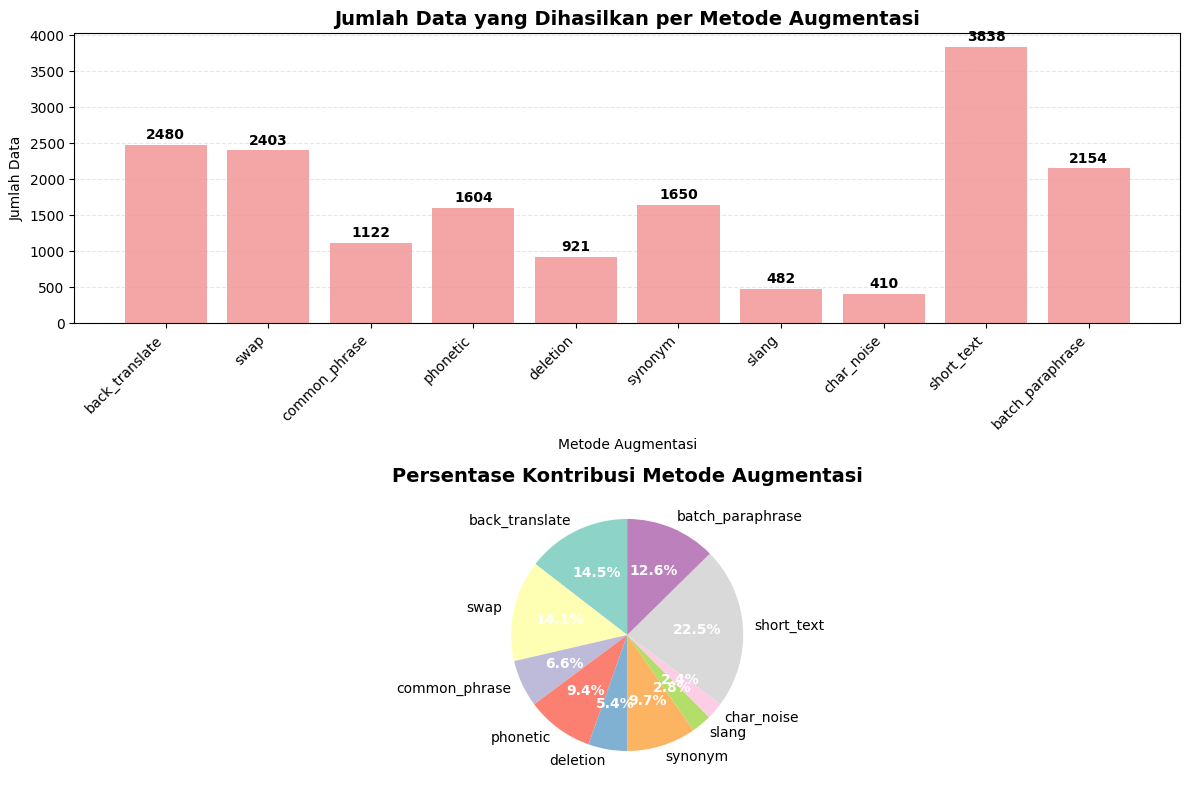


STATISTIK METODE AUGMENTASI
Total data augmentasi: 17064

Detail per metode:
  short_text          :   3838 data ( 22.5%)
  back_translate      :   2480 data ( 14.5%)
  swap                :   2403 data ( 14.1%)
  batch_paraphrase    :   2154 data ( 12.6%)
  synonym             :   1650 data (  9.7%)
  phonetic            :   1604 data (  9.4%)
  common_phrase       :   1122 data (  6.6%)
  deletion            :    921 data (  5.4%)
  slang               :    482 data (  2.8%)
  char_noise          :    410 data (  2.4%)


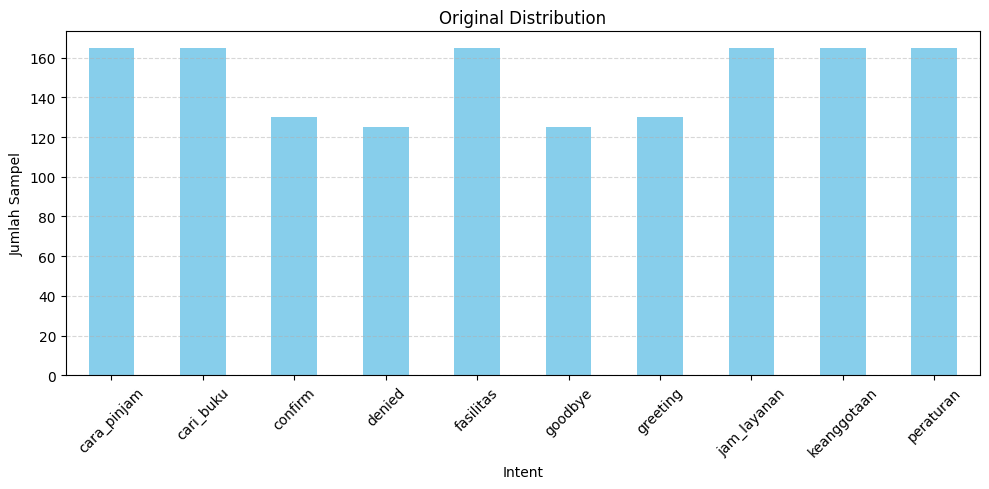

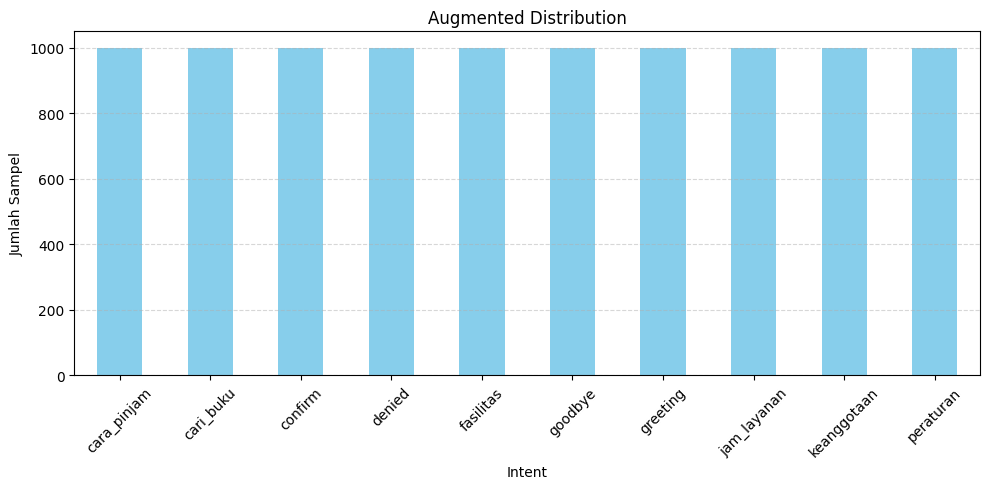

Comprehensive report saved to: /content/drive/MyDrive/fucking e 7 again i dont know/dataset/reports/augmentation_report.txt

Summary:
  Original samples: 1500
  Final samples: 10000
  Added samples: 8500
  Augmentation ratio: 6.67x
  Processing time: 1729.49 seconds
  Method distribution quality: GOOD


In [4]:
# @title Dataset Augmentation for Indonesian NLP - Improved Version
import pandas as pd
import random
import re
import nltk
import torch
import time
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from nltk.corpus import wordnet
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from deep_translator import GoogleTranslator
from collections import defaultdict, Counter
from tqdm import tqdm
import Levenshtein as lev  # For better text difference calculation
augmentation_method_counts = defaultdict(int)
# Download WordNet data (if not already downloaded)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# =========[ KONFIGURASI ]=========
# After your drive mount and FName setup, add:
DATASET_SAVE_PATH = f"{MODEL_SAVE_PATH}/dataset"
# Create directories if they don't exist
os.makedirs(DATASET_SAVE_PATH, exist_ok=True)
os.makedirs(f"{DATASET_SAVE_PATH}/reports", exist_ok=True)

INPUT_FILE = "/content/train2.xlsx" # @param {"type":"string"}
DATA_TYPE = "train" # @param ["train", "val", "test"]
TARGET_SAMPLES_PER_CLASS = 1000    # @param {type:"integer"} Target jumlah sampel per kelas
NOISE_INTENSITY = 0.7             # @param {type:"number"} Control how aggressive augmentations are (0.1-1.0)
USE_PARAPHRASE_MODEL = False       # @param {type:"boolean"} Aktifkan atau matikan paraphrase
USE_BACK_TRANSLATION = False       # @param {type:"boolean"} Aktifkan atau matikan back-translation
MIN_AUGMENTATIONS_PER_SAMPLE = 2  # @param {type:"integer"} Minimum augmentasi per sampel asli
MAX_AUGMENTATIONS_PER_SAMPLE = 20  # @param {type:"integer"} Maximum augmentasi per sampel asli (reduced from 10)
BATCH_SIZE = 16                   # @param {type:"integer"} Untuk batch processing
PARAPHRASE_RATIO = 0.4            # @param {type:"number"} Maksimal 40% dari total augmentasi adalah paraphrase
REGULAR_AUG_RATIO = 0.6           # @param {type:"number"} Minimal 60% dari total augmentasi adalah metode lain

def load_from_json(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_all_dictionaries():
    all_dicts = load_from_json('/content/ChatbotPerpusBipa/kamus.json')

    id_synonyms = all_dicts['id_synonyms']
    common_slang = all_dicts['common_slang']
    intent_slang = all_dicts['intent_slang']
    phonetic_dict = all_dicts['phonetic_dict']
    protected_intent_words = all_dicts['protected_intent_words']

    return id_synonyms, common_slang, intent_slang, phonetic_dict, protected_intent_words

# Option 2:
id_synonyms, common_slang, intent_slang, phonetic_dict, protected_intent_words = load_all_dictionaries()

# =========[ READ & VALIDATE FILE ]=========
def read_dataset(file_path):
    """Membaca dataset dari file CSV atau XLSX"""
    print(f"Loading dataset: {file_path}")

    file_ext = os.path.splitext(file_path)[1].lower()

    if file_ext == '.xlsx':
        print(f"Detected Excel file: {file_path}")
        df = pd.read_excel(file_path)
        # Konversi ke CSV untuk kompatibilitas
        csv_path = file_path.replace('.xlsx', '.csv')
        df.to_csv(csv_path, index=False)
        print(f"Converted Excel file to CSV: {csv_path}")
    elif file_ext == '.csv':
        print(f"Detected CSV file: {file_path}")
        df = pd.read_csv(file_path)
    else:
        raise ValueError(f"Format file tidak didukung: {file_ext}. Harap gunakan file CSV atau XLSX.")

    df = df.dropna()
    print(f"Dataset dimuat dengan {len(df)} baris")

    return df

# =========[ INITIALIZE PARAPHRASE MODEL IF NEEDED ]=========
def initialize_paraphrase_model():
    """Initialize paraphrase model if enabled"""
    if USE_PARAPHRASE_MODEL:
        print("Loading paraphrase model...")
        start_time = time.time()
        tokenizer = AutoTokenizer.from_pretrained("Wikidepia/IndoT5-base-paraphrase")
        model = AutoModelForSeq2SeqLM.from_pretrained("Wikidepia/IndoT5-base-paraphrase")

        # Move model to GPU if available
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = model.to(device)
        print(f"Model loaded in {time.time() - start_time:.2f} seconds. Using device: {device}")
        return model, tokenizer
    return None, None

# =========[ AUGMENTATION METHODS ]=========
def get_better_synonym(word):
    """Get synonym from custom dictionary or return the original word"""
    word_lower = word.lower()
    if word_lower in id_synonyms:
        synonyms = id_synonyms[word_lower]
        return random.choice(synonyms)
    return word

def replace_with_synonym(sentence):
    """Replace words with synonyms while preserving capitalization"""
    words = sentence.split()
    new_words = []

    # Limit the number of words to replace to avoid excessive changes
    num_to_replace = min(2, max(1, int(len(words) * 0.2)))
    indices_to_replace = random.sample(range(len(words)), k=min(num_to_replace, len(words)))

    for i, word in enumerate(words):
        if i in indices_to_replace:
            synonym = get_better_synonym(word)
            # Preserve capitalization
            if word and word[0].isupper() and synonym:
                synonym = synonym[0].upper() + synonym[1:]
            new_words.append(synonym)
        else:
            new_words.append(word)

    return " ".join(new_words)

def back_translate(sentence):
    """Translate to English and back to Indonesian with safety checks"""
    if not USE_BACK_TRANSLATION:
        return sentence

    # Skip very short sentences
    if len(sentence.split()) < 3:
        return sentence

    try:
        # First to English
        translated = GoogleTranslator(source='id', target='en').translate(sentence)
        # Then back to Indonesian
        back_translated = GoogleTranslator(source='en', target='id').translate(translated)

        # Safety checks
        if back_translated and len(back_translated.split()) >= len(sentence.split()) * 0.7:
            # Calculate how different the result is
            similarity = 1 - (lev.distance(sentence.lower(), back_translated.lower()) / max(len(sentence), len(back_translated)))
            # If too different or too similar, return original
            if similarity < 0.3 or similarity > 0.9:
                return sentence
            return back_translated
        return sentence
    except Exception:
        return sentence

def add_typo(sentence):
    """Add a single typo by replacing a character, with reduced probability"""
    # Skip for very short sentences or with low global noise setting
    if len(sentence) < 10 or random.random() > NOISE_INTENSITY:
        return sentence

    chars = list(sentence)
    if len(chars) > 3:
        # Try to find a good character to modify (not first or last character)
        candidates = [i for i in range(1, len(chars)-1) if chars[i].isalpha()]
        if candidates:
            idx = random.choice(candidates)
            # Get neighboring letters on keyboard for more realistic typos
            keyboard_neighbors = {
                'q': 'wsa', 'w': 'qeasd', 'e': 'wrsdf', 'r': 'etdfg',
                't': 'ryfgh', 'y': 'tughj', 'u': 'yihjk', 'i': 'uojkl',
                'o': 'ipkl', 'p': 'ol',
                'a': 'qwszx', 's': 'awedcxz', 'd': 'serfcvx', 'f': 'drtgvbc',
                'g': 'ftyhvbn', 'h': 'gyujbnm', 'j': 'huiknm', 'k': 'jiolm',
                'l': 'kop',
                'z': 'asx', 'x': 'zsdc', 'c': 'xdfv', 'v': 'cfgb',
                'b': 'vghn', 'n': 'bhjm', 'm': 'njk'
            }
            char = chars[idx].lower()
            if char in keyboard_neighbors:
                chars[idx] = random.choice(keyboard_neighbors[char])

    return "".join(chars)

def random_deletion(sentence, p=0.1):  # Reduced probability from 0.2
    """Delete words with probability p"""
    words = sentence.split()

    # Don't delete from short sentences
    if len(words) <= 4:
        return sentence

    # Don't delete too many words
    max_deletions = max(1, int(len(words) * 0.1))
    deletion_count = 0

    new_words = []
    for word in words:
        if random.uniform(0, 1) > p or deletion_count >= max_deletions:
            new_words.append(word)
        else:
            deletion_count += 1

    # Make sure we don't delete everything
    if not new_words:
        return sentence

    return " ".join(new_words)

def random_swap(sentence, n=1):
    """Swap n pairs of words"""
    words = sentence.split()
    if len(words) < 4:  # Don't swap in very short sentences
        return sentence

    # Limit swaps to just 1 for shorter sentences
    if len(words) < 8:
        n = 1

    for _ in range(min(n, len(words)//3)):  # Reduced number of swaps
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]

    return " ".join(words)

def phonetic_augmentation(sentence):
    """Apply phonetic substitutions common in Indonesian chat"""
    words = sentence.split()
    new_words = []

    # Limit substitutions to maintain readability
    max_substitutions = min(2, max(1, int(len(words) * 0.2)))
    substitution_count = 0

    for word in words:
        word_lower = word.lower()
        if word_lower in phonetic_dict and substitution_count < max_substitutions:
            new_word = random.choice(phonetic_dict[word_lower])
            # Preserve capitalization
            if word and word[0].isupper():
                new_word = new_word[0].upper() + new_word[1:]
            new_words.append(new_word)
            substitution_count += 1
        else:
            new_words.append(word)

    return " ".join(new_words)

def apply_slang_typo(text, intent, intensity=1.0):
    """Apply slang replacements with controllable intensity"""
    # Combine common slang with intent-specific slang
    slang_dict = common_slang.copy()
    if intent in intent_slang:
        slang_dict.update(intent_slang[intent])

    # Create regex patterns from the slang dictionary
    patterns = {
        re.compile(rf'\b{k}\b', re.IGNORECASE): v for k, v in slang_dict.items()
    }

    # Apply only a few patterns based on intensity and text length
    max_replacements = min(2, max(1, int(len(text.split()) * 0.2)))
    patterns_to_use = random.sample(
        list(patterns.items()),
        k=min(max_replacements, int(len(patterns) * min(0.3, intensity * 0.5)))
    )

    for pattern, replacement in patterns_to_use:
        text = pattern.sub(replacement, text)

    return text

def character_noise(text, intensity=1.0):
    """Add typos like character swaps, insertions, deletions with reduced intensity"""
    # Skip for very short texts
    if len(text) < 10 or random.random() > NOISE_INTENSITY:
        return text

    chars = list(text)
    # Significantly reduce swap probability
    swap_prob = min(0.03, intensity * 0.01)  # Lower from 0.1 to 0.03

    # Limit to just one or two swaps per sentence
    max_swaps = min(1, int(len(chars) * 0.05))
    swap_count = 0

    for i in range(len(chars)-1):
        if random.random() < swap_prob and swap_count < max_swaps:
            # Don't swap punctuation or spaces
            if chars[i].isalpha() and chars[i+1].isalpha():
                chars[i], chars[i+1] = chars[i+1], chars[i]
                swap_count += 1

    return ''.join(chars)

def add_common_phrase(sentence):
    """Add a common Indonesian chat phrase with probability control"""
    # Skip for longer sentences or with probability
    if len(sentence.split()) > 8 or random.random() > 0.33:  # Only 30% chance
        return sentence

    common_phrases = ["sih", "ya", "dong", "cuy", "bro", "lah", "deh", "nigga", "min"]
    return sentence + " " + random.choice(common_phrases)

def short_text_augmentation(text, intent):
    """Special augmentation for very short texts like greetings and goodbyes"""
    # For very short texts, add filler words or expressions
    fillers = {
        'greeting': ['', ' ya', ' kak', ' min', ' gan', ' bro', ' sis', ' admin', '!'],
        'goodbye': ['', ' ya', ' kak', ' min', ' semuanya', '!'],
        'confirm': ['', ' kok', ' dong', ' banget', ' sih', ' tentu', ' lah', '!'],
        'denied': ['', ' sih', ' kok', ' ah', ' deh', ' lah', '!'],
    }

    if intent in fillers and len(text.split()) <= 3:
        # Add just one filler
        if random.random() < 0.7:  # 70% chance to add filler
            text += random.choice(fillers[intent])

    return text

def validate_augmentation(original, augmented):
    """Validate if augmentation is reasonable with stricter requirements"""
    # Skip if no change
    if augmented.lower() == original.lower():
        return False

    # Calculate word count difference
    orig_words = original.split()
    aug_words = augmented.split()

    # Check if length is reasonable
    if len(aug_words) < len(orig_words) * 0.6 or len(aug_words) > len(orig_words) * 1.4:
        return False

    # Calculate text similarity using Levenshtein distance
    normalized_distance = lev.distance(original.lower(), augmented.lower()) / max(len(original), len(augmented))
    # If too similar or too different, reject
    if normalized_distance < 0.03 or normalized_distance > 0.5:
        return False

    # Check for excessive non-standard characters
    non_indo_pattern = re.compile(r'[^a-zA-Z0-9\s.,?!\'"-:;()[\]{}]')
    if len(non_indo_pattern.findall(augmented)) > 3:
        return False

    # Check if individual words have been mangled too much
    if len(orig_words) == len(aug_words):
        word_changes = 0
        for i in range(len(orig_words)):
            # Check word edit distance
            if len(orig_words[i]) > 3 and lev.distance(orig_words[i], aug_words[i]) > len(orig_words[i]) * 0.5:
                word_changes += 1

        # Reject if too many words changed significantly
        if word_changes / len(orig_words) > 0.4:
            return False

    return True

def batch_paraphrase(model, tokenizer, sentences, batch_size=BATCH_SIZE):
    """Process paraphrasing in batches"""
    if not sentences or model is None or tokenizer is None:
        return []

    device = next(model.parameters()).device
    results = []

    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        inputs = tokenizer(["paraphrase: " + text + " </s>" for text in batch],
                         padding='longest', truncation=True, max_length=128,
                         return_tensors="pt").to(device)

        with torch.no_grad():  # Disable gradient calculation for inference
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_length=128,
                do_sample=True,
                top_k=200,  # Reduce from 200 to 120 for more conservative output
                top_p=0.98,
                temperature=NOISE_INTENSITY + 0.3, # Added temperature control
                early_stopping=False,
                num_return_sequences=min(3, BATCH_SIZE // len(batch))
            )

        decoded = [tokenizer.decode(outputs[j], skip_special_tokens=True)
                  for j in range(len(outputs))]
        results.extend(decoded)

    return results

# Combined augmentation strategies
def augment_text_with_tracking(text, intent, intensity=1.0):
    """Apply multiple augmentation techniques with method tracking"""
    # Scale intensity by global noise setting
    intensity = intensity * NOISE_INTENSITY

	# Global method usage control - tambahkan ini
    global augmentation_method_counts
    total_augmentations = sum(augmentation_method_counts.values())

    # Jika common_phrase sudah terlalu banyak, kurangi probabilitasnya
    common_phrase_ratio = augmentation_method_counts.get('common_phrase', 0) / max(1, total_augmentations)
    if common_phrase_ratio > 0.25:  # Jika lebih dari 25%
        # Kurangi drastis kemungkinan common_phrase dipilih
        skip_common_phrase = True
    else:
        skip_common_phrase = False

    # Protect intent-critical words
    protected = []
    if intent in protected_intent_words:
        for word in protected_intent_words[intent]:
            pattern = re.compile(rf'\b{word}\b', re.IGNORECASE)
            for match in pattern.finditer(text):
                placeholder = f"__PROTECTED_{len(protected)}__"
                text = text[:match.start()] + placeholder + text[match.end():]
                protected.append((placeholder, match.group(0)))

    # Available methods - reorder by safety
    # Available methods - reorder by safety
    methods = {
        'synonym': replace_with_synonym,
        'back_translate': back_translate if USE_BACK_TRANSLATION else None,
        'slang': lambda t: apply_slang_typo(t, intent, intensity),
        'common_phrase': add_common_phrase if not skip_common_phrase else None,  # Conditional
        'short_text': lambda t: short_text_augmentation(t, intent),
        'swap': random_swap,
        'deletion': random_deletion,
        'phonetic': phonetic_augmentation,
        'char_noise': lambda t: character_noise(t, intensity * 0.5),
        'typo': add_typo
    }

    # Remove None methods
    methods = {k: v for k, v in methods.items() if v is not None}

    # Choose augmentation methods based on text length and intent
    text_length = len(text.split())

    if text_length <= 3:
        method_choices = ['slang', 'short_text', 'synonym', 'common_phrase']
        num_methods = min(2, int(intensity * 2))
    else:
        # Kurangi frekuensi common_phrase dengan menghilangkan duplikasi
        method_choices = ['synonym', 'synonym', 'back_translate', 'slang', 'slang',
                          'swap', 'deletion', 'phonetic', 'char_noise', 'common_phrase']  # Pindah ke akhir
        num_methods = min(2, int(intensity * 1.5))

    method_choices = [m for m in method_choices if m in methods]

    if method_choices:
        # Weighted selection untuk mengurangi dominasi method tertentu
        method_weights = {
            'synonym': 3, 'back_translate': 2, 'slang': 2, 'swap': 2,
            'deletion': 2, 'phonetic': 2, 'char_noise': 1,
            'common_phrase': 1,  # Kurangi weight common_phrase
            'short_text': 2
        }

        # Filter method_choices berdasarkan weight
        weighted_choices = []
        for method in method_choices:
            weight = method_weights.get(method, 1)
            weighted_choices.extend([method] * weight)

        # Sample dengan replacement untuk menghindari dominasi
        selected_methods = []
        for _ in range(min(num_methods, len(method_choices))):
            if weighted_choices:
                method = random.choice(weighted_choices)
                selected_methods.append(method)
                # Remove beberapa instance untuk mengurangi kemungkinan dipilih lagi
                weighted_choices = [m for m in weighted_choices if m != method or random.random() > 0.7]
    else:
        selected_methods = []

    # Apply selected methods and track usage
    result = text
    methods_used = []
    for method_name in selected_methods:
        if method_name in methods:
            method = methods[method_name]
            old_result = result
            result = method(result)

            # Track if method actually changed the text
            if result != old_result:
                methods_used.append(method_name)
                augmentation_method_counts[method_name] += 1

    # Restore protected words
    for placeholder, original in protected:
        result = result.replace(placeholder, original)

    return result, methods_used

# Modifikasi fungsi augment_data untuk menggunakan tracking
def augment_data_with_tracking(text, intent):
    """Generate multiple augmentations with method tracking"""
    methods = [
        ('synonym_replacement', replace_with_synonym),
        ('back_translation', back_translate if USE_BACK_TRANSLATION else None),
        ('combined_augmentation', lambda t: augment_text_with_tracking(t, intent, 1.0)[0])
    ]

    methods = [(name, m) for name, m in methods if m is not None]

    augmented = set()
    for method_name, method in methods:
        try:
            if method_name == 'combined_augmentation':
                result, _ = augment_text_with_tracking(text, intent, 1.0)
            else:
                result = method(text)
                if result != text:
                    augmentation_method_counts[method_name] += 1

            if validate_augmentation(text, result):
                augmented.add(result)
        except Exception as e:
            print(f"Error applying {method_name}: {str(e)}")
            continue

    return list(augmented)

# Fungsi untuk visualisasi metode augmentasi
def plot_augmentation_methods():
    """Plot distribusi penggunaan metode augmentasi"""
    if not augmentation_method_counts:
        print("Tidak ada data metode augmentasi untuk divisualisasikan")
        return

    # Siapkan data
    methods = list(augmentation_method_counts.keys())
    counts = list(augmentation_method_counts.values())

    # Buat plot
    plt.figure(figsize=(12, 8))

    # Bar plot
    plt.subplot(2, 1, 1)
    bars = plt.bar(methods, counts, color='lightcoral', alpha=0.7)
    plt.title('Jumlah Data yang Dihasilkan per Metode Augmentasi', fontsize=14, fontweight='bold')
    plt.xlabel('Metode Augmentasi')
    plt.ylabel('Jumlah Data')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Tambahkan nilai di atas bar
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                str(count), ha='center', va='bottom', fontweight='bold')

    # Pie chart
    plt.subplot(2, 1, 2)
    colors = plt.cm.Set3(range(len(methods)))
    wedges, texts, autotexts = plt.pie(counts, labels=methods, autopct='%1.1f%%',
                                       colors=colors, startangle=90)
    plt.title('Persentase Kontribusi Metode Augmentasi', fontsize=14, fontweight='bold')

    # Perbaiki tampilan
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(f"{DATASET_SAVE_PATH}/reports/augmentation_methods_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Print statistik detail
    print("\n" + "="*50)
    print("STATISTIK METODE AUGMENTASI")
    print("="*50)

    total_augmented = sum(counts)
    print(f"Total data augmentasi: {total_augmented}")
    print("\nDetail per metode:")

    # Sort berdasarkan jumlah (descending)
    sorted_methods = sorted(augmentation_method_counts.items(), key=lambda x: x[1], reverse=True)

    for method, count in sorted_methods:
        percentage = (count / total_augmented) * 100 if total_augmented > 0 else 0
        print(f"  {method:20s}: {count:6d} data ({percentage:5.1f}%)")

    print("="*50)

def balance_samples(results_by_intent, target_samples_per_class, original_counts):
    """
    Balance samples by intent with preference toward reaching TARGET_SAMPLES_PER_CLASS
    """
    balanced_results = defaultdict(list)

    for intent, samples in results_by_intent.items():
        orig_count = original_counts.get(intent, 0)
        current_count = len(samples)

        # Keep all original data
        original_data = samples[:orig_count]
        balanced_results[intent].extend(original_data)

        # Get augmented samples (everything after original data)
        augmented_data = samples[orig_count:]

        # Calculate how many we need
        remaining_slots = target_samples_per_class - orig_count

        if remaining_slots > 0:
            # If we have enough augmented samples
            if len(augmented_data) >= remaining_slots:
                # Randomize selection
                random.shuffle(augmented_data)
                # Add what we need
                balanced_results[intent].extend(augmented_data[:remaining_slots])
            else:
                # If we don't have enough, add all augmented samples
                balanced_results[intent].extend(augmented_data)
                # And duplicate some if needed (to reach closer to target)
                shortage = remaining_slots - len(augmented_data)
                if shortage > 0 and len(augmented_data) > 0:
                    # Add duplicates of existing augmentations to help reach target
                    extras = random.choices(augmented_data, k=min(shortage, len(augmented_data) * 2))
                    balanced_results[intent].extend(extras)

    return balanced_results

def plot_distribution(data, title):
    """Plot distribution of samples by intent"""
    plt.figure(figsize=(10, 5))
    data['intent'].value_counts().sort_index().plot(kind='bar', color='skyblue')
    plt.title(title)
    plt.xlabel("Intent")
    plt.ylabel("Jumlah Sampel")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    filename = title.lower().replace(" ", "_").replace("distribution", "dist")
    plt.savefig(f"{DATASET_SAVE_PATH}/reports/{filename}.png", dpi=300, bbox_inches='tight')
    plt.show()

# ADD: New function to save comprehensive report
def save_augmentation_report(final_df, original_df, time_taken, output_path):
    """Save a comprehensive text report of the augmentation process"""
    report_path = f"{DATASET_SAVE_PATH}/reports/augmentation_report.txt"

    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("="*60 + "\n")
        f.write("DATASET AUGMENTATION REPORT\n")
        f.write("="*60 + "\n\n")

        # Original statistics
        f.write("ORIGINAL DATASET:\n")
        f.write("-" * 20 + "\n")
        original_counts = Counter(original_df['intent'])
        for intent, count in original_counts.items():
            f.write(f"  {intent}: {count}\n")
        f.write(f"Total original samples: {len(original_df)}\n\n")

        # Final statistics
        f.write("FINAL DATASET:\n")
        f.write("-" * 20 + "\n")
        final_counts = Counter(final_df['intent'])
        for intent, count in final_counts.items():
            orig = original_counts.get(intent, 0)
            added = count - orig
            f.write(f"  {intent}: {count} total ({orig} original + {added} augmented)\n")
        f.write(f"Total final samples: {len(final_df)}\n\n")

        # Method statistics
        f.write("AUGMENTATION METHODS USED:\n")
        f.write("-" * 30 + "\n")
        total_augmented = sum(augmentation_method_counts.values())
        for method, count in sorted(augmentation_method_counts.items(), key=lambda x: x[1], reverse=True):
            percentage = (count / total_augmented) * 100 if total_augmented > 0 else 0
            f.write(f"  {method:20s}: {count:6d} ({percentage:5.1f}%)\n")

        f.write(f"\nProcessing time: {time_taken:.2f} seconds\n")
        f.write(f"Augmentation ratio: {len(final_df) / len(original_df):.2f}x\n")

    print(f"Comprehensive report saved to: {report_path}")

# =========[ MAIN PROCESS ]=========
# Add target method ratios at module level
TARGET_METHOD_RATIOS = {
    'synonym': 0.25, 'back_translate': 0.15, 'slang': 0.15,
    'swap': 0.12, 'deletion': 0.10, 'phonetic': 0.10,
    'char_noise': 0.08, 'common_phrase': 0.05
}

def get_adaptive_weights(base_weights, current_counts, total_target):
    """Adjust weights based on current usage to maintain balance"""
    adjusted_weights = base_weights.copy()
    total_current = sum(current_counts.values())

    if total_current > 0:
        for method in adjusted_weights:
            current_ratio = current_counts.get(method, 0) / total_current
            target_ratio = base_weights[method]

            # Reduce weight if method is overused
            if current_ratio > target_ratio * 1.5:
                adjusted_weights[method] *= 0.5
            # Increase weight if method is underused
            elif current_ratio < target_ratio * 0.5:
                adjusted_weights[method] *= 1.5

    return adjusted_weights

def get_adaptive_method_selection(text_length, intensity, current_counts, total_augmentations, methods):
    """Get methods with adaptive weighting based on current distribution"""

    if text_length <= 3:
        base_weights = {'slang': 0.4, 'short_text': 0.3, 'synonym': 0.2, 'common_phrase': 0.1}
        num_methods = min(2, int(intensity * 2))
    else:
        base_weights = TARGET_METHOD_RATIOS.copy()
        num_methods = min(2, int(intensity * 1.5))

    # Apply adaptive weighting
    if total_augmentations > 50:  # Only adjust after some data
        adjusted_weights = get_adaptive_weights(base_weights, current_counts, total_augmentations)
    else:
        adjusted_weights = base_weights

    # Select methods based on adjusted weights
    available_methods = [m for m in adjusted_weights.keys() if m in methods]
    if available_methods:
        weights = [adjusted_weights[m] for m in available_methods]
        weights_sum = sum(weights)
        if weights_sum > 0:
            normalized_weights = [w/weights_sum for w in weights]
            try:
                selected = np.random.choice(
                    available_methods,
                    size=min(num_methods, len(available_methods)),
                    p=normalized_weights,
                    replace=False
                )
                return list(selected)
            except ValueError:
                # Fallback to random selection
                return random.sample(available_methods, min(num_methods, len(available_methods)))

    return []

def validate_method_distribution(target_ratios, actual_counts, tolerance=0.1):
    """Check if method distribution is within acceptable range"""
    total = sum(actual_counts.values())
    if total == 0:
        return True

    for method, target_ratio in target_ratios.items():
        actual_ratio = actual_counts.get(method, 0) / total
        if abs(actual_ratio - target_ratio) > tolerance:
            return False
    return True

def controlled_paraphrase_generation(texts_with_quotas, model, tokenizer):
    """Generate paraphrases with better control over quantity and quality"""
    results = []

    for text, quota in texts_with_quotas:
        if quota <= 0:
            continue

        try:
            # Generate multiple candidates
            candidates = batch_paraphrase(model, tokenizer, [text], batch_size=1)
            valid_paraphrases = []

            for para in candidates:
                if len(valid_paraphrases) >= quota:
                    break
                if para and validate_augmentation(text, para):
                    valid_paraphrases.append(para)

            results.extend(valid_paraphrases)

        except Exception as e:
            print(f"Error in controlled paraphrase generation: {e}")
            continue

    return results

def main():
    """Main process for dataset augmentation with improved distribution control"""
    # Set up file paths based on chosen data type
    if DATA_TYPE == "train":
        OUTPUT_FILE = "train.csv"
        OUTPUT_FILES = f"{DATASET_SAVE_PATH}/train_augmented.csv"
        output_files = OUTPUT_FILES
        input_file = INPUT_FILE
        output_file = OUTPUT_FILE
    elif DATA_TYPE == "val":
        OUTPUT_FILE = "val.csv"
        input_file = INPUT_FILE.replace("train", "val")
        output_file = OUTPUT_FILE.replace("train", "val")
    elif DATA_TYPE == "test":
        OUTPUT_FILE = "test.csv"
        input_file = INPUT_FILE.replace("train", "test")
        output_file = OUTPUT_FILE.replace("train", "test")
    else:
        input_file = INPUT_FILE
        output_file = OUTPUT_FILE

    # Read the dataset
    df = read_dataset(input_file)

    # Initialize paraphrase model if enabled
    model, tokenizer = initialize_paraphrase_model()

    # Count original samples per intent
    intent_counts = Counter(df['intent'])
    print("Original class distribution:")
    for intent, count in intent_counts.items():
        print(f"  {intent}: {count}")

    # Calculate augmentation factors for balancing
    augmentation_factors = {}
    for intent, count in intent_counts.items():
        if count >= TARGET_SAMPLES_PER_CLASS:
            augmentation_factors[intent] = 1  # Minimum factor
        else:
            factor = max(1, min(10, TARGET_SAMPLES_PER_CLASS / count))
            augmentation_factors[intent] = factor

    print("\nAugmentation factors:")
    for intent, factor in augmentation_factors.items():
        print(f"  {intent}: {factor:.2f}x")

    # Start augmentation process
    print("Starting balanced augmentation with improved distribution control...")
    start_time = time.time()

    augmented_results = defaultdict(list)
    paraphrase_candidates = defaultdict(list)

    # First, add all original data
    for _, row in df.iterrows():
        intent = row['intent']
        text = row['text']
        augmented_results[intent].append(text)

    # Initialize available methods for adaptive selection
    available_methods = {
        'synonym': replace_with_synonym,
        'back_translate': back_translate if USE_BACK_TRANSLATION else None,
        'slang': lambda t, intent=None: apply_slang_typo(t, intent or 'general', 1.0),
        'common_phrase': add_common_phrase,
        'short_text': lambda t, intent=None: short_text_augmentation(t, intent or 'general'),
        'swap': random_swap,
        'deletion': random_deletion,
        'phonetic': phonetic_augmentation,
        'char_noise': lambda t: character_noise(t, 1.0),
        'typo': add_typo
    }

    # Remove None methods
    available_methods = {k: v for k, v in available_methods.items() if v is not None}

    # Process each intent with controlled augmentation
    for intent, factor in augmentation_factors.items():
        original_count = intent_counts[intent]
        intent_df = df[df['intent'] == intent]

        print(f"\nProcessing intent '{intent}' with factor {factor:.2f}x")

        for _, row in tqdm(intent_df.iterrows(), desc=f"Augmenting '{intent}'", total=len(intent_df)):
            text = row['text']

            # Calculate needed augmentations for this sample
            num_augmentations = max(
                MIN_AUGMENTATIONS_PER_SAMPLE,
                min(MAX_AUGMENTATIONS_PER_SAMPLE, int(factor * 2.0))
            )

            # Calculate balanced allocation
            paraphrase_quota = int(num_augmentations * PARAPHRASE_RATIO) if USE_PARAPHRASE_MODEL else 0
            regular_quota = num_augmentations - paraphrase_quota

            # Add to paraphrase candidates with quota
            if USE_PARAPHRASE_MODEL and paraphrase_quota > 0:
                paraphrase_candidates[intent].append((text, paraphrase_quota))

            # Regular augmentations with adaptive method selection
            attempts = 0
            augmentations_created = 0
            max_attempts = regular_quota * 4

            while augmentations_created < regular_quota and attempts < max_attempts:
                attempts += 1

                # Get current augmentation counts for adaptive selection
                total_augmentations = sum(augmentation_method_counts.values())

                # Check distribution balance periodically
                if total_augmentations > 0 and total_augmentations % 100 == 0:
                    is_balanced = validate_method_distribution(
                        TARGET_METHOD_RATIOS,
                        augmentation_method_counts,
                        tolerance=0.15
                    )
                    if not is_balanced and total_augmentations % 500 == 0:  # Less frequent logging
                        print(f"  Adjusting method selection for better balance at {total_augmentations} augmentations...")

                # Use adaptive method selection
                text_length = len(text.split())
                intensity = min(1.0, NOISE_INTENSITY + (factor - 1) * 0.2)

                selected_methods = get_adaptive_method_selection(
                    text_length, intensity, augmentation_method_counts,
                    total_augmentations, available_methods
                )

                if not selected_methods:
                    # Fallback to random selection
                    method_choices = list(available_methods.keys())
                    if len(text.split()) <= 3:
                        method_choices = [m for m in method_choices if m in ['slang', 'short_text', 'synonym', 'common_phrase']]
                    selected_methods = random.sample(method_choices, min(2, len(method_choices)))

                # Apply selected methods
                aug_text = text
                methods_used = []

                for method_name in selected_methods:
                    if method_name in available_methods:
                        method = available_methods[method_name]
                        old_text = aug_text

                        try:
                            # Apply method with appropriate parameters
                            if method_name in ['slang', 'short_text']:
                                aug_text = method(aug_text, intent)
                            else:
                                aug_text = method(aug_text)

                            # Track if method actually changed the text
                            if aug_text != old_text:
                                methods_used.append(method_name)
                                augmentation_method_counts[method_name] += 1

                        except Exception as e:
                            print(f"Error applying {method_name}: {e}")
                            aug_text = old_text  # Revert on error

                # Validate and add augmentation
                if (aug_text.lower() != text.lower() and
                    validate_augmentation(text, aug_text) and
                    methods_used):  # Ensure at least one method was applied

                    augmented_results[intent].append(aug_text)
                    augmentations_created += 1

        print(f"  Created {sum(len(augmented_results[intent]) - intent_counts[intent] for intent in [intent])} regular augmentations for '{intent}'")

    # Process paraphrases with controlled generation
    if USE_PARAPHRASE_MODEL and model is not None:
        print("\nApplying controlled paraphrase generation...")

        for intent, text_quota_pairs in paraphrase_candidates.items():
            if not text_quota_pairs:
                continue

            print(f"  Processing {len(text_quota_pairs)} texts for intent '{intent}'")

            # Use controlled paraphrase generation
            paraphrased = controlled_paraphrase_generation(text_quota_pairs, model, tokenizer)

            # Add to results and track
            for para in paraphrased:
                augmented_results[intent].append(para)
                augmentation_method_counts['batch_paraphrase'] += 1

            print(f"    Added {len(paraphrased)} controlled paraphrases")

    # Balance the data
    print("\nBalancing final dataset...")
    balanced_data = balance_samples(augmented_results, TARGET_SAMPLES_PER_CLASS, intent_counts)

    # Final balancing to target size with method diversity preservation
    target_class_size = TARGET_SAMPLES_PER_CLASS

    for intent in balanced_data:
        current_samples = balanced_data[intent]
        orig_count = intent_counts.get(intent, 0)

        if len(current_samples) > target_class_size:
            # Keep all original data
            original_data = current_samples[:orig_count]
            augmented_data = current_samples[orig_count:]

            # Randomly select augmented data to keep
            needed = target_class_size - orig_count
            if needed > 0 and augmented_data:
                random.shuffle(augmented_data)
                balanced_data[intent] = original_data + augmented_data[:needed]
            else:
                balanced_data[intent] = original_data[:target_class_size]
        elif len(current_samples) < target_class_size:
            # Keep all data if under target
            balanced_data[intent] = current_samples

    # Create final balanced dataframe
    rows = []
    for intent, texts in balanced_data.items():
        for text in texts:
            rows.append({"intent": intent, "text": text})

    final_df = pd.DataFrame(rows)

    # Print final statistics with distribution analysis
    print("\nFinal dataset statistics:")
    final_counts = Counter(final_df['intent'])
    for intent, count in final_counts.items():
        orig = intent_counts.get(intent, 0)
        added = count - orig
        print(f"  {intent}: {count} total ({orig} original + {added} augmented)")

    # Save to file
    final_df.to_csv(output_file, index=False)
    if DATA_TYPE == "train":
        final_df.to_csv(output_files, index=False)
    print(f"\nSaved balanced dataset to {output_file}")

    # Save method statistics
    stats_path = f"{DATASET_SAVE_PATH}/reports/method_statistics.json"
    with open(stats_path, 'w', encoding='utf-8') as f:
        json.dump(dict(augmentation_method_counts), f, indent=2, ensure_ascii=False)
    print(f"Method statistics saved to: {stats_path}")

    # Enhanced method distribution analysis
    print(f"\nMethod distribution analysis:")
    total_augmented_only = sum(augmentation_method_counts.values())
    if total_augmented_only > 0:
        # Show detailed statistics
        for method, count in sorted(augmentation_method_counts.items(), key=lambda x: x[1], reverse=True):
            percentage = (count / total_augmented_only) * 100
            print(f"  {method:20s}: {count:6d} ({percentage:5.1f}%)")

        # Distribution quality check
        is_well_distributed = validate_method_distribution(
            TARGET_METHOD_RATIOS,
            augmentation_method_counts,
            tolerance=0.2  # More lenient for final check
        )

        print(f"\n  Distribution quality: {'GOOD' if is_well_distributed else 'NEEDS IMPROVEMENT'}")

        # Show target vs actual ratios
        print(f"\n  Target vs Actual Ratios:")
        for method, target_ratio in TARGET_METHOD_RATIOS.items():
            actual_count = augmentation_method_counts.get(method, 0)
            actual_ratio = actual_count / total_augmented_only if total_augmented_only > 0 else 0
            deviation = abs(actual_ratio - target_ratio)
            status = "✓" if deviation <= 0.2 else "✗"
            print(f"    {method:15s}: {actual_ratio:.3f} (target: {target_ratio:.3f}, dev: {deviation:.3f}) {status}")

        # Check for specific issues
        paraphrase_count = augmentation_method_counts.get('batch_paraphrase', 0)
        paraphrase_pct = (paraphrase_count / total_augmented_only) * 100 if total_augmented_only > 0 else 0
        if paraphrase_pct > 50:
            print(f"  WARNING: Paraphrase dominates at {paraphrase_pct:.1f}%")
        else:
            print(f"  Good balance: Paraphrase at {paraphrase_pct:.1f}%")

    # Plot distributions and methods
    try:
        print("\nGenerating visualizations...")
        plot_augmentation_methods()
        plot_distribution(df, "Original Distribution")
        plot_distribution(final_df, "Augmented Distribution")
    except Exception as e:
        print(f"Error generating visualizations: {e}")

    # Calculate final statistics and generate report
    original_total = len(df)
    augmented_total = len(final_df)
    time_taken = time.time() - start_time

    # Save comprehensive report
    save_augmentation_report(final_df, df, time_taken, output_file)

    print(f"\nSummary:")
    print(f"  Original samples: {original_total}")
    print(f"  Final samples: {augmented_total}")
    print(f"  Added samples: {augmented_total - original_total}")
    print(f"  Augmentation ratio: {augmented_total / original_total:.2f}x")
    print(f"  Processing time: {time_taken:.2f} seconds")
    print(f"  Method distribution quality: {'GOOD' if is_well_distributed else 'NEEDS IMPROVEMENT'}")

    return final_df

if __name__ == "__main__":
    main()

In [ ]:
# @title Dataset Augmentation for Indonesian NLP - Stable Version
import pandas as pd
import random
import re
import nltk
import torch
import time
import os
import json
import matplotlib.pyplot as plt
from nltk.corpus import wordnet
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from deep_translator import GoogleTranslator
from collections import defaultdict, Counter
from tqdm import tqdm
import Levenshtein as lev  # For better text difference calculation
augmentation_method_counts = defaultdict(int)
# Download WordNet data (if not already downloaded)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# =========[ KONFIGURASI ]=========
# After your drive mount and FName setup, add:
DATASET_SAVE_PATH = f"{MODEL_SAVE_PATH}/dataset"
# Create directories if they don't exist
os.makedirs(DATASET_SAVE_PATH, exist_ok=True)
os.makedirs(f"{DATASET_SAVE_PATH}/reports", exist_ok=True)

INPUT_FILE = "/content/ChatbotPerpusBipa/train.xlsx" # @param {"type":"string"}
DATA_TYPE = "train" # @param ["train", "val", "test"]
TARGET_SAMPLES_PER_CLASS = 1000    # @param {type:"integer"} Target jumlah sampel per kelas
NOISE_INTENSITY = 0.7             # @param {type:"number"} Control how aggressive augmentations are (0.1-1.0)
USE_PARAPHRASE_MODEL = True       # @param {type:"boolean"} Aktifkan atau matikan paraphrase
USE_BACK_TRANSLATION = True       # @param {type:"boolean"} Aktifkan atau matikan back-translation
MIN_AUGMENTATIONS_PER_SAMPLE = 2  # @param {type:"integer"} Minimum augmentasi per sampel asli
MAX_AUGMENTATIONS_PER_SAMPLE = 20  # @param {type:"integer"} Maximum augmentasi per sampel asli (reduced from 10)
BATCH_SIZE = 16                   # @param {type:"integer"} Untuk batch processing
PARAPHRASE_RATIO = 0.4            # @param {type:"number"} Maksimal 40% dari total augmentasi adalah paraphrase
REGULAR_AUG_RATIO = 0.6           # @param {type:"number"} Minimal 60% dari total augmentasi adalah metode lain

def load_from_json(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_all_dictionaries():
    all_dicts = load_from_json('/content/ChatbotPerpusBipa/kamus.json')

    id_synonyms = all_dicts['id_synonyms']
    common_slang = all_dicts['common_slang']
    intent_slang = all_dicts['intent_slang']
    phonetic_dict = all_dicts['phonetic_dict']
    protected_intent_words = all_dicts['protected_intent_words']

    return id_synonyms, common_slang, intent_slang, phonetic_dict, protected_intent_words

# Option 2:
id_synonyms, common_slang, intent_slang, phonetic_dict, protected_intent_words = load_all_dictionaries()

# =========[ READ & VALIDATE FILE ]=========
def read_dataset(file_path):
    """Membaca dataset dari file CSV atau XLSX"""
    print(f"Loading dataset: {file_path}")

    file_ext = os.path.splitext(file_path)[1].lower()

    if file_ext == '.xlsx':
        print(f"Detected Excel file: {file_path}")
        df = pd.read_excel(file_path)
        # Konversi ke CSV untuk kompatibilitas
        csv_path = file_path.replace('.xlsx', '.csv')
        df.to_csv(csv_path, index=False)
        print(f"Converted Excel file to CSV: {csv_path}")
    elif file_ext == '.csv':
        print(f"Detected CSV file: {file_path}")
        df = pd.read_csv(file_path)
    else:
        raise ValueError(f"Format file tidak didukung: {file_ext}. Harap gunakan file CSV atau XLSX.")

    df = df.dropna()
    print(f"Dataset dimuat dengan {len(df)} baris")

    return df

# =========[ INITIALIZE PARAPHRASE MODEL IF NEEDED ]=========
def initialize_paraphrase_model():
    """Initialize paraphrase model if enabled"""
    if USE_PARAPHRASE_MODEL:
        print("Loading paraphrase model...")
        start_time = time.time()
        tokenizer = AutoTokenizer.from_pretrained("Wikidepia/IndoT5-base-paraphrase")
        model = AutoModelForSeq2SeqLM.from_pretrained("Wikidepia/IndoT5-base-paraphrase")

        # Move model to GPU if available
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = model.to(device)
        print(f"Model loaded in {time.time() - start_time:.2f} seconds. Using device: {device}")
        return model, tokenizer
    return None, None

# =========[ AUGMENTATION METHODS ]=========
def get_better_synonym(word):
    """Get synonym from custom dictionary or return the original word"""
    word_lower = word.lower()
    if word_lower in id_synonyms:
        synonyms = id_synonyms[word_lower]
        return random.choice(synonyms)
    return word

def replace_with_synonym(sentence):
    """Replace words with synonyms while preserving capitalization"""
    words = sentence.split()
    new_words = []

    # Limit the number of words to replace to avoid excessive changes
    num_to_replace = min(2, max(1, int(len(words) * 0.2)))
    indices_to_replace = random.sample(range(len(words)), k=min(num_to_replace, len(words)))

    for i, word in enumerate(words):
        if i in indices_to_replace:
            synonym = get_better_synonym(word)
            # Preserve capitalization
            if word and word[0].isupper() and synonym:
                synonym = synonym[0].upper() + synonym[1:]
            new_words.append(synonym)
        else:
            new_words.append(word)

    return " ".join(new_words)

def back_translate(sentence):
    """Translate to English and back to Indonesian with safety checks"""
    if not USE_BACK_TRANSLATION:
        return sentence

    # Skip very short sentences
    if len(sentence.split()) < 3:
        return sentence

    try:
        # First to English
        translated = GoogleTranslator(source='id', target='en').translate(sentence)
        # Then back to Indonesian
        back_translated = GoogleTranslator(source='en', target='id').translate(translated)

        # Safety checks
        if back_translated and len(back_translated.split()) >= len(sentence.split()) * 0.7:
            # Calculate how different the result is
            similarity = 1 - (lev.distance(sentence.lower(), back_translated.lower()) / max(len(sentence), len(back_translated)))
            # If too different or too similar, return original
            if similarity < 0.3 or similarity > 0.9:
                return sentence
            return back_translated
        return sentence
    except Exception:
        return sentence

def add_typo(sentence):
    """Add a single typo by replacing a character, with reduced probability"""
    # Skip for very short sentences or with low global noise setting
    if len(sentence) < 10 or random.random() > NOISE_INTENSITY:
        return sentence

    chars = list(sentence)
    if len(chars) > 3:
        # Try to find a good character to modify (not first or last character)
        candidates = [i for i in range(1, len(chars)-1) if chars[i].isalpha()]
        if candidates:
            idx = random.choice(candidates)
            # Get neighboring letters on keyboard for more realistic typos
            keyboard_neighbors = {
                'q': 'wsa', 'w': 'qeasd', 'e': 'wrsdf', 'r': 'etdfg',
                't': 'ryfgh', 'y': 'tughj', 'u': 'yihjk', 'i': 'uojkl',
                'o': 'ipkl', 'p': 'ol',
                'a': 'qwszx', 's': 'awedcxz', 'd': 'serfcvx', 'f': 'drtgvbc',
                'g': 'ftyhvbn', 'h': 'gyujbnm', 'j': 'huiknm', 'k': 'jiolm',
                'l': 'kop',
                'z': 'asx', 'x': 'zsdc', 'c': 'xdfv', 'v': 'cfgb',
                'b': 'vghn', 'n': 'bhjm', 'm': 'njk'
            }
            char = chars[idx].lower()
            if char in keyboard_neighbors:
                chars[idx] = random.choice(keyboard_neighbors[char])

    return "".join(chars)

def random_deletion(sentence, p=0.1):  # Reduced probability from 0.2
    """Delete words with probability p"""
    words = sentence.split()

    # Don't delete from short sentences
    if len(words) <= 4:
        return sentence

    # Don't delete too many words
    max_deletions = max(1, int(len(words) * 0.1))
    deletion_count = 0

    new_words = []
    for word in words:
        if random.uniform(0, 1) > p or deletion_count >= max_deletions:
            new_words.append(word)
        else:
            deletion_count += 1

    # Make sure we don't delete everything
    if not new_words:
        return sentence

    return " ".join(new_words)

def random_swap(sentence, n=1):
    """Swap n pairs of words"""
    words = sentence.split()
    if len(words) < 4:  # Don't swap in very short sentences
        return sentence

    # Limit swaps to just 1 for shorter sentences
    if len(words) < 8:
        n = 1

    for _ in range(min(n, len(words)//3)):  # Reduced number of swaps
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]

    return " ".join(words)

def phonetic_augmentation(sentence):
    """Apply phonetic substitutions common in Indonesian chat"""
    words = sentence.split()
    new_words = []

    # Limit substitutions to maintain readability
    max_substitutions = min(2, max(1, int(len(words) * 0.2)))
    substitution_count = 0

    for word in words:
        word_lower = word.lower()
        if word_lower in phonetic_dict and substitution_count < max_substitutions:
            new_word = random.choice(phonetic_dict[word_lower])
            # Preserve capitalization
            if word and word[0].isupper():
                new_word = new_word[0].upper() + new_word[1:]
            new_words.append(new_word)
            substitution_count += 1
        else:
            new_words.append(word)

    return " ".join(new_words)

def apply_slang_typo(text, intent, intensity=1.0):
    """Apply slang replacements with controllable intensity"""
    # Combine common slang with intent-specific slang
    slang_dict = common_slang.copy()
    if intent in intent_slang:
        slang_dict.update(intent_slang[intent])

    # Create regex patterns from the slang dictionary
    patterns = {
        re.compile(rf'\b{k}\b', re.IGNORECASE): v for k, v in slang_dict.items()
    }

    # Apply only a few patterns based on intensity and text length
    max_replacements = min(2, max(1, int(len(text.split()) * 0.2)))
    patterns_to_use = random.sample(
        list(patterns.items()),
        k=min(max_replacements, int(len(patterns) * min(0.3, intensity * 0.5)))
    )

    for pattern, replacement in patterns_to_use:
        text = pattern.sub(replacement, text)

    return text

def character_noise(text, intensity=1.0):
    """Add typos like character swaps, insertions, deletions with reduced intensity"""
    # Skip for very short texts
    if len(text) < 10 or random.random() > NOISE_INTENSITY:
        return text

    chars = list(text)
    # Significantly reduce swap probability
    swap_prob = min(0.03, intensity * 0.01)  # Lower from 0.1 to 0.03

    # Limit to just one or two swaps per sentence
    max_swaps = min(1, int(len(chars) * 0.05))
    swap_count = 0

    for i in range(len(chars)-1):
        if random.random() < swap_prob and swap_count < max_swaps:
            # Don't swap punctuation or spaces
            if chars[i].isalpha() and chars[i+1].isalpha():
                chars[i], chars[i+1] = chars[i+1], chars[i]
                swap_count += 1

    return ''.join(chars)

def add_common_phrase(sentence):
    """Add a common Indonesian chat phrase with probability control"""
    # Skip for longer sentences or with probability
    if len(sentence.split()) > 8 or random.random() > 0.33:  # Only 30% chance
        return sentence

    common_phrases = ["sih", "ya", "dong", "cuy", "bro", "lah", "deh", "nigga", "min"]
    return sentence + " " + random.choice(common_phrases)

def short_text_augmentation(text, intent):
    """Special augmentation for very short texts like greetings and goodbyes"""
    # For very short texts, add filler words or expressions
    fillers = {
        'greeting': ['', ' ya', ' kak', ' min', ' gan', ' bro', ' sis', ' admin', '!'],
        'goodbye': ['', ' ya', ' kak', ' min', ' semuanya', '!'],
        'confirm': ['', ' kok', ' dong', ' banget', ' sih', ' tentu', ' lah', '!'],
        'denied': ['', ' sih', ' kok', ' ah', ' deh', ' lah', '!'],
    }

    if intent in fillers and len(text.split()) <= 3:
        # Add just one filler
        if random.random() < 0.7:  # 70% chance to add filler
            text += random.choice(fillers[intent])

    return text

def validate_augmentation(original, augmented):
    """Validate if augmentation is reasonable with stricter requirements"""
    # Skip if no change
    if augmented.lower() == original.lower():
        return False

    # Calculate word count difference
    orig_words = original.split()
    aug_words = augmented.split()

    # Check if length is reasonable
    if len(aug_words) < len(orig_words) * 0.6 or len(aug_words) > len(orig_words) * 1.4:
        return False

    # Calculate text similarity using Levenshtein distance
    normalized_distance = lev.distance(original.lower(), augmented.lower()) / max(len(original), len(augmented))
    # If too similar or too different, reject
    if normalized_distance < 0.03 or normalized_distance > 0.5:
        return False

    # Check for excessive non-standard characters
    non_indo_pattern = re.compile(r'[^a-zA-Z0-9\s.,?!\'"-:;()[\]{}]')
    if len(non_indo_pattern.findall(augmented)) > 3:
        return False

    # Check if individual words have been mangled too much
    if len(orig_words) == len(aug_words):
        word_changes = 0
        for i in range(len(orig_words)):
            # Check word edit distance
            if len(orig_words[i]) > 3 and lev.distance(orig_words[i], aug_words[i]) > len(orig_words[i]) * 0.5:
                word_changes += 1

        # Reject if too many words changed significantly
        if word_changes / len(orig_words) > 0.4:
            return False

    return True

def batch_paraphrase(model, tokenizer, sentences, batch_size=BATCH_SIZE):
    """Process paraphrasing in batches"""
    if not sentences or model is None or tokenizer is None:
        return []

    device = next(model.parameters()).device
    results = []

    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        inputs = tokenizer(["paraphrase: " + text + " </s>" for text in batch],
                         padding='longest', truncation=True, max_length=128,
                         return_tensors="pt").to(device)

        with torch.no_grad():  # Disable gradient calculation for inference
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_length=128,
                do_sample=True,
                top_k=200,  # Reduce from 200 to 120 for more conservative output
                top_p=0.98,
                temperature=NOISE_INTENSITY + 0.3, # Added temperature control
                early_stopping=False,
                num_return_sequences=min(3, BATCH_SIZE // len(batch))
            )

        decoded = [tokenizer.decode(outputs[j], skip_special_tokens=True)
                  for j in range(len(outputs))]
        results.extend(decoded)

    return results

# Combined augmentation strategies
def augment_text_with_tracking(text, intent, intensity=1.0):
    """Apply multiple augmentation techniques with method tracking"""
    # Scale intensity by global noise setting
    intensity = intensity * NOISE_INTENSITY

	# Global method usage control - tambahkan ini
    global augmentation_method_counts
    total_augmentations = sum(augmentation_method_counts.values())

    # Jika common_phrase sudah terlalu banyak, kurangi probabilitasnya
    common_phrase_ratio = augmentation_method_counts.get('common_phrase', 0) / max(1, total_augmentations)
    if common_phrase_ratio > 0.25:  # Jika lebih dari 25%
        # Kurangi drastis kemungkinan common_phrase dipilih
        skip_common_phrase = True
    else:
        skip_common_phrase = False

    # Protect intent-critical words
    protected = []
    if intent in protected_intent_words:
        for word in protected_intent_words[intent]:
            pattern = re.compile(rf'\b{word}\b', re.IGNORECASE)
            for match in pattern.finditer(text):
                placeholder = f"__PROTECTED_{len(protected)}__"
                text = text[:match.start()] + placeholder + text[match.end():]
                protected.append((placeholder, match.group(0)))

    # Available methods - reorder by safety
    # Available methods - reorder by safety
    methods = {
        'synonym': replace_with_synonym,
        'back_translate': back_translate if USE_BACK_TRANSLATION else None,
        'slang': lambda t: apply_slang_typo(t, intent, intensity),
        'common_phrase': add_common_phrase if not skip_common_phrase else None,  # Conditional
        'short_text': lambda t: short_text_augmentation(t, intent),
        'swap': random_swap,
        'deletion': random_deletion,
        'phonetic': phonetic_augmentation,
        'char_noise': lambda t: character_noise(t, intensity * 0.5),
        'typo': add_typo
    }

    # Remove None methods
    methods = {k: v for k, v in methods.items() if v is not None}

    # Choose augmentation methods based on text length and intent
    text_length = len(text.split())

    if text_length <= 3:
        method_choices = ['slang', 'short_text', 'synonym', 'common_phrase']
        num_methods = min(2, int(intensity * 2))
    else:
        # Kurangi frekuensi common_phrase dengan menghilangkan duplikasi
        method_choices = ['synonym', 'synonym', 'back_translate', 'slang', 'slang',
                          'swap', 'deletion', 'phonetic', 'char_noise', 'common_phrase']  # Pindah ke akhir
        num_methods = min(2, int(intensity * 1.5))

    method_choices = [m for m in method_choices if m in methods]

    if method_choices:
        # Weighted selection untuk mengurangi dominasi method tertentu
        method_weights = {
            'synonym': 3, 'back_translate': 2, 'slang': 2, 'swap': 2,
            'deletion': 2, 'phonetic': 2, 'char_noise': 1,
            'common_phrase': 1,  # Kurangi weight common_phrase
            'short_text': 2
        }

        # Filter method_choices berdasarkan weight
        weighted_choices = []
        for method in method_choices:
            weight = method_weights.get(method, 1)
            weighted_choices.extend([method] * weight)

        # Sample dengan replacement untuk menghindari dominasi
        selected_methods = []
        for _ in range(min(num_methods, len(method_choices))):
            if weighted_choices:
                method = random.choice(weighted_choices)
                selected_methods.append(method)
                # Remove beberapa instance untuk mengurangi kemungkinan dipilih lagi
                weighted_choices = [m for m in weighted_choices if m != method or random.random() > 0.7]
    else:
        selected_methods = []

    # Apply selected methods and track usage
    result = text
    methods_used = []
    for method_name in selected_methods:
        if method_name in methods:
            method = methods[method_name]
            old_result = result
            result = method(result)

            # Track if method actually changed the text
            if result != old_result:
                methods_used.append(method_name)
                augmentation_method_counts[method_name] += 1

    # Restore protected words
    for placeholder, original in protected:
        result = result.replace(placeholder, original)

    return result, methods_used

# Modifikasi fungsi augment_data untuk menggunakan tracking
def augment_data_with_tracking(text, intent):
    """Generate multiple augmentations with method tracking"""
    methods = [
        ('synonym_replacement', replace_with_synonym),
        ('back_translation', back_translate if USE_BACK_TRANSLATION else None),
        ('combined_augmentation', lambda t: augment_text_with_tracking(t, intent, 1.0)[0])
    ]

    methods = [(name, m) for name, m in methods if m is not None]

    augmented = set()
    for method_name, method in methods:
        try:
            if method_name == 'combined_augmentation':
                result, _ = augment_text_with_tracking(text, intent, 1.0)
            else:
                result = method(text)
                if result != text:
                    augmentation_method_counts[method_name] += 1

            if validate_augmentation(text, result):
                augmented.add(result)
        except Exception as e:
            print(f"Error applying {method_name}: {str(e)}")
            continue

    return list(augmented)

# Fungsi untuk visualisasi metode augmentasi
def plot_augmentation_methods():
    """Plot distribusi penggunaan metode augmentasi"""
    if not augmentation_method_counts:
        print("Tidak ada data metode augmentasi untuk divisualisasikan")
        return

    # Siapkan data
    methods = list(augmentation_method_counts.keys())
    counts = list(augmentation_method_counts.values())

    # Buat plot
    plt.figure(figsize=(12, 8))

    # Bar plot
    plt.subplot(2, 1, 1)
    bars = plt.bar(methods, counts, color='lightcoral', alpha=0.7)
    plt.title('Jumlah Data yang Dihasilkan per Metode Augmentasi', fontsize=14, fontweight='bold')
    plt.xlabel('Metode Augmentasi')
    plt.ylabel('Jumlah Data')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Tambahkan nilai di atas bar
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                str(count), ha='center', va='bottom', fontweight='bold')

    # Pie chart
    plt.subplot(2, 1, 2)
    colors = plt.cm.Set3(range(len(methods)))
    wedges, texts, autotexts = plt.pie(counts, labels=methods, autopct='%1.1f%%',
                                       colors=colors, startangle=90)
    plt.title('Persentase Kontribusi Metode Augmentasi', fontsize=14, fontweight='bold')

    # Perbaiki tampilan
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(f"{DATASET_SAVE_PATH}/reports/augmentation_methods_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Print statistik detail
    print("\n" + "="*50)
    print("STATISTIK METODE AUGMENTASI")
    print("="*50)

    total_augmented = sum(counts)
    print(f"Total data augmentasi: {total_augmented}")
    print("\nDetail per metode:")

    # Sort berdasarkan jumlah (descending)
    sorted_methods = sorted(augmentation_method_counts.items(), key=lambda x: x[1], reverse=True)

    for method, count in sorted_methods:
        percentage = (count / total_augmented) * 100 if total_augmented > 0 else 0
        print(f"  {method:20s}: {count:6d} data ({percentage:5.1f}%)")

    print("="*50)

def balance_samples(results_by_intent, target_samples_per_class, original_counts):
    """
    Balance samples by intent with preference toward reaching TARGET_SAMPLES_PER_CLASS
    """
    balanced_results = defaultdict(list)

    for intent, samples in results_by_intent.items():
        orig_count = original_counts.get(intent, 0)
        current_count = len(samples)

        # Keep all original data
        original_data = samples[:orig_count]
        balanced_results[intent].extend(original_data)

        # Get augmented samples (everything after original data)
        augmented_data = samples[orig_count:]

        # Calculate how many we need
        remaining_slots = target_samples_per_class - orig_count

        if remaining_slots > 0:
            # If we have enough augmented samples
            if len(augmented_data) >= remaining_slots:
                # Randomize selection
                random.shuffle(augmented_data)
                # Add what we need
                balanced_results[intent].extend(augmented_data[:remaining_slots])
            else:
                # If we don't have enough, add all augmented samples
                balanced_results[intent].extend(augmented_data)
                # And duplicate some if needed (to reach closer to target)
                shortage = remaining_slots - len(augmented_data)
                if shortage > 0 and len(augmented_data) > 0:
                    # Add duplicates of existing augmentations to help reach target
                    extras = random.choices(augmented_data, k=min(shortage, len(augmented_data) * 2))
                    balanced_results[intent].extend(extras)

    return balanced_results

def plot_distribution(data, title):
    """Plot distribution of samples by intent"""
    plt.figure(figsize=(10, 5))
    data['intent'].value_counts().sort_index().plot(kind='bar', color='skyblue')
    plt.title(title)
    plt.xlabel("Intent")
    plt.ylabel("Jumlah Sampel")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    filename = title.lower().replace(" ", "_").replace("distribution", "dist")
    plt.savefig(f"{DATASET_SAVE_PATH}/reports/{filename}.png", dpi=300, bbox_inches='tight')
    plt.show()

# ADD: New function to save comprehensive report
def save_augmentation_report(final_df, original_df, time_taken, output_path):
    """Save a comprehensive text report of the augmentation process"""
    report_path = f"{DATASET_SAVE_PATH}/reports/augmentation_report.txt"

    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("="*60 + "\n")
        f.write("DATASET AUGMENTATION REPORT\n")
        f.write("="*60 + "\n\n")

        # Original statistics
        f.write("ORIGINAL DATASET:\n")
        f.write("-" * 20 + "\n")
        original_counts = Counter(original_df['intent'])
        for intent, count in original_counts.items():
            f.write(f"  {intent}: {count}\n")
        f.write(f"Total original samples: {len(original_df)}\n\n")

        # Final statistics
        f.write("FINAL DATASET:\n")
        f.write("-" * 20 + "\n")
        final_counts = Counter(final_df['intent'])
        for intent, count in final_counts.items():
            orig = original_counts.get(intent, 0)
            added = count - orig
            f.write(f"  {intent}: {count} total ({orig} original + {added} augmented)\n")
        f.write(f"Total final samples: {len(final_df)}\n\n")

        # Method statistics
        f.write("AUGMENTATION METHODS USED:\n")
        f.write("-" * 30 + "\n")
        total_augmented = sum(augmentation_method_counts.values())
        for method, count in sorted(augmentation_method_counts.items(), key=lambda x: x[1], reverse=True):
            percentage = (count / total_augmented) * 100 if total_augmented > 0 else 0
            f.write(f"  {method:20s}: {count:6d} ({percentage:5.1f}%)\n")

        f.write(f"\nProcessing time: {time_taken:.2f} seconds\n")
        f.write(f"Augmentation ratio: {len(final_df) / len(original_df):.2f}x\n")

    print(f"Comprehensive report saved to: {report_path}")

# =========[ MAIN PROCESS ]=========
def main():
    """Main process for dataset augmentation"""
    # Set up file paths based on chosen data type
    if DATA_TYPE == "train":
        OUTPUT_FILE = "train.csv"
        OUTPUT_FILES = f"{DATASET_SAVE_PATH}/train_augmented.csv"
        output_files = OUTPUT_FILES
        input_file = INPUT_FILE
        output_file = OUTPUT_FILE
    elif DATA_TYPE == "val":
        # If different paths needed for validation
        OUTPUT_FILE = "val.csv"
        input_file = INPUT_FILE.replace("train", "val")
        output_file = OUTPUT_FILE.replace("train", "val")
    elif DATA_TYPE == "test":
        # If different paths needed for test
        OUTPUT_FILE = "test.csv"
        input_file = INPUT_FILE.replace("train", "test")
        output_file = OUTPUT_FILE.replace("train", "test")
    else:
        input_file = INPUT_FILE
        output_file = OUTPUT_FILE

    # Read the dataset
    df = read_dataset(input_file)

    # Initialize paraphrase model if enabled
    model, tokenizer = initialize_paraphrase_model()

    # Count original samples per intent
    intent_counts = Counter(df['intent'])
    print("Original class distribution:")
    for intent, count in intent_counts.items():
        print(f"  {intent}: {count}")

    # Calculate augmentation factors for balancing
    augmentation_factors = {}
    for intent, count in intent_counts.items():
        if count >= TARGET_SAMPLES_PER_CLASS:
            augmentation_factors[intent] = 1  # Minimum factor
        else:
            factor = max(1, min(10, TARGET_SAMPLES_PER_CLASS / count))  # Reduced max factor from 10 to 5
            augmentation_factors[intent] = factor

    print("\nAugmentation factors:")
    for intent, factor in augmentation_factors.items():
        print(f"  {intent}: {factor:.2f}x")

    # Start augmentation process
    print("Starting balanced augmentation...")
    start_time = time.time()

    augmented_results = defaultdict(list)
    paraphrase_candidates = defaultdict(list)

    # First, add all original data
    for _, row in df.iterrows():
        intent = row['intent']
        text = row['text']
        augmented_results[intent].append(text)

    # Then determine augmentation targets for each intent
    # Then determine augmentation targets for each intent
    for intent, factor in augmentation_factors.items():
      original_count = intent_counts[intent]
      intent_df = df[df['intent'] == intent]

      for _, row in tqdm(intent_df.iterrows(), desc=f"Augmenting '{intent}'", total=len(intent_df)):
        text = row['text']

        # Calculate needed augmentations for this sample
		# Calculate needed augmentations for this sample
        num_augmentations = max(
          MIN_AUGMENTATIONS_PER_SAMPLE,
          min(MAX_AUGMENTATIONS_PER_SAMPLE, int(factor * 2.0))
        )

        # Hitung alokasi yang seimbang
        paraphrase_quota = int(num_augmentations * PARAPHRASE_RATIO) if USE_PARAPHRASE_MODEL else 0
        regular_quota = num_augmentations - paraphrase_quota

        # BATASI PARAPHRASE - hanya tambahkan sesuai quota
        if USE_PARAPHRASE_MODEL and paraphrase_quota > 0:
          for _ in range(paraphrase_quota):
            paraphrase_candidates[intent].append(text)

        # Regular augmentations dengan quota yang seimbang
        backup_augmentations = max(1, regular_quota)

        attempts = 0
        augmentations_created = 0

        while augmentations_created < backup_augmentations and attempts < backup_augmentations * 4:
          attempts += 1
          intensity = min(1.0, NOISE_INTENSITY + (factor - 1) * 0.2)
          aug_text, methods_used = augment_text_with_tracking(text, intent, intensity)

          if aug_text.lower() != text.lower() and validate_augmentation(text, aug_text):
            augmented_results[intent].append(aug_text)
            augmentations_created += 1

    # Batch paraphrase additional samples if needed
    if USE_PARAPHRASE_MODEL and model is not None:
      print("\nApplying paraphrase model in batches...")

      for intent, texts in paraphrase_candidates.items():
        if not texts:  # Skip jika tidak ada kandidat
          continue

        print(f"  Processing {len(texts)} texts for intent '{intent}'")

        # BATASI jumlah teks yang diproses untuk paraphrase
        max_paraphrase_for_intent = int(TARGET_SAMPLES_PER_CLASS * PARAPHRASE_RATIO)
        texts_to_process = texts[:max_paraphrase_for_intent]  # Batasi input

        # Process in batches
        paraphrased = batch_paraphrase(model, tokenizer, texts_to_process, BATCH_SIZE)

        # Add valid paraphrases dengan kontrol
        valid_count = 0
        paraphrase_added = 0

        for orig, para in zip(texts_to_process, paraphrased):
          if (para and validate_augmentation(orig, para) and
              paraphrase_added < max_paraphrase_for_intent):
            augmented_results[intent].append(para)
            valid_count += 1
            paraphrase_added += 1
            augmentation_method_counts['batch_paraphrase'] += 1

        print(f"    Added {valid_count} valid paraphrases (limit: {max_paraphrase_for_intent})")

    # Balance the data
    print("Balancing final dataset...")
    balanced_data = balance_samples(augmented_results, TARGET_SAMPLES_PER_CLASS, intent_counts)
    # After all augmentation is done, check if classes are balanced
    # After all augmentation is done, check if classes are balanced
    target_class_size = TARGET_SAMPLES_PER_CLASS

    # Balance classes to target size, maintaining method diversity
    for intent in balanced_data:
        current_samples = balanced_data[intent]
        orig_count = intent_counts.get(intent, 0)

        if len(current_samples) > target_class_size:
            # Keep all original data
            original_data = current_samples[:orig_count]
            augmented_data = current_samples[orig_count:]

            # Randomly select augmented data to keep
            needed = target_class_size - orig_count
            if needed > 0 and augmented_data:
                random.shuffle(augmented_data)
                balanced_data[intent] = original_data + augmented_data[:needed]
            else:
                balanced_data[intent] = original_data[:target_class_size]
        elif len(current_samples) < target_class_size:
            # Keep all data if under target
            balanced_data[intent] = current_samples
    # Create final balanced dataframe
    rows = []
    for intent, texts in balanced_data.items():
        for text in texts:
            rows.append({"intent": intent, "text": text})

    final_df = pd.DataFrame(rows)

    # Print final statistics
    print("\nFinal dataset statistics:")
    final_counts = Counter(final_df['intent'])
    for intent, count in final_counts.items():
        orig = intent_counts.get(intent, 0)
        added = count - orig
        print(f"  {intent}: {count} total ({orig} original + {added} augmented)")

    # Save to file
    final_df.to_csv(output_file, index=False)
    if DATA_TYPE == "train":
      final_df.to_csv(output_files, index=False)
    print(f"\nSaved balanced dataset to {output_file}")
    stats_path = f"{DATASET_SAVE_PATH}/reports/method_statistics.json"
    with open(stats_path, 'w', encoding='utf-8') as f:
        json.dump(dict(augmentation_method_counts), f, indent=2, ensure_ascii=False)
    print(f"Method statistics saved to: {stats_path}")

	# Print method distribution statistics
    print(f"\nMethod distribution analysis:")
    total_augmented_only = sum(augmentation_method_counts.values())
    if total_augmented_only > 0:
        for method, count in sorted(augmentation_method_counts.items(), key=lambda x: x[1], reverse=True):
            percentage = (count / total_augmented_only) * 100
            print(f"  {method:20s}: {count:6d} ({percentage:5.1f}%)")

        # Check if paraphrase dominates
        paraphrase_count = augmentation_method_counts.get('batch_paraphrase', 0)
        paraphrase_pct = (paraphrase_count / total_augmented_only) * 100 if total_augmented_only > 0 else 0
        if paraphrase_pct > 50:
            print(f"  WARNING: Paraphrase dominates at {paraphrase_pct:.1f}%")
        else:
            print(f"  Good balance: Paraphrase at {paraphrase_pct:.1f}%")

    try:
        print("Plotting augmentation methods...")
        plot_augmentation_methods()
    except Exception as e:
        print(f"Error plotting augmentation methods: {e}")

    # Plot distributions
    try:
        print("Plotting class distributions...")
        plot_distribution(df, "Original Distribution")
        plot_distribution(final_df, "Augmented Distribution")
    except Exception as e:
        print(f"Error plotting distributions: {e}")

    # Calculate statistics
    original_total = len(df)
    augmented_total = len(final_df)
    time_taken = time.time() - start_time
    save_augmentation_report(final_df, df, time_taken, output_file)

    print(f"\nSummary:")
    print(f"  Original samples: {original_total}")
    print(f"  Final samples: {augmented_total}")
    print(f"  Added samples: {augmented_total - original_total}")
    print(f"  Augmentation ratio: {augmented_total / original_total:.2f}x")
    print(f"  Processing time: {time_taken:.2f} seconds")


if __name__ == "__main__":
    main()

In [ ]:
# @title balance_and_reduce_dataset
import pandas as pd
import os

def balance_and_reduce_dataset(filepath, output_filepath):
    """
    Balances and reduces a dataset, ensuring equal representation of each class.
    Supports both .csv and .xlsx input files.

    Args:
        filepath: Path to the input CSV or XLSX file.
        output_filepath: Path to save the balanced and reduced dataset.
    """
    # Check file extension
    file_ext = os.path.splitext(filepath)[-1].lower()

    if file_ext == '.xlsx':
        try:
            df = pd.read_excel(filepath)
            # Convert to CSV first
            temp_csv_path = filepath.replace('.xlsx', '_converted.csv')
            df.to_csv(temp_csv_path, index=False)
            print(f"Converted XLSX to CSV: {temp_csv_path}")
            filepath = temp_csv_path  # Continue using the converted file
        except Exception as e:
            print(f"Error reading or converting Excel file: {e}")
            return

    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return
    except pd.errors.ParserError:
        print(f"Error: Unable to parse the CSV file at {filepath}")
        return

    # Validate required column
    if 'intent' not in df.columns:
        print("Error: 'intent' column not found in the dataset.")
        return

    # Hitung setengah dari jumlah data tiap intent (min 1)
    min_samples_per_class = max(1, df['intent'].value_counts().min() // 2)

    balanced_df = pd.DataFrame(columns=df.columns)

    for intent in df['intent'].unique():
        intent_data = df[df['intent'] == intent]
        if len(intent_data) < min_samples_per_class:
            print(f"Skipping intent '{intent}' due to insufficient data.")
            continue

        sampled_intent_data = intent_data.sample(n=min_samples_per_class, random_state=42)
        balanced_df = pd.concat([balanced_df, sampled_intent_data], ignore_index=True)

    if balanced_df.empty:
        print("Resulting dataset is empty. No intents had enough data.")
        return

    balanced_df.to_csv(output_filepath, index=False)
    print(f"Balanced and reduced dataset saved to {output_filepath}")

#balance_and_reduce_dataset('/content/ChatbotPerpusBipa/train.xlsx', '/content/test.csv')
balance_and_reduce_dataset('/content/test.csv', '/content/testa.csv')



Balanced and reduced dataset saved to /content/testa.csv


In [ ]:
# @title test set
import pandas as pd

data = [
    ("Halo, selamat pagi!", "greeting"),
    ("Hai admin, apa kabar?", "greeting"),
    ("Selamat siang, min!", "greeting"),
    ("Halo, saya mau tanya.", "greeting"),
    ("Permisi, boleh bertanya?", "greeting"),
    ("Assalamualaikum", "greeting"),
    ("Hallo kak, semoga harimu menyenangkan", "greeting"),
    ("Selamat malam semuanya!", "greeting"),
    ("Halo saya ingin tanya", "greeting"),
    ("bantuin", "greeting"),

    ("Oke, saya setuju.", "confirm"),
    ("Benar, itu yang saya maksud.", "confirm"),
    ("Ya, saya menyetujui.", "confirm"),
    ("Baik, lanjutkan saja.", "confirm"),
    ("Saya sepakat dengan hal itu.", "confirm"),
    ("Iya, saya setuju banget.", "confirm"),
    ("Sudah sesuai kok.", "confirm"),
    ("Silakan, itu benar.", "confirm"),
    ("Aku menyetujuinya", "confirm"),
    ("YES", "confirm"),

    ("Tidak, saya tidak setuju.", "denied"),
    ("Bukan, bukan itu maksud saya.", "denied"),
    ("Maaf, saya kurang setuju.", "denied"),
    ("Itu bukan yang saya cari.", "denied"),
    ("Saya rasa itu salah.", "denied"),
    ("Tidak sesuai dengan kebutuhan saya.", "denied"),
    ("Bukan begitu, maaf.", "denied"),
    ("Sepertinya bukan itu.", "denied"),
    ("Saya menolak opsi tersebut.", "denied"),
    ("Nah Nigga.", "denied"),

    ("Terima kasih, sampai jumpa.", "goodbye"),
    ("Oke, makasih ya min.", "goodbye"),
    ("Dadah, sampai nanti.", "goodbye"),
    ("Selamat tinggal.", "goodbye"),
    ("Sampai bertemu kembali.", "goodbye"),
    ("Saya pamit dulu ya.", "goodbye"),
    ("Sekian dari saya, terima kasih.", "goodbye"),
    ("Terima kasih atas bantuannya", "goodbye"),
    ("Sampai ketemu lain waktu", "goodbye"),
    ("Saya keluar dulu ya", "goodbye"),

    ("Jam berapa perpustakaan buka?", "jam_layanan"),
    ("Boleh tahu jam operasionalnya?", "jam_layanan"),
    ("Library buka hari Sabtu nggak?", "jam_layanan"),
    ("Perpustakaan tutup hari Minggu?", "jam_layanan"),
    ("Jadwal buka perpustakaan apa ya?", "jam_layanan"),
    ("Sampai jam berapa buka hari ini?", "jam_layanan"),
    ("Jam layanan offline sampai kapan?", "jam_layanan"),
    ("Ada libur operasional?", "jam_layanan"),
    ("Hari libur nasional tetap buka?", "jam_layanan"),
    ("Bisa info jam buka lengkapnya?", "jam_layanan"),

    ("Ada buku tentang jaringan komputer?", "cari_buku"),
    ("Saya cari buku algoritma dasar.", "cari_buku"),
    ("Punya buku sejarah Indonesia?", "cari_buku"),
    ("Buku tentang pemrograman Python ada?", "cari_buku"),
    ("Saya mau pinjam buku filsafat.", "cari_buku"),
    ("Ada daftar buku terbaru?", "cari_buku"),
    ("Buku manajemen bisnis tersedia?", "cari_buku"),
    ("Apakah ada buku referensi skripsi?", "cari_buku"),
    ("Buku motivasi diri ada?", "cari_buku"),
    ("Saya cari novel fiksi, ada?", "cari_buku"),

    ("Bagaimana cara menjadi anggota perpustakaan?", "keanggotaan"),
    ("Syarat untuk mendaftar keanggotaan apa saja?", "keanggotaan"),
    ("Saya mahasiswa, apakah bisa daftar jadi anggota?", "keanggotaan"),
    ("Apakah perlu kartu mahasiswa untuk jadi anggota?", "keanggotaan"),
    ("Dimana saya bisa mendaftar keanggotaan perpustakaan?", "keanggotaan"),
    ("Berapa lama keanggotaan perpustakaan berlaku?", "keanggotaan"),
    ("Apa keuntungan jadi anggota perpustakaan?", "keanggotaan"),
    ("Apakah bisa pinjam buku kalau belum jadi anggota?", "keanggotaan"),
    ("Saya ingin akses fasilitas, apakah perlu jadi anggota?", "keanggotaan"),
    ("Apakah mahasiswa dari kampus lain bisa jadi anggota?", "keanggotaan"),
    # Greeting (20 tambahan)
    ("Halo min, apa kabar?", "greeting"),
    ("Hai semuanya!", "greeting"),
    ("Selamat sore!", "greeting"),
    ("Assalamualaikum wr wb", "greeting"),
    ("Hallo teman-teman!", "greeting"),
    ("Pagi min!", "greeting"),
    ("Hi kak", "greeting"),
    ("Salam sejahtera!", "greeting"),
    ("Selamat beraktivitas!", "greeting"),
    ("Semangat pagi semuanya!", "greeting"),
    ("Permisi, mau nanya nih.", "greeting"),
    ("Helo, min!", "greeting"),
    ("Good morning!", "greeting"),
    ("Halo, saya butuh bantuan.", "greeting"),
    ("Sore min, ada yang mau saya tanyain.", "greeting"),
    ("Haii, anyone here?", "greeting"),
    ("Woi min!", "greeting"),
    ("Met pagi", "greeting"),
    ("Hi min, salam kenal!", "greeting"),
    ("Assalamu'alaikum min", "greeting"),

    # Confirm (20 tambahan)
    ("Yes, betul sekali.", "confirm"),
    ("Yap, itu maksud saya.", "confirm"),
    ("Iya kak, benar.", "confirm"),
    ("Sip, lanjutkan.", "confirm"),
    ("Sudah sesuai min.", "confirm"),
    ("Tepat sekali!", "confirm"),
    ("Aku oke dengan itu.", "confirm"),
    ("Betul begitu min.", "confirm"),
    ("Sangat setuju!", "confirm"),
    ("Ya sudah, saya setuju.", "confirm"),
    ("Mantap, gaskeun!", "confirm"),
    ("Oke, silakan dilanjut.", "confirm"),
    ("Benar min, lanjut.", "confirm"),
    ("Setuju aja deh.", "confirm"),
    ("Okelah.", "confirm"),
    ("Sepakat saya.", "confirm"),
    ("Udah cocok kok.", "confirm"),
    ("Bener bgt min.", "confirm"),
    ("Yes please.", "confirm"),
    ("Cocok tuh.", "confirm"),

    # Denied (20 tambahan)
    ("Gak, bukan itu.", "denied"),
    ("Maaf, salah.", "denied"),
    ("Sepertinya tidak.", "denied"),
    ("Aku kurang setuju deh.", "denied"),
    ("Saya rasa itu tidak tepat.", "denied"),
    ("Bukan pilihan saya.", "denied"),
    ("Kurang cocok sih.", "denied"),
    ("Gak sesuai ekspektasi saya.", "denied"),
    ("Nope, salah.", "denied"),
    ("Sepertinya beda deh.", "denied"),
    ("Maaf ya, saya tidak sependapat.", "denied"),
    ("Enggak, tolong cek lagi.", "denied"),
    ("Menurut saya salah.", "denied"),
    ("Gak cocok min.", "denied"),
    ("Itu kayaknya bukan.", "denied"),
    ("No, thanks.", "denied"),
    ("Saya tolak ya.", "denied"),
    ("Saya gak mau itu.", "denied"),
    ("Kurang sesuai dengan kebutuhan saya.", "denied"),
    ("Sayangnya, tidak.", "denied"),

    # Goodbye (20 tambahan)
    ("Bye bye!", "goodbye"),
    ("Makasih banyak ya!", "goodbye"),
    ("Sampai ketemu lagi.", "goodbye"),
    ("Dadaah!", "goodbye"),
    ("Thanks ya!", "goodbye"),
    ("Terima kasih min.", "goodbye"),
    ("Saya logout dulu.", "goodbye"),
    ("Sampai jumpa min.", "goodbye"),
    ("Saya undur diri.", "goodbye"),
    ("Mau pamit dulu.", "goodbye"),
    ("See you again.", "goodbye"),
    ("Oke, sampai lain waktu.", "goodbye"),
    ("Saya off dulu ya.", "goodbye"),
    ("Mau keluar dulu.", "goodbye"),
    ("Terimakasih atas jawabannya.", "goodbye"),
    ("Makasih, sukses selalu!", "goodbye"),
    ("Mau izin pamit.", "goodbye"),
    ("Thanks and goodbye.", "goodbye"),
    ("Pamit ya min.", "goodbye"),
    ("Terima kasih untuk bantuannya.", "goodbye"),

    # Jam Layanan (20 tambahan)
    ("Jam buka dari jam berapa?", "jam_layanan"),
    ("Hari ini buka jam berapa?", "jam_layanan"),
    ("Library tutup jam berapa?", "jam_layanan"),
    ("Jam operasional library?", "jam_layanan"),
    ("Buka sampai jam berapa ya?", "jam_layanan"),
    ("Weekend buka ga min?", "jam_layanan"),
    ("Ada perubahan jam buka hari ini?", "jam_layanan"),
    ("Library open jam brp?", "jam_layanan"),
    ("Kapan jam istirahatnya?", "jam_layanan"),
    ("Perpustakaan ada waktu tutup istirahat?", "jam_layanan"),
    ("Apakah tetap buka saat libur?", "jam_layanan"),
    ("Hari Sabtu tutup jam berapa?", "jam_layanan"),
    ("Minggu buka gak?", "jam_layanan"),
    ("Saya mau ke library, buka gak?", "jam_layanan"),
    ("Ada jadwal operasional khusus?", "jam_layanan"),
    ("Perubahan jam buka saat puasa?", "jam_layanan"),
    ("Jam layanan apa aja?", "jam_layanan"),
    ("Kalau sore masih buka?", "jam_layanan"),
    ("Malam buka sampai jam berapa?", "jam_layanan"),
    ("Library tutupnya jam berapa?", "jam_layanan"),

    # Cari Buku (20 tambahan)
    ("Ada buku tentang Java?", "cari_buku"),
    ("Saya butuh buku desain grafis.", "cari_buku"),
    ("Mau cari buku psikologi.", "cari_buku"),
    ("Novel cinta terbaru ada?", "cari_buku"),
    ("Buku teknik mesin tersedia?", "cari_buku"),
    ("Ada buku panduan skripsi?", "cari_buku"),
    ("Buku motivasi tersedia?", "cari_buku"),
    ("Ada koleksi buku bisnis?", "cari_buku"),
    ("Perlu buku tentang UI/UX.", "cari_buku"),
    ("Butuh referensi tentang ekonomi.", "cari_buku"),
    ("Punya buku tentang marketing digital?", "cari_buku"),
    ("Mau pinjam buku drama Korea.", "cari_buku"),
    ("Ada koleksi buku klasik?", "cari_buku"),
    ("Butuh buku tentang filsafat Yunani.", "cari_buku"),
    ("Ada buku tentang Arduino?", "cari_buku"),
    ("Mau referensi buku matematika.", "cari_buku"),
    ("Punya buku tentang AI?", "cari_buku"),
    ("Cari buku resep masakan.", "cari_buku"),
    ("Ada novel petualangan?", "cari_buku"),
    ("Saya perlu buku ensiklopedia.", "cari_buku"),

    # Keanggotaan (20 tambahan)
    ("Bagaimana daftar jadi member?", "keanggotaan"),
    ("Syarat jadi anggota apa aja?", "keanggotaan"),
    ("Saya ingin daftar keanggotaan.", "keanggotaan"),
    ("Cara registrasi anggota?", "keanggotaan"),
    ("Apakah ada biaya pendaftaran?", "keanggotaan"),
    ("Kalau alumni, bisa daftar keanggotaan?", "keanggotaan"),
    ("Mahasiswa baru bisa jadi member?", "keanggotaan"),
    ("Saya mau daftar jadi member, gimana caranya?", "keanggotaan"),
    ("Apakah butuh foto untuk daftar?", "keanggotaan"),
    ("Boleh mendaftar online?", "keanggotaan"),
    ("Dimana tempat daftar keanggotaan?", "keanggotaan"),
    ("Berapa lama masa berlaku anggota?", "keanggotaan"),
    ("Benefit apa saja jadi member?", "keanggotaan"),
    ("Apa saja fasilitas untuk anggota?", "keanggotaan"),
    ("Syarat perpanjangan keanggotaan?", "keanggotaan"),
    ("Bisa akses e-library kalau sudah anggota?", "keanggotaan"),
    ("Harus bawa KTP untuk daftar?", "keanggotaan"),
    ("Bagaimana prosedur mendaftar anggota?", "keanggotaan"),
    ("Adakah biaya tahunan untuk anggota?", "keanggotaan"),
    ("Kalau hilang kartu anggota, gimana?", "keanggotaan"),
    ("Apa saja fasilitas yang tersedia di perpustakaan?", "fasilitas"),
    ("Perpustakaan ini punya ruang diskusi gak?", "fasilitas"),
    ("Apakah ada ruang baca yang nyaman?", "fasilitas"),
    ("Saya butuh ruang untuk belajar kelompok, ada?", "fasilitas"),
    ("Fasilitas komputer di perpustakaan bisa dipakai umum?", "fasilitas"),
    ("Ada wifi gratis di sana?", "fasilitas"),
    ("Punya fasilitas cetak atau fotokopi gak?", "fasilitas"),
    ("Apa di perpustakaan ini ada area khusus multimedia?", "fasilitas"),
    ("Saya bisa akses e-book dari fasilitas perpustakaan?", "fasilitas"),
    ("Apakah ada tempat duduk dengan colokan listrik?", "fasilitas"),

    ("Boleh tau sarana pendukung yang disediakan?", "fasilitas"),
    ("Ada fasilitas untuk penyandang disabilitas?", "fasilitas"),
    ("Perpustakaan punya ruang istirahat mahasiswa?", "fasilitas"),
    ("Adakah ruang privat untuk baca buku?", "fasilitas"),
    ("Fasilitas scan dokumen tersedia di perpustakaan ini?", "fasilitas"),
    ("Bisa sebutkan apa aja layanan atau fasilitas yang ada?", "fasilitas"),
    ("Saya cari tempat untuk ngetik tugas, ada komputer umum?", "fasilitas"),
    ("Adakah tempat parkir untuk pengunjung?", "fasilitas"),
    ("Apakah ada ruang diskusi ber-AC?", "fasilitas"),
    ("Bisa pinjam laptop atau tablet di perpustakaan?", "fasilitas"),
]

df = pd.DataFrame(data, columns=["text", "intent"])
df.to_csv("tests.csv", index=False)


In [5]:
# @title hapus duplikat

# prompt: train.csv the dataset has coloumn text and intent, scans the datasets, and check if there is any duplicate row on text in same intent, and clear it so there is only one. and print the results

import pandas as pd

try:
    df = pd.read_csv('/content/train.csv')
except FileNotFoundError:
    print("Error: train.csv not found. Please upload the file to the Colab environment.")
    exit()

# Remove duplicates based on 'text' and 'intent' columns, keeping the first occurrence
df_deduplicated = df.drop_duplicates(subset=['text', 'intent'], keep='first')

# Print the shape of the original and deduplicated DataFrames
print(f"Original DataFrame shape: {df.shape}")
print(f"Deduplicated DataFrame shape: {df_deduplicated.shape}")

# Print the deduplicated DataFrame (optional)
df_deduplicated

# Save the deduplicated DataFrame to a new CSV file (optional)
df_deduplicated.to_csv('trained.csv', index=False)
print(f"Number of rows before removing duplicates: {len(df)}")
print(f"Number of rows after removing duplicates: {len(df_deduplicated)}")

# Display the intent distribution
intent_distribution = df_deduplicated['intent'].value_counts()
print("\nIntent Distribution:")
intent_distribution


Original DataFrame shape: (10000, 2)
Deduplicated DataFrame shape: (7942, 2)
Number of rows before removing duplicates: 10000
Number of rows after removing duplicates: 7942

Intent Distribution:


,count
intent,
cari_buku,901
keanggotaan,896
cara_pinjam,892
fasilitas,889
jam_layanan,887
peraturan,870
denied,737
goodbye,679
confirm,602


In [ ]:
# @title combine dataset
# prompt: combine 2 dataset csv becasuse same coloumn

import pandas as pd

# Load the two datasets
try:
    df1 = pd.read_csv('/content/tests.csv')
    df2 = pd.read_csv('/content/test.csv')
except FileNotFoundError:
    print("Error: One or both CSV files not found. Please upload the files to the Colab environment.")
    exit()

# Combine the datasets based on the 'intent' column
combined_df = pd.concat([df1, df2], ignore_index=True)

# Remove duplicates based on 'text' and 'intent', keeping the first occurrence
combined_df_deduplicated = combined_df.drop_duplicates(subset=['text', 'intent'], keep='first')


# Print some info
print(f"Shape of df1: {df1.shape}")
print(f"Shape of df2: {df2.shape}")
print(f"Shape of combined_df: {combined_df.shape}")
print(f"Shape of combined_df_deduplicated: {combined_df_deduplicated.shape}")

# Save the combined and deduplicated DataFrame to a new CSV file
combined_df_deduplicated.to_csv('combined_dataset.csv', index=False)


Shape of df1: (230, 2)
Shape of df2: (1791, 2)
Shape of combined_df: (2021, 2)
Shape of combined_df_deduplicated: (2021, 2)


In [ ]:
# @title json
import json

# Function to save dictionary to JSON file
def save_to_json(dictionary, filename):
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(dictionary, f, ensure_ascii=False, indent=4)
    print(f"Saved {filename}")

# =========[ IMPROVED SYNONYM DICTIONARY ]=========
# Kamus sinonim Indonesia untuk kata-kata umum
id_synonyms = {
	"nigga": ["nigger", "hitam", "negro", "niger"],

    # Kata-kata perpisahan (goodbye)
    "sampai jumpa": ["dadah", "bye", "see you", "sampai nanti", "sampai bertemu lagi", "daa", "adios"],
    "pergi": ["cabut", "berangkat", "angkat kaki", "pamit", "jalan"],
    "selamat tinggal": ["goodbye", "babai", "ciao"],

    # Konfirmasi (confirm)
    "iya": ["ya", "yoi", "yup", "yo", "oke", "ok", "betul", "benar", "bener", "setuju"],
    "pasti": ["tentu", "jelas", "pastinya", "sudah pasti"],
    "benar": ["beneran", "bener", "emang"],

    # Penolakan (deny)
    "tidak": ["tak", "tiada", "bukan", "enggak", "nggak", "gak", "kagak"],
    "tidak mau": ["nggak mau", "gak mau", "enggan", "tidak ingin", "males"],
    "salah": ["keliru", "tidak benar", "ngaco"],

    # Jam buka (jam_buka)
    "jam": ["pukul", "waktu"],
    "buka": ["operasional", "aktif", "mulai buka", "tersedia"],
    "perpustakaan": ["perpus", "library", "tempat buku"],
    "hari ini": ["sekarang", "hari ini juga", "kini"],
    "jadwal": ["schedule", "waktu buka", "timetable"],

    # Cari buku (cari_buku)
    "cari": ["mencari", "nyari", "telusuri", "nemuin"],
    "buku": ["bacaan", "kitab", "literatur"],
    "judul": ["title", "nama buku"],
    "pengarang": ["penulis", "author", "penyusun"],
    "kategori": ["genre", "jenis", "topik", "tema"],
    "dimana": ["di mana", "lokasi", "letak"],

    # Keanggotaan (keanggotaan)
    "anggota": ["member", "pengguna", "user"],
    "daftar": ["registrasi", "pendaftaran", "gabung", "ikut"],
    "bergabung": ["join", "ikut serta", "masuk"],
    "biaya": ["bayaran", "harga", "uang"],
    "syarat": ["ketentuan", "aturan", "persyaratan"],

    # Fasilitas (fasilitas)
    "fasilitas": ["sarana", "layanan", "fitur", "kemudahan"],
    "apa saja": ["apa aja", "apa yang tersedia", "ada apa aja"],
    "tersedia": ["ada", "disediakan", "dapat digunakan"],
    "ruangan": ["tempat", "area", "kamar", "space"],
    "komputer": ["PC", "laptop", "mesin", "alat"],
    "wifi": ["internet", "akses wifi", "jaringan", "hotspot"],
    "pinjam": ["pinjem", "minjem", "meminjam", "meminjem"],
	  "cara": ["ketentuan", "prosedur", "aturan", "caranya"],

    #aturan
    "peraturan": ["rules", "aturan", "tata tertib", "regulasi"],
    "kebijakan": ["policy", "tata tertib"],
    "daftar": ["list", "daftarin"],
    "list": ["spill", "show", "tampilin", "beri daftar"]

}

# =========[ INTENT-SPECIFIC SLANG DICTIONARIES ]=========
# Kata gaul umum untuk semua intent
common_slang = {
    'tidak': 'gak',
    'iya': 'yoi',
    'terima kasih': 'makasih',
    'saya': 'gw',
    'kamu': 'lo',
    'sedang': 'lagi',
    'bagaimana': 'gimana',
    'begitu': 'gitu',
    'bisa': 'bsa',
    'akan': 'bakal',
    'untuk': 'buat',
    'tahu': 'tau',
    'apakah': 'apa',
    'mengapa': 'kenapa',
    'selamat': 'selamet',
    'dengan': 'dgn',
    'sangat': 'banget',
    'min': 'mint',
    'nigga': 'nigger',
    'woy': 'woigh'
}

# Kamus kata gaul khusus intent
intent_slang = {
    'jam_layanan': {
        'perpustakaan': 'perpus',
        'buka': 'open',
        'tutup': 'close',
        'sampai': 'sampe',
        'jam': 'jm',
        'informasi': 'info',
        'hari ini': 'hr ini',
        'kapan': 'kpn',
        'jadwal': 'jdwl',
        'operasional': 'ops',
        'layanan': 'lyn',
        'masih': 'msih',
        'minggu': 'mg',
        'hari': 'hri',
        'pukul': 'pkl',
    },
    'cari_buku': {
        'mencari': 'nyari',
        'mau mencari': 'mau nyari',
        'ingin mencari': 'pengen nyari',
        'tolong carikan': 'cariin',
        'tolong bantu cari': 'bantuin cari',
        'mencarikan': 'cariin',
        'buku': 'book',
        'butuh': 'need',
        'melihat': 'liat',
        'daftar': 'list',
        'akses': 'akses',
        'temukan': 'nemu',
        'mencoba': 'nyoba',
        'mengakses': 'akses',
        'gunakan': 'make use',
        'fitur': 'fitr',
        'pencarian': 'search',
        'referensi': 'ref',
        'bantuan': 'bntuan',
        'dimana': 'dmn',
        'cek': 'check',
        'lihat-lihat': 'liat2',
        'cari': 'search',
        'mencari buku': 'nyari book',
    },
    'greeting': {
        'halo': 'haloo',
        'hai': 'hay',
        'hello': 'helo',
        'selamat pagi': 'slmt pagi',
        'selamat siang': 'slmt siang',
        'selamat sore': 'slmt sore',
        'selamat malam': 'slmt malam',
        'apa kabar': 'apa kbr',
        'assalamualaikum': 'asswrwb',
        'permisi': 'permizz',
        'hai bot': 'hey bot',
        'bot': 'bt',
        'selamat datang': 'slmt dtg',
        # Additional variations for greeting
        'halo selamat pagi': 'hai morning',
        'hai selamat siang': 'helo siang',
        'met pagi': 'morning',
        'pagi': 'pgi',
        'siang': 'siang boss',
        'nigga': 'nigger',
    },
    'goodbye': {
        'terima kasih': 'makasih',
        'goodbye': 'gudbai',
        'makasih': 'mksh',
        'makasih ya': 'thx ya',
        'sampai jumpa': 'sampe jmpa',
        'dadah': 'daah',
        'bye': 'byee',
        'sampai nanti': 'sampe ntar',
        'see you': 'cu',
        'thanks': 'thx',
        'thank you': 'tq',
        'sekian': 'skian',
        'itu saja': 'itu aj',
        # Additional variations for goodbye
        'ok makasih': 'ok thx',
        'terima kasih banyak': 'thanks banget',
        'makasih atas bantuannya': 'thx for helping',
        'sampai bertemu lagi': 'see u later',
        'selamat tinggal': 'bye bye',
    },
    'confirm': {
        'betul': 'btl',
        'setuju': 'stju',
        'bener': 'bnr',
        'iya benar': 'ya bnr',
        'okey': 'okeyy',
        'ok deh': 'okedeh',
        # Additional variations for confirm
        'tentu saja': 'tentu',
        'saya setuju': 'aku setuju',
        'benar sekali': 'bener banget',
        'ya betul': 'yup betul',
        'tentu boleh': 'boleh dong',
        'setuju sekali': 'sangat setuju',
    },
    'denied': {
        'tidak mau': 'gak mau',
        'ga mau': 'gk mw',
        'tidak setuju': 'gak setuju',
        'saya tidak': 'aku ga',
        'nggak perlu': 'ga perlu',
        'ga usah': 'rasah',
        'tidak perlu': 'gak usah',
        'no': 'nope',
        # Additional variations for denied
        'saya tidak setuju': 'aku gak setuju',
        'tidak bisa': 'ga bisa',
        'tidak boleh': 'gak boleh',
        'jangan': 'jgn',
        'maaf tidak': 'sorry no',
        'tidak begitu': 'gak gitu',
    },
    'keanggotaan': {
        'anggota': 'anggta',
        'keanggotaan': 'member',
        'daftar': 'dftr',
        'pendaftaran': 'daftarin',
        'syarat': 'req',
        'jadi anggota': 'jd member',
        'mendaftar': 'daftar',
        'mahasiswa': 'mhs',
        'kampus': 'uni',
        'kartu mahasiswa': 'ktm',
        'aktif': 'aktif',
        'foto': 'poto',
        'pas foto': 'pasfoto',
        'perpustakaan': 'perpus',
        'bisa jadi anggota': 'bs jd member',
        'boleh daftar': 'boleh gabung',
        'bawa apa': 'bwa apa',
        'tunjukin apa': 'tunjuk apa',
        'masuk perpustakaan': 'akses perpus',
        'pakai fasilitas': 'gunain fasilitas',
        'kampus lain': 'dari luar',
        'dari luar': 'bukan bina patria',
        'akses fasilitas': 'pakai fasilitas',
        'pakai perpus': 'akses perpus',
        'baca di tempat': 'bca di tmpt',
        'bisa baca': 'bs bca',
        'pinjam buku': 'minjem book',
        'mahasiswa luar': 'mhs luar',
        'harus bawa': 'hrus bwa',
    },
    # Intent baru untuk fasilitas perpustakaan
    'fasilitas': {
        'perpustakaan': 'perpus',
        'penelusuran': 'cari',
        'literatur': 'lit',
        'skripsi': 'skrip',
        'jurnal': 'jrnl',
        'laporan': 'lprn',
        'pkl': 'magang',
        'fotokopi': 'fotcopy',
        'fotocopy': 'fc',
        'koleksi': 'koleksi',
        'ruang': 'room',
        'baca': 'read',
        'ruang baca': 'reading room',
        'locker': 'loker',
        'tas': 'bag',
        'jaket': 'jkt',
        'penitipan': 'nitip',
        'internet': 'inet',
        'wifi': 'wi-fi',
        'komputer': 'pc',
        'printer': 'print',
        'scanning': 'scan',
        'fasilitas apa saja': 'fasil apa aja',
        'apa saja fasilitas': 'apa aja fasil',
        'fasilitas yang ada': 'fasil yg ada',
        'fasilitas tersedia': 'fasil tersedia',
        'ada fasilitas': 'ada fasil',
        'punya fasilitas': 'punya fasil',
        'bisa pakai': 'bs pake',
        'tersedia': 'ada',
        'ruangan': 'room',
        'diskusi': 'diskus',
        'ruang diskusi': 'ruang diskus',
        'layanan apa': 'lyn apa',
        'apa saja layanan': 'apa aja lyn',
        'referensi': 'ref',
        'dimana': 'dmn',
        'lokasi': 'lokasi',
        'tempat': 'tmpt',
        'lantai': 'lt',
        'multimedia': 'mm',
        'penelitian': 'riset',
        'riset': 'research',
    },
     'cara_pinjam': {
        'pinjam': 'minjem',
        'meminjam': 'minjem',
        'buku': 'bku',
        'perpustakaan': 'perpus',
        'cara': 'gmn',
        'bagaimana': 'gmna',
        'peminjaman': 'minjem',
        'mengambil': 'ngambil',
        'pengambilan': 'ngambil',
        'prosedur': 'prosedurnya',
        'aturan': 'rule',
        'sistem': 'sistim',
        'ngembaliin': 'balikin',
        'kembali': 'balikin',
        'pengembalian': 'balikin'
    },
    'peraturan': {
        'peraturan': 'aturan',
        'daftar': 'list',
        'info': 'infokan',
        'berlaku':'diterapkan',
        'disini':'di bipa',
    }
}

# =========[ PHONETIC AUGMENTATION DICTIONARY ]=========
phonetic_dict = {
        # Greeting related
        "saya": ["sy", "saia", "ane", "ana", "w", "gw", "q", "aq"],
        "kamu": ["km", "kamyu", "u", "lo", "lu", "l", "ngana", "sampeyan", "antum", "ente"],
        "halo": ["hlo", "hallo", "helo", "haloo", "hellow", "hy", "hyy", "p", "ping"],
        "selamat": ["slmt", "slamat", "met", "slam"],
        "pagi": ["pgi", "morning", "pg", "subuh"],
        "siang": ["siang", "afternoon", "siank", "siyang"],
        "malam": ["mlm", "malem", "mlem", "night", "evening", "mlem", "mlm"],
        "apa": ["ap", "ape", "apah", "pa"],
        "kabar": ["kbr", "kabare", "kbar", "kabbar"],
        "gimana": ["gmn", "bgmn", "gmana", "gimane", "gmn"],

        # Goodbye related
        "sampai": ["smp", "sampe", "smpe", "smpei", "sampeyan"],
        "jumpa": ["jpa", "jmpa", "ktmu", "jumpe"],
        "dadah": ["byebye", "bye", "bay", "byee", "bbye", "bye2", "dadah"],
        "pamit": ["pmt", "pamitt", "off", "out", "cabut", "cbut"],
        "tinggal": ["tgl", "tnggal", "tinggel", "tggal", "tinggelin"],
        "duluan": ["dlu", "duluan", "dluan", "dluan ya", "ahead"],
        "pergi": ["pgi", "pegi", "prgi", "out", "keluar"],
        "pulang": ["plg", "plng", "balik", "blk", "mudik"],

        # Confirm related
        "ya": ["y", "yah", "iye", "yoi", "yups", "yes", "yess", "yesss", "okey", "okeh", "oks"],
        "setuju": ["stju", "acc", "accept", "approved", "approve", "deal", "oke", "ok", "sip"],
        "benar": ["bnr", "bner", "bener", "bnr", "yoi", "correct"],
        "sudah": ["sdh", "dah", "udh", "done", "wes", "uwes", "udah", "sdah"],
        "bisa": ["bs", "bsa", "biza", "bsa", "biza", "ok"],
        "pasti": ["pst", "psti", "pastii", "sure", "certain"],
        "siap": ["sp", "ready", "sip", "sp", "roger", "on", "online"],
        "jadi": ["jd", "jdi", "jdnya", "jdiin", "proceed"],
        "lanjut": ["lnjt", "lanjt", "next", "go"],
        "mantap": ["mntap", "mantab", "mntb", "top", "mantul", "josss", "kerennn"],
        "bagus": ["bgs", "bgus", "nice", "naiss", "keren", "top"],

        # Denied related
        "tidak": ["tdk", "gak", "ga", "g", "nggak", "ngga", "nope", "no", "kagak", "kaga", "kgk"],
        "jangan": ["jgn", "jngn", "don't", "dont", "jgn", "ga usah", "tdk usah", "gausa", "gausah"],
        "belum": ["blm", "blom", "belom", "not yet", "durung", "durong", "belm"],
        "batal": ["btl", "cancel", "cansel", "urungkan", "batalin", "gajadi"],
        "maaf": ["sorry", "sori", "maf", "maap", "maaaaf", "mrff", "sry", "srry"],
        "menolak": ["tlk", "reject", "decline", "dtolak", "nolak", "gak mau", "gamau"],
        "mustahil": ["impossible", "ga mungkin", "g mungkin", "tdk mungkin", "gak bs"],
        "salah": ["slh", "wrong", "error", "eror", "salh", "fail"],
        "gagal": ["ggl", "fail", "failed", "error", "gagak", "failll"],

        # Common words
        "terima": ["trma", "thanks", "thx", "trims", "tq", "tyvm", "makasih", "mksih"],
        "kasih": ["ksh", "ksih", "thx", "makasih", "mksih", "thanks"],
        "tolong": ["tlng", "help", "tlg", "tulung", "bantu", "bantuin"],
        "please": ["plz", "plis", "pliss", "plisss", "pliissss", "tolong"],
        "besok": ["bsk", "bsok", "besok", "tmrw", "esok", "besuk"],
        "waktu": ["wkt", "waktu", "time", "tm", "jam"],
        "cukup": ["ckp", "enough", "cukuppp", "cukups", "ckup"],
        "melihat": ["lihat", "liat", "look", "see", "watching", "ngeliat"],
        "alasan": ["alsan", "reason", "why", "alesan", "alsn"],
        "untuk": ["utk", "buat", "bwt", "4", "tuk", "2", "to"],
        "melakukan": ["lakukan", "do", "lakuin", "melakuin", "ngerjain"],
        "ini": ["ni", "this", "these", "iki", "nih", "ne"],
        "kita": ["kta", "we", "us", "w", "kt"],
        "hari": ["hr", "day", "hri", "days", "dayy", "harii"],
        "bro": ["broh", "brow", "brother", "mas", "bang", "bor", "omm"],
        "sis": ["sist", "sister", "mbak", "mba", "nte", "ceu", "teh"],

        # Tambahan kata untuk intent fasilitas
        "fasilitas": ["fasil", "fasilit", "fasl", "fasility", "facility", "facilities"],
        "penelusuran": ["cari", "telusur", "search", "browsing", "browse"],
        "literatur": ["lit", "literature", "bacaan", "bahan", "referensi", "ref"],
        "skripsi": ["skrip", "thesis", "tugas akhir", "ta", "karya ilmiah"],
        "jurnal": ["jrnl", "journal", "paper", "artikel ilmiah", "artikel"],
        "laporan": ["lprn", "report", "repot", "lapor", "dokumen"],
        "fotokopi": ["fc", "fotcopy", "fotocopy", "copy", "foto copy", "duplikat"],
        "koleksi": ["koleksi", "collection", "bahan", "buku", "dokumen"],
        "ruang": ["ruangan", "room", "space", "tempat", "area"],
        "baca": ["reading", "bca", "membaca", "belajar", "studi"],
        "locker": ["loker", "lemari", "cabinet", "penyimpanan", "storage"],
        "internet": ["inet", "net", "web", "online", "jaringan", "wifi", "wi-fi"],

        #pinjam buku
        "pinjam": ["minjem", "mimjem", "mnjm", "pinjam", "meminjam", "nyewa"],
        "buku": ["bku", "buk", "book", "books", "bukuu", "bkoo"],
        "perpustakaan": ["perpus", "library", "lib", "pustaka", "perpust"],
        "pengembalian": ["balikin", "ngembaliin", "ngembalikan", "kembaliin", "return"],
        "mengembalikan": ["balikin", "ngembaliin", "kembali", "ngembali"],
        "mengambil": ["ngambil", "ngmbl", "ambil", "mengmbil"],
        "pengambilan": ["ngambil", "pengmbilan", "ambil", "pick up"],
        "aturan": ["rule", "peraturan", "aturan2", "aturan-aturan"],
        "prosedur": ["prosedurnya", "langkah", "step", "alur", "tahapan"],
        "cara": ["gmn", "gmna", "gimana", "cmna", "how", "caranya"],
        "sistem": ["sistim", "system", "sisem", "systm"],

        "peraturan": ["peratu", "praturan", "peratran", "praturan", "rule", "rules", "ruls", "rulles", "aturan", "aturanx", "atran", "tata tertib", "tatib", "tatatertib", "tatibnya", "tatibx"],
        "aturan": ["aturan", "aturanx", "aturan2", "athuran", "atruran"],
        "kebijakan": ["kbijakan", "kebijakn", "kebijak", "kbjkn", "policy", "polisi"],
        "ketentuan": ["ketntuan", "ketentu", "ktntuan", "ketnt", "keten2an"],
        "tatatertib": ["tatib", "tatib2", "tartib", "tata2tertib", "taatertib"],
        "daftar": ["dftar", "daftaar", "list", "lists", "lis", "liss", "daftr"],
        "perpustakaan": ["perpus", "prpus", "perpuz", "perpuss", "library", "libry", "lib"],
        "berlaku": ["berlak", "berlakuu", "berlakux", "aktif", "jalan", "dijalankan"],
        }

# =========[ PROTECTED WORDS BY INTENT ]=========
# Words that should not be altered for each intent to preserve meaning
protected_intent_words = {
    'jam_layanan': ['bipa', 'bina patria'],
    'cari_buku': ['judul', 'penulis', 'isbn', 'kategori', 'bipa', 'bina patria'],
    'greeting': ['anjing'],
    'goodbye': ['anjing'],
    'confirm': ['anjing'],
    'denied': ['anjing'],
    'keanggotaan': [
         'kartu mahasiswa', 'bipa', 'bina patria'
    ],
    # Kata yang dilindungi untuk intent fasilitas
    'fasilitas': [
        'skripsi', 'laporan', 'pkl', 'locker', 'ruang diskusi', 'referensi', 'bipa', 'bina patria'
    ],
    'cara_pinjam': ['bipa', 'bina patria'],
    'peraturan' : ['bipa', 'bina patria']
}

# You can also save all dictionaries in a single JSON file if preferred
all_dictionaries = {
    'id_synonyms': id_synonyms,
    'common_slang': common_slang,
    'intent_slang': intent_slang,
    'phonetic_dict': phonetic_dict,
    'protected_intent_words': protected_intent_words
}
save_to_json(all_dictionaries, 'kamus.json')

Saved kamus.json


In [ ]:
# prompt: /content/train.xlsx ubah jadi csv dataset

import pandas as pd
# Assuming the excel file is already uploaded to /content/train.xlsx
excel_file_path = '/content/ChatbotPerpusBipa/train2.xlsx'
csv_file_path = '/content/train.csv' # Choose a name for your CSV file

try:
    # Read the Excel file into a pandas DataFrame
    df = pd.read_excel(excel_file_path)

    # Save the DataFrame to a CSV file
    df.to_csv(csv_file_path, index=False)

    print(f"Successfully converted {excel_file_path} to {csv_file_path}")
    print(f"Shape of the converted CSV: {df.shape}")

except FileNotFoundError:
    print(f"Error: File not found at {excel_file_path}")
except Exception as e:
    print(f"An error occurred during conversion: {e}")



Successfully converted /content/ChatbotPerpusBipa/train2.xlsx to /content/train.csv
Shape of the converted CSV: (1488, 2)
